In [1]:
# ============================================================
# CELL 0 — Drive Mount, Checkpoint Load & Smart Restoration
# Run this cell FIRST on every session revisit.
# ============================================================

# ── Step 1: Mount Google Drive ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print("✅ Drive mounted at /content/drive")

# ── Step 2: Global Path Constants ───────────────────────────
import os, json, shutil, joblib, pickle, warnings, time
from datetime import datetime

DRIVE_BASE       = "/content/drive/MyDrive/PhishingDetection"
CHECKPOINT_PATH  = f"{DRIVE_BASE}/checkpoints/checkpoint_state.json"
DATASETS_DIR     = f"{DRIVE_BASE}/datasets"
CHECKPOINTS_DIR  = f"{DRIVE_BASE}/checkpoints"
MODELS_DIR       = f"{DRIVE_BASE}/models"
METRICS_DIR      = f"{DRIVE_BASE}/metrics"
PLOTS_DIR        = f"{DRIVE_BASE}/plots"
RESULTS_DIR      = f"{DRIVE_BASE}/results"
RANDOM_SEED      = 42
TARGET_COL_1     = None   # restored below if already detected
TARGET_COL_2     = None   # restored below if already detected

# ── Step 3: Create Folder Structure ─────────────────────────
for folder in [DATASETS_DIR + "/dataset1",
               DATASETS_DIR + "/dataset2",
               CHECKPOINTS_DIR,
               MODELS_DIR,
               METRICS_DIR,
               PLOTS_DIR,
               RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)
print("📁 Drive folder structure verified")

# ── Step 4: Helper Functions ─────────────────────────────────
DEFAULT_STATE = {
    "drive_mounted": False,
    "dependencies_installed": False,
    "datasets_downloaded": False,
    "dataset1_loaded": False,
    "dataset2_loaded": False,
    "eda_done": False,
    "eda_ds2_done": False,
    "preprocessing_done": False,
    "preprocessing_ds2_done": False,
    "smote_done": False,
    "lr_trained": False,
    "rf_trained": False,
    "xgb_trained": False,
    "hybrid_trained": False,
    "cv_done": False,
    "results_consolidated": False,
    "plots_done": False,
    "shap_done": False,
    "cross_dataset_done": False,
    "inference_demo_done": False,
    "final_save_done": False,
    "metadata": {
        "TARGET_COL_1": None,
        "TARGET_COL_2": None,
        "dataset1_shape": None,
        "dataset2_shape": None
    },
    "last_updated": None,
    "session_notes": ""
}

def load_checkpoint() -> dict:
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, "r") as f:
            return json.load(f)
    return DEFAULT_STATE.copy()

def save_checkpoint(state: dict):
    state["last_updated"] = datetime.now().isoformat()
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump(state, f, indent=2)

def mark_done(key: str):
    state = load_checkpoint()
    state[key] = True
    save_checkpoint(state)

def is_done(key: str) -> bool:
    state = load_checkpoint()
    return state.get(key, False)

def drive_path(relative: str) -> str:
    return f"{DRIVE_BASE}/{relative}"

def save_to_drive(obj, relative_path: str):
    full_path = drive_path(relative_path)
    os.makedirs(os.path.dirname(full_path), exist_ok=True)
    if full_path.endswith(".json"):
        with open(full_path, "w") as f:
            json.dump(obj, f, indent=2)
    else:
        print(f"💾 Saving to Drive: {full_path} ...")
        joblib.dump(obj, full_path)
        print("✅ Saved.")

def load_from_drive(relative_path: str):
    full_path = drive_path(relative_path)
    if not os.path.exists(full_path):
        return None
    if full_path.endswith(".json"):
        with open(full_path, "r") as f:
            return json.load(f)
    return joblib.load(full_path)

# ── Step 8: Silent dependency install ───────────────────────
import subprocess, sys, importlib.util

def _silent_install(pkg):
    # Use find_spec — does NOT execute the package's __init__.py
    module_name = pkg.replace("-", "_").split("[")[0]
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["xgboost", "shap", "imbalanced-learn", "optuna", "kaggle", "kaleido"]:
    _silent_install(pkg)

# ── Step 7: All Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

# ── Step 5: Load Checkpoint & Print Progress Report ─────────
state = load_checkpoint()

STEP_LABELS = {
    "drive_mounted":         "Drive Mounted",
    "dependencies_installed":"Dependencies Installed",
    "datasets_downloaded":   "Datasets Downloaded",
    "dataset1_loaded":       "Dataset 1 Loaded & Inspected",
    "dataset2_loaded":       "Dataset 2 Loaded & Inspected",
    "eda_done":              "EDA Complete (DS1)",
    "eda_ds2_done":          "EDA Complete (DS2)",
    "preprocessing_done":    "Preprocessing Done (DS1)",
    "preprocessing_ds2_done":"Preprocessing Done (DS2)",
    "smote_done":            "SMOTE Applied",
    "lr_trained":            "Logistic Regression Trained",
    "rf_trained":            "Random Forest Trained",
    "xgb_trained":           "XGBoost Trained",
    "hybrid_trained":        "Hybrid Voting Classifier Trained",
    "cv_done":               "Cross-Validation Done",
    "results_consolidated":  "Results Table Built",
    "plots_done":            "Plots Done",
    "shap_done":             "SHAP Explainability Done",
    "cross_dataset_done":    "Cross-Dataset Validation Done",
    "inference_demo_done":   "Inference Demo Done",
    "final_save_done":       "Final Save Done",
}

CELL_MAP = {
    "drive_mounted":         "Cell 1",
    "dependencies_installed":"Cell 2",
    "datasets_downloaded":   "Cell 4",
    "dataset1_loaded":       "Cell 5",
    "dataset2_loaded":       "Cell 6",
    "eda_done":              "Cell 7",
    "eda_ds2_done":          "Cell 8",
    "preprocessing_done":    "Cell 9",
    "preprocessing_ds2_done":"Cell 10",
    "smote_done":            "Cell 11",
    "lr_trained":            "Cell 12",
    "rf_trained":            "Cell 13",
    "xgb_trained":           "Cell 14",
    "hybrid_trained":        "Cell 15",
    "cv_done":               "Cell 16",
    "results_consolidated":  "Cell 17",
    "plots_done":            "Cell 18",
    "shap_done":             "Cell 19",
    "cross_dataset_done":    "Cell 20",
    "inference_demo_done":   "Cell 21",
    "final_save_done":       "Cell 22",
}

print("╔══════════════════════════════════════════════════╗")
print("║      PHISHING DETECTION — SESSION RESUME         ║")
print("╚══════════════════════════════════════════════════╝\n")

next_cell = None
for key, label in STEP_LABELS.items():
    done = state.get(key, False)
    mark = "✅" if done else "❌"
    suffix = "" if done else " (not yet)"
    print(f"  {mark}  {label}{suffix}")
    if not done and next_cell is None:
        next_cell = CELL_MAP.get(key, "?")

last_ts = state.get("last_updated") or "never"
print(f"\n  ▶  CONTINUE FROM: {next_cell or 'All Done!'}")
print(f"  🕒  Last session: {last_ts}\n")

# ── Step 6: Auto-Restore Session Variables ───────────────────
print("🔄 Restoring session variables...")

def _try_load(rel, varname):
    obj = load_from_drive(rel)
    if obj is not None:
        print(f"  ✅  {varname}  ← loaded from Drive")
    else:
        print(f"  ⚠️   {varname} not found on Drive")
    return obj

# Restore metadata (target columns)
if state["metadata"].get("TARGET_COL_1"):
    TARGET_COL_1 = state["metadata"]["TARGET_COL_1"]
if state["metadata"].get("TARGET_COL_2"):
    TARGET_COL_2 = state["metadata"]["TARGET_COL_2"]

# Preprocessed splits DS1
if state.get("preprocessing_done"):
    X1_train = _try_load("checkpoints/preprocessed_X1_train.pkl", "X1_train")
    X1_test  = _try_load("checkpoints/preprocessed_X1_test.pkl",  "X1_test")
    y1_train = _try_load("checkpoints/preprocessed_y1_train.pkl", "y1_train")
    y1_test  = _try_load("checkpoints/preprocessed_y1_test.pkl",  "y1_test")
    scaler1  = _try_load("checkpoints/scaler1.pkl",               "scaler1")

# Preprocessed splits DS2
if state.get("preprocessing_ds2_done"):
    X2_train = _try_load("checkpoints/preprocessed_X2_train.pkl", "X2_train")
    X2_test  = _try_load("checkpoints/preprocessed_X2_test.pkl",  "X2_test")
    y2_train = _try_load("checkpoints/preprocessed_y2_train.pkl", "y2_train")
    y2_test  = _try_load("checkpoints/preprocessed_y2_test.pkl",  "y2_test")
    scaler2  = _try_load("checkpoints/scaler2.pkl",               "scaler2")

# SMOTE splits
if state.get("smote_done"):
    X1_train_sm = _try_load("checkpoints/X1_train_smote.pkl",  "X1_train_sm")
    y1_train_sm = _try_load("checkpoints/y1_train_smote.pkl",  "y1_train_sm")

# Models
if state.get("lr_trained"):
    lr_model   = _try_load("models/lr_model.pkl",     "lr_model")
    lr_metrics = _try_load("metrics/lr_metrics.json", "lr_metrics")
if state.get("rf_trained"):
    rf_model   = _try_load("models/rf_model.pkl",     "rf_model")
    rf_metrics = _try_load("metrics/rf_metrics.json", "rf_metrics")
if state.get("xgb_trained"):
    xgb_model   = _try_load("models/xgb_model.pkl",     "xgb_model")
    xgb_metrics = _try_load("metrics/xgb_metrics.json", "xgb_metrics")
if state.get("hybrid_trained"):
    hybrid_model   = _try_load("models/hybrid_model.pkl",     "hybrid_model")
    hybrid_metrics = _try_load("metrics/hybrid_metrics.json", "hybrid_metrics")
if state.get("cv_done"):
    cv_results = _try_load("metrics/cv_results.json", "cv_results")
if state.get("results_consolidated"):
    _results_raw = _try_load("results/comparison_table.csv", "comparison_table")
    if _results_raw is not None:
        results_df = pd.read_csv(drive_path("results/comparison_table.csv"))

# Mark drive as mounted
mark_done("drive_mounted")

print(f"\n✅ Session restoration complete. Jump to {next_cell or 'all done!'} to continue.")
print("\n🚀 Environment ready. All available checkpoints restored.")
print("   Run Cell 0 only — then jump directly to your next incomplete cell.")


Mounted at /content/drive
✅ Drive mounted at /content/drive
📁 Drive folder structure verified
╔══════════════════════════════════════════════════╗
║      PHISHING DETECTION — SESSION RESUME         ║
╚══════════════════════════════════════════════════╝

  ✅  Drive Mounted
  ❌  Dependencies Installed (not yet)
  ❌  Datasets Downloaded (not yet)
  ❌  Dataset 1 Loaded & Inspected (not yet)
  ❌  Dataset 2 Loaded & Inspected (not yet)
  ❌  EDA Complete (DS1) (not yet)
  ❌  EDA Complete (DS2) (not yet)
  ❌  Preprocessing Done (DS1) (not yet)
  ❌  Preprocessing Done (DS2) (not yet)
  ❌  SMOTE Applied (not yet)
  ❌  Logistic Regression Trained (not yet)
  ❌  Random Forest Trained (not yet)
  ❌  XGBoost Trained (not yet)
  ❌  Hybrid Voting Classifier Trained (not yet)
  ❌  Cross-Validation Done (not yet)
  ❌  Results Table Built (not yet)
  ❌  Plots Done (not yet)
  ❌  SHAP Explainability Done (not yet)
  ❌  Cross-Dataset Validation Done (not yet)
  ❌  Inference Demo Done (not yet)
  ❌  Final S

In [2]:
# ============================================================
# CELL 1 — Runtime Check & GPU Verification
# ============================================================

if is_done("drive_mounted"):
    # Already flagged; just verify GPU anyway on fresh runtime
    pass

import subprocess, psutil, shutil as _shutil

print("=" * 55)
print("  RUNTIME ENVIRONMENT CHECK")
print("=" * 55)

# GPU
gpu_result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                              "--format=csv,noheader"],
                             capture_output=True, text=True)
if gpu_result.returncode == 0:
    print(f"🖥️  GPU     : {gpu_result.stdout.strip()}")
else:
    print("⚠️  No GPU detected — switch runtime to T4 GPU!")

# Python version
import sys
print(f"🐍 Python  : {sys.version.split()[0]}")

# CUDA via torch
try:
    import torch
    print(f"🔥 CUDA    : {'Available ✅' if torch.cuda.is_available() else 'Not available ❌'}")
except ImportError:
    print("🔥 CUDA    : torch not installed (XGBoost will use device='cuda' directly)")

# RAM
ram_gb = psutil.virtual_memory().total / 1e9
print(f"💾 RAM     : {ram_gb:.1f} GB")

# Disk
disk_gb = _shutil.disk_usage('/').free / 1e9
print(f"💿 Disk    : {disk_gb:.1f} GB free")

print("=" * 55)
print("✅ Runtime check complete.\n")


  RUNTIME ENVIRONMENT CHECK
🖥️  GPU     : Tesla T4, 15360 MiB
🐍 Python  : 3.12.13
🔥 CUDA    : Available ✅
💾 RAM     : 13.6 GB
💿 Disk    : 74.9 GB free
✅ Runtime check complete.



In [3]:
# ============================================================
# CELL 2 — Install Dependencies
# ============================================================

if is_done("dependencies_installed"):
    print("✅ Skipping — dependencies already installed.")
else:
    print("📦 Installing required packages...")
    import subprocess, sys

    packages = [
        "xgboost", "lightgbm", "imbalanced-learn",
        "shap", "optuna", "kaggle", "plotly", "kaleido"
    ]
    for pkg in packages:
        print(f"  Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

    print("✅ All dependencies installed.")
    mark_done("dependencies_installed")


📦 Installing required packages...
  Installing xgboost...
  Installing lightgbm...
  Installing imbalanced-learn...
  Installing shap...
  Installing optuna...
  Installing kaggle...
  Installing plotly...
  Installing kaleido...
✅ All dependencies installed.


In [4]:
# ============================================================
# CELL 3 — Import All Libraries
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import time, warnings, os, pickle, joblib, json
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


In [5]:
# ============================================================
# CELL 4 — Kaggle API Setup & Dataset Download
# ============================================================

import os, shutil, zipfile
from google.colab import files

# ── Check if already downloaded and files exist ──────────────
def _datasets_present():
    d1 = f"{DATASETS_DIR}/dataset1"
    d2 = f"{DATASETS_DIR}/dataset2"
    d1_ok = os.path.isdir(d1) and any(f.endswith(".csv") for f in os.listdir(d1))
    d2_ok = os.path.isdir(d2) and any(f.endswith(".csv") for f in os.listdir(d2))
    return d1_ok and d2_ok

if is_done("datasets_downloaded"):
    if _datasets_present():
        print("✅ Datasets already on Drive — skipping download.")
    else:
        print("⚠️  Checkpoint says downloaded but files are missing — re-downloading...")
        # fall through to download block below by unsetting
        import json as _j
        _s = load_checkpoint(); _s["datasets_downloaded"] = False; save_checkpoint(_s)

if not is_done("datasets_downloaded"):
    # ── Upload kaggle.json ───────────────────────────────────
    print("📤 Please upload your kaggle.json file now:")
    uploaded = files.upload()

    kaggle_dir = os.path.expanduser("~/.kaggle")
    os.makedirs(kaggle_dir, exist_ok=True)
    kaggle_json_dst = os.path.join(kaggle_dir, "kaggle.json")
    with open(kaggle_json_dst, "wb") as f:
        f.write(uploaded["kaggle.json"])
    os.chmod(kaggle_json_dst, 0o600)
    print("✅ kaggle.json configured.")

    # ── Download datasets ────────────────────────────────────
    tmp_dir = "/content/tmp"
    os.makedirs(f"{tmp_dir}/dataset1", exist_ok=True)
    os.makedirs(f"{tmp_dir}/dataset2", exist_ok=True)

    print("⬇️  Downloading PhiUSIIL dataset...")
    os.system(f"kaggle datasets download -d ndarvind/phiusiil-phishing-url-dataset -p {tmp_dir}/dataset1 --unzip")

    print("⬇️  Downloading Web Page Phishing dataset...")
    os.system(f"kaggle datasets download -d shashwatwork/web-page-phishing-detection-dataset -p {tmp_dir}/dataset2 --unzip")

    # ── Copy to Drive ────────────────────────────────────────
    print("💾 Copying datasets to Drive...")
    for ds in ["dataset1", "dataset2"]:
        src = f"{tmp_dir}/{ds}"
        dst = f"{DATASETS_DIR}/{ds}"
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        csvs = [f for f in os.listdir(dst) if f.endswith(".csv")]
        print(f"  ✅ {ds}: {csvs}")

    mark_done("datasets_downloaded")
    print("✅ Datasets saved to Drive.")

# ── Create local symlinks for convenience ────────────────────
os.makedirs("/content/data", exist_ok=True)
for ds in ["dataset1", "dataset2"]:
    link = f"/content/data/{ds}"
    if not os.path.exists(link):
        os.symlink(f"{DATASETS_DIR}/{ds}", link)
print("🔗 Symlinks created at /content/data/")
print(f"  dataset1 → {os.listdir('/content/data/dataset1')}")
print(f"  dataset2 → {os.listdir('/content/data/dataset2')}")


📤 Please upload your kaggle.json file now:


Saving kaggle.json to kaggle.json
✅ kaggle.json configured.
⬇️  Downloading PhiUSIIL dataset...
⬇️  Downloading Web Page Phishing dataset...
💾 Copying datasets to Drive...
  ✅ dataset1: ['PhiUSIIL_Phishing_URL_Dataset.csv']
  ✅ dataset2: ['dataset_phishing.csv']
✅ Datasets saved to Drive.
🔗 Symlinks created at /content/data/
  dataset1 → ['PhiUSIIL_Phishing_URL_Dataset.csv']
  dataset2 → ['dataset_phishing.csv']


In [6]:
# ============================================================
# CELL 5 — Load & Inspect Dataset 1 (PhiUSIIL)
# ============================================================

if is_done("dataset1_loaded"):
    print("✅ Skipping — Dataset 1 already loaded and inspected.")
    if TARGET_COL_1 is None:
        TARGET_COL_1 = load_checkpoint()["metadata"].get("TARGET_COL_1")
    print(f"   TARGET_COL_1 = '{TARGET_COL_1}'")
else:
    # ── Load ────────────────────────────────────────────────
    ds1_dir = "/content/data/dataset1"
    csv_files = [f for f in os.listdir(ds1_dir) if f.endswith(".csv")]
    assert len(csv_files) > 0, "No CSV found in dataset1!"
    df1 = pd.read_csv(os.path.join(ds1_dir, csv_files[0]))

    # Normalize columns
    df1.columns = df1.columns.str.strip().str.lower().str.replace(' ', '_')

    print("=" * 60)
    print(f"  DATASET 1 — PhiUSIIL  |  File: {csv_files[0]}")
    print("=" * 60)
    print(f"\n📐 Shape        : {df1.shape}")
    print(f"\n📋 Dtypes:\n{df1.dtypes.to_string()}")
    print(f"\n🔍 Head (5 rows):\n{df1.head(5).to_string()}")
    print(f"\n📊 Describe:\n{df1.describe().to_string()}")

    null_counts = df1.isnull().sum().sort_values(ascending=False)
    null_counts = null_counts[null_counts > 0]
    if len(null_counts) > 0:
        print(f"\n⚠️  Null Values:\n{null_counts.to_string()}")
    else:
        print("\n✅ No null values found.")

    # ── Auto-detect target column ────────────────────────────
    target_candidates = ['label', 'phishing', 'result', 'status', 'class']
    TARGET_COL_1 = None
    for col in df1.columns:
        if col.lower() in target_candidates:
            TARGET_COL_1 = col
            break
    assert TARGET_COL_1 is not None, (
        f"Could not auto-detect target column! Columns: {df1.columns.tolist()}"
    )
    print(f"\n🎯 Target column detected: '{TARGET_COL_1}'")
    print(f"\n📊 Class distribution:\n{df1[TARGET_COL_1].value_counts().to_string()}")

    # ── Save metadata to checkpoint ──────────────────────────
    _s = load_checkpoint()
    _s["metadata"]["TARGET_COL_1"] = TARGET_COL_1
    _s["metadata"]["dataset1_shape"] = list(df1.shape)
    save_checkpoint(_s)

    mark_done("dataset1_loaded")
    print("\n✅ Dataset 1 loaded and inspected.")


  DATASET 1 — PhiUSIIL  |  File: PhiUSIIL_Phishing_URL_Dataset.csv

📐 Shape        : (235795, 55)

📋 Dtypes:
url                            object
urllength                       int64
domain                         object
domainlength                    int64
isdomainip                      int64
tld                            object
urlsimilarityindex            float64
charcontinuationrate          float64
tldlegitimateprob             float64
urlcharprob                   float64
tldlength                       int64
noofsubdomain                   int64
hasobfuscation                  int64
noofobfuscatedchar              int64
obfuscationratio              float64
nooflettersinurl                int64
letterratioinurl              float64
noofdegitsinurl                 int64
degitratioinurl               float64
noofequalsinurl                 int64
noofqmarkinurl                  int64
noofampersandinurl              int64
noofotherspecialcharsinurl      int64
spacialcharratioi

In [7]:
# ============================================================
# CELL 6 — Load & Inspect Dataset 2 (Web Page Phishing)
# ============================================================

if is_done("dataset2_loaded"):
    print("✅ Skipping — Dataset 2 already loaded and inspected.")
    if TARGET_COL_2 is None:
        TARGET_COL_2 = load_checkpoint()["metadata"].get("TARGET_COL_2")
    print(f"   TARGET_COL_2 = '{TARGET_COL_2}'")
else:
    ds2_dir = "/content/data/dataset2"
    csv_files = [f for f in os.listdir(ds2_dir) if f.endswith(".csv")]
    assert len(csv_files) > 0, "No CSV found in dataset2!"
    df2 = pd.read_csv(os.path.join(ds2_dir, csv_files[0]))

    df2.columns = df2.columns.str.strip().str.lower().str.replace(' ', '_')

    print("=" * 60)
    print(f"  DATASET 2 — Web Page Phishing  |  File: {csv_files[0]}")
    print("=" * 60)
    print(f"\n📐 Shape        : {df2.shape}")
    print(f"\n📋 Dtypes:\n{df2.dtypes.to_string()}")
    print(f"\n🔍 Head (5 rows):\n{df2.head(5).to_string()}")
    print(f"\n📊 Describe:\n{df2.describe().to_string()}")

    null_counts = df2.isnull().sum().sort_values(ascending=False)
    null_counts = null_counts[null_counts > 0]
    if len(null_counts) > 0:
        print(f"\n⚠️  Null Values:\n{null_counts.to_string()}")
    else:
        print("\n✅ No null values found.")

    # Auto-detect target
    target_candidates = ['label', 'phishing', 'result', 'status', 'class']
    TARGET_COL_2 = None
    for col in df2.columns:
        if col.lower() in target_candidates:
            TARGET_COL_2 = col
            break
    assert TARGET_COL_2 is not None, (
        f"Could not auto-detect target column! Columns: {df2.columns.tolist()}"
    )
    print(f"\n🎯 Target column detected: '{TARGET_COL_2}'")
    print(f"\n📊 Class distribution:\n{df2[TARGET_COL_2].value_counts().to_string()}")

    _s = load_checkpoint()
    _s["metadata"]["TARGET_COL_2"] = TARGET_COL_2
    _s["metadata"]["dataset2_shape"] = list(df2.shape)
    save_checkpoint(_s)

    mark_done("dataset2_loaded")
    print("\n✅ Dataset 2 loaded and inspected.")


  DATASET 2 — Web Page Phishing  |  File: dataset_phishing.csv

📐 Shape        : (11430, 89)

📋 Dtypes:
url                            object
length_url                      int64
length_hostname                 int64
ip                              int64
nb_dots                         int64
nb_hyphens                      int64
nb_at                           int64
nb_qm                           int64
nb_and                          int64
nb_or                           int64
nb_eq                           int64
nb_underscore                   int64
nb_tilde                        int64
nb_percent                      int64
nb_slash                        int64
nb_star                         int64
nb_colon                        int64
nb_comma                        int64
nb_semicolumn                   int64
nb_dollar                       int64
nb_space                        int64
nb_www                          int64
nb_com                          int64
nb_dslash             

In [8]:
# ============================================================
# CELL 7 — EDA — Dataset 1
# ============================================================

from IPython.display import Image as IPyImage, display

if is_done("eda_done"):
    print("✅ EDA (DS1) already done — displaying saved plots.")
    for fname in sorted(os.listdir(PLOTS_DIR)):
        if fname.startswith("eda_dataset1_"):
            display(IPyImage(filename=os.path.join(PLOTS_DIR, fname)))
else:
    # Ensure df1 is loaded
    if 'df1' not in dir():
        ds1_dir = "/content/data/dataset1"
        csv_files = [f for f in os.listdir(ds1_dir) if f.endswith(".csv")]
        df1 = pd.read_csv(os.path.join(ds1_dir, csv_files[0]))
        df1.columns = df1.columns.str.strip().str.lower().str.replace(' ', '_')
    if TARGET_COL_1 is None:
        TARGET_COL_1 = load_checkpoint()["metadata"]["TARGET_COL_1"]

    numeric_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET_COL_1 in numeric_cols:
        numeric_cols.remove(TARGET_COL_1)

    # ── Plot 1: Class Distribution ───────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    vc = df1[TARGET_COL_1].value_counts()
    bars = sns.countplot(x=TARGET_COL_1, data=df1, palette='Set2', ax=ax)
    for p in ax.patches:
        count = int(p.get_height())
        pct = 100 * count / len(df1)
        ax.annotate(f'{count:,}\n({pct:.1f}%)', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=11)
    ax.set_title("Class Distribution — PhiUSIIL Dataset", fontsize=14, fontweight='bold')
    ax.set_xlabel("Class (0=Legit, 1=Phishing)"); ax.set_ylabel("Count")
    plt.tight_layout()
    p1_path = f"{PLOTS_DIR}/eda_dataset1_class_dist.png"
    plt.savefig(p1_path, dpi=300); plt.show(); plt.close()
    print(f"✅ Plot 1 saved: {p1_path}")

    # ── Plot 2: Missing Values Heatmap ───────────────────────
    if df1.isnull().sum().sum() > 0:
        fig, ax = plt.subplots(figsize=(14, 4))
        sns.heatmap(df1.sample(1000, random_state=RANDOM_SEED).isnull(),
                    yticklabels=False, cbar=False, cmap='viridis', ax=ax)
        ax.set_title("Missing Values Heatmap (1000-row sample) — DS1", fontsize=13, fontweight='bold')
        plt.tight_layout()
        p2_path = f"{PLOTS_DIR}/eda_dataset1_missing.png"
        plt.savefig(p2_path, dpi=300); plt.show(); plt.close()
        print(f"✅ Plot 2 saved: {p2_path}")
    else:
        print("✅ Plot 2 skipped — no missing values.")

    # ── Plot 3: Top 20 Feature Correlation Heatmap ───────────
    corr_with_target = df1[numeric_cols + [TARGET_COL_1]].corr()[TARGET_COL_1].drop(TARGET_COL_1)
    top20 = corr_with_target.abs().nlargest(20).index.tolist()
    corr_matrix = df1[top20].corr()
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=False, cmap='RdYlGn', ax=ax,
                linewidths=0.3, square=True)
    ax.set_title("Top 20 Feature Correlation Heatmap — DS1", fontsize=13, fontweight='bold')
    plt.tight_layout()
    p3_path = f"{PLOTS_DIR}/eda_dataset1_corr_heatmap.png"
    plt.savefig(p3_path, dpi=300); plt.show(); plt.close()
    print(f"✅ Plot 3 saved: {p3_path}")

    # ── Plot 4: KDE for URL length & domain length ───────────
    kde_cols = [c for c in numeric_cols if 'url' in c or 'length' in c or 'domain' in c][:2]
    if len(kde_cols) < 2:
        kde_cols = numeric_cols[:2]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col in zip(axes, kde_cols):
        for cls in sorted(df1[TARGET_COL_1].unique()):
            subset = df1[df1[TARGET_COL_1] == cls][col].dropna()
            subset.plot.kde(ax=ax, label=f"Class {cls}", linewidth=2)
        ax.set_title(f"KDE: {col}", fontsize=12); ax.legend()
    plt.suptitle("Feature Distribution by Class — DS1", fontsize=14, fontweight='bold')
    plt.tight_layout()
    p4_path = f"{PLOTS_DIR}/eda_dataset1_kde.png"
    plt.savefig(p4_path, dpi=300); plt.show(); plt.close()
    print(f"✅ Plot 4 saved: {p4_path}")

    # ── Plot 5: Boxplot of Top 5 Correlated Features ─────────
    top5 = corr_with_target.abs().nlargest(5).index.tolist()
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    for ax, col in zip(axes, top5):
        sns.boxplot(x=TARGET_COL_1, y=col, data=df1, palette='Set3', ax=ax)
        ax.set_title(col[:20], fontsize=10)
    plt.suptitle("Boxplot — Top 5 Correlated Features by Class — DS1",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    p5_path = f"{PLOTS_DIR}/eda_dataset1_boxplots.png"
    plt.savefig(p5_path, dpi=300); plt.show(); plt.close()
    print(f"✅ Plot 5 saved: {p5_path}")

    # ── Plot 6: Pairplot (2000-row sample, top 4 features) ───
    top4 = corr_with_target.abs().nlargest(4).index.tolist()
    sample_df = df1[top4 + [TARGET_COL_1]].sample(2000, random_state=RANDOM_SEED)
    sample_df[TARGET_COL_1] = sample_df[TARGET_COL_1].astype(str)
    pair_fig = sns.pairplot(sample_df, hue=TARGET_COL_1, diag_kind='kde',
                            plot_kws={"alpha": 0.4}, palette='Set1')
    pair_fig.fig.suptitle("Pairplot — Top 4 Features (2000-sample) — DS1",
                          y=1.02, fontsize=13, fontweight='bold')
    p6_path = f"{PLOTS_DIR}/eda_dataset1_pairplot.png"
    pair_fig.savefig(p6_path, dpi=300)
    plt.show(); plt.close()
    print(f"✅ Plot 6 saved: {p6_path}")

    mark_done("eda_done")
    print("\n✅ EDA for Dataset 1 complete. All 6 plots saved to Drive.")


✅ Plot 1 saved: /content/drive/MyDrive/PhishingDetection/plots/eda_dataset1_class_dist.png
✅ Plot 2 skipped — no missing values.
✅ Plot 3 saved: /content/drive/MyDrive/PhishingDetection/plots/eda_dataset1_corr_heatmap.png
✅ Plot 4 saved: /content/drive/MyDrive/PhishingDetection/plots/eda_dataset1_kde.png
✅ Plot 5 saved: /content/drive/MyDrive/PhishingDetection/plots/eda_dataset1_boxplots.png
✅ Plot 6 saved: /content/drive/MyDrive/PhishingDetection/plots/eda_dataset1_pairplot.png

✅ EDA for Dataset 1 complete. All 6 plots saved to Drive.


In [9]:
# ============================================================
# CELL 8 — EDA — Dataset 2
# ============================================================

from IPython.display import Image as IPyImage, display

if is_done("eda_ds2_done"):
    print("✅ EDA (DS2) already done — displaying saved plots.")
    for fname in sorted(os.listdir(PLOTS_DIR)):
        if fname.startswith("eda_dataset2_"):
            display(IPyImage(filename=os.path.join(PLOTS_DIR, fname)))
else:
    if 'df2' not in dir():
        ds2_dir = "/content/data/dataset2"
        csv_files = [f for f in os.listdir(ds2_dir) if f.endswith(".csv")]
        df2 = pd.read_csv(os.path.join(ds2_dir, csv_files[0]))
        df2.columns = df2.columns.str.strip().str.lower().str.replace(' ', '_')
    if TARGET_COL_2 is None:
        TARGET_COL_2 = load_checkpoint()["metadata"]["TARGET_COL_2"]

    numeric_cols2 = df2.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET_COL_2 in numeric_cols2:
        numeric_cols2.remove(TARGET_COL_2)

    # ── Plot 1: Class Distribution ───────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.countplot(x=TARGET_COL_2, data=df2, palette='Set2', ax=ax)
    for p in ax.patches:
        count = int(p.get_height())
        pct = 100 * count / len(df2)
        ax.annotate(f'{count:,}\n({pct:.1f}%)', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=11)
    ax.set_title("Class Distribution — Web Page Phishing Dataset", fontsize=13, fontweight='bold')
    plt.tight_layout()
    p1_path = f"{PLOTS_DIR}/eda_dataset2_class_dist.png"
    plt.savefig(p1_path, dpi=300); plt.show(); plt.close()
    print(f"✅ Plot 1 saved: {p1_path}")

    # ── Plot 2: Feature Importance Preview (quick RF) ────────
    from sklearn.ensemble import RandomForestClassifier as _RFC
    _X = df2[numeric_cols2].fillna(0)
    _y = df2[TARGET_COL_2]
    _rf_quick = _RFC(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1)
    _rf_quick.fit(_X, _y)
    _fi = pd.Series(_rf_quick.feature_importances_, index=numeric_cols2).nlargest(20)
    fig, ax = plt.subplots(figsize=(10, 8))
    _fi.sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title("Feature Importance Preview (Quick RF) — DS2", fontsize=13, fontweight='bold')
    ax.set_xlabel("Importance")
    plt.tight_layout()
    p2_path = f"{PLOTS_DIR}/eda_dataset2_feature_importance.png"
    plt.savefig(p2_path, dpi=300); plt.show(); plt.close()
    print(f"✅ Plot 2 saved: {p2_path}")

    # ── Plot 3: Correlation Heatmap ──────────────────────────
    corr2 = df2[numeric_cols2[:20]].corr()
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr2, annot=False, cmap='RdYlGn', ax=ax, linewidths=0.3)
    ax.set_title("Correlation Heatmap — DS2 (top 20 numeric features)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    p3_path = f"{PLOTS_DIR}/eda_dataset2_corr_heatmap.png"
    plt.savefig(p3_path, dpi=300); plt.show(); plt.close()
    print(f"✅ Plot 3 saved: {p3_path}")

    mark_done("eda_ds2_done")
    print("\n✅ EDA for Dataset 2 complete. 3 plots saved to Drive.")


✅ Plot 1 saved: /content/drive/MyDrive/PhishingDetection/plots/eda_dataset2_class_dist.png
✅ Plot 2 saved: /content/drive/MyDrive/PhishingDetection/plots/eda_dataset2_feature_importance.png
✅ Plot 3 saved: /content/drive/MyDrive/PhishingDetection/plots/eda_dataset2_corr_heatmap.png

✅ EDA for Dataset 2 complete. 3 plots saved to Drive.


In [10]:
# ============================================================
# CELL 9 — Preprocessing — Dataset 1
# ============================================================

if is_done("preprocessing_done"):
    print("✅ Preprocessed splits already on Drive — skipping.")
    print(f"   X1_train: {X1_train.shape}, X1_test: {X1_test.shape}")
else:
    if 'df1' not in dir():
        ds1_dir = "/content/data/dataset1"
        csv_files = [f for f in os.listdir(ds1_dir) if f.endswith(".csv")]
        df1 = pd.read_csv(os.path.join(ds1_dir, csv_files[0]))
        df1.columns = df1.columns.str.strip().str.lower().str.replace(' ', '_')
    if TARGET_COL_1 is None:
        TARGET_COL_1 = load_checkpoint()["metadata"]["TARGET_COL_1"]

    print("🔧 Preprocessing Dataset 1...")
    df = df1.copy()

    # Step 1: Drop URL/ID cols and high-null cols
    url_id_cols = [c for c in df.columns if any(k in c for k in ['url', 'id', 'index'])]
    df.drop(columns=url_id_cols, errors='ignore', inplace=True)
    high_null = [c for c in df.columns if df[c].isnull().mean() > 0.5]
    df.drop(columns=high_null, errors='ignore', inplace=True)
    print(f"  Dropped URL/ID cols: {url_id_cols}")
    print(f"  Dropped high-null cols (>50%): {high_null}")

    # Step 2: Fill nulls
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
    print("  ✅ Nulls filled (numeric→median, categorical→mode)")

    # Step 3: Encode target to binary
    le_target = LabelEncoder()
    df[TARGET_COL_1] = le_target.fit_transform(df[TARGET_COL_1])
    # Ensure phishing=1 — detect by class label if possible
    label_mapping = {str(cls): int(enc) for cls, enc in
                     zip(le_target.classes_, le_target.transform(le_target.classes_))}
    save_to_drive(label_mapping, "metrics/label_mapping.json")
    print(f"  ✅ Target encoded: {label_mapping}")

    # Step 4: Encode remaining categoricals
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    cat_cols = [c for c in cat_cols if c != TARGET_COL_1]
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    print(f"  ✅ Encoded {len(cat_cols)} categorical columns")

    # Step 5: Drop duplicates
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"  ✅ Dropped {before - len(df)} duplicate rows")

    # Step 6-7: Split
    X1 = df.drop(columns=[TARGET_COL_1]).astype(np.float32)
    y1 = df[TARGET_COL_1].astype(int)
    X1_train, X1_test, y1_train, y1_test = train_test_split(
        X1, y1, test_size=0.2, random_state=RANDOM_SEED, stratify=y1
    )
    print(f"  ✅ Split — Train: {X1_train.shape}, Test: {X1_test.shape}")

    # Step 8: Scale
    scaler1 = StandardScaler()
    X1_train = pd.DataFrame(scaler1.fit_transform(X1_train), columns=X1.columns)
    X1_test  = pd.DataFrame(scaler1.transform(X1_test),      columns=X1.columns)
    print("  ✅ StandardScaler fitted on train, applied to test")

    # Save all to Drive
    for obj, rel_path in [
        (X1_train, "checkpoints/preprocessed_X1_train.pkl"),
        (X1_test,  "checkpoints/preprocessed_X1_test.pkl"),
        (y1_train, "checkpoints/preprocessed_y1_train.pkl"),
        (y1_test,  "checkpoints/preprocessed_y1_test.pkl"),
        (scaler1,  "checkpoints/scaler1.pkl"),
    ]:
        save_to_drive(obj, rel_path)

    mark_done("preprocessing_done")
    print("\n✅ Preprocessing DS1 complete. All splits saved to Drive.")
    print(f"   X1_train: {X1_train.shape} | X1_test: {X1_test.shape}")
    print(f"   y1_train distribution:\n{pd.Series(y1_train).value_counts().to_string()}")


🔧 Preprocessing Dataset 1...
  Dropped URL/ID cols: ['url', 'urllength', 'urlsimilarityindex', 'urlcharprob', 'nooflettersinurl', 'letterratioinurl', 'noofdegitsinurl', 'degitratioinurl', 'noofequalsinurl', 'noofqmarkinurl', 'noofampersandinurl', 'noofotherspecialcharsinurl', 'spacialcharratioinurl', 'urltitlematchscore', 'noofurlredirect', 'hashiddenfields']
  Dropped high-null cols (>50%): []
  ✅ Nulls filled (numeric→median, categorical→mode)
  ✅ Target encoded: {'0': 0, '1': 1}
  ✅ Encoded 3 categorical columns
  ✅ Dropped 2741 duplicate rows
  ✅ Split — Train: (186443, 38), Test: (46611, 38)
  ✅ StandardScaler fitted on train, applied to test
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/preprocessed_X1_train.pkl ...
✅ Saved.
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/preprocessed_X1_test.pkl ...
✅ Saved.
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/preprocessed_y1_train.pkl ...
✅ Saved.
💾 Saving to 

In [11]:
# ============================================================
# CELL 10 — Preprocessing — Dataset 2
# ============================================================

if is_done("preprocessing_ds2_done"):
    print("✅ Preprocessed DS2 splits already on Drive — skipping.")
    print(f"   X2_train: {X2_train.shape}, X2_test: {X2_test.shape}")
else:
    if 'df2' not in dir():
        ds2_dir = "/content/data/dataset2"
        csv_files = [f for f in os.listdir(ds2_dir) if f.endswith(".csv")]
        df2 = pd.read_csv(os.path.join(ds2_dir, csv_files[0]))
        df2.columns = df2.columns.str.strip().str.lower().str.replace(' ', '_')
    if TARGET_COL_2 is None:
        TARGET_COL_2 = load_checkpoint()["metadata"]["TARGET_COL_2"]

    print("🔧 Preprocessing Dataset 2...")
    df = df2.copy()

    # Steps 1–5: same pipeline as Cell 9
    url_id_cols = [c for c in df.columns if any(k in c for k in ['url', 'id', 'index'])]
    df.drop(columns=url_id_cols, errors='ignore', inplace=True)
    high_null = [c for c in df.columns if df[c].isnull().mean() > 0.5]
    df.drop(columns=high_null, errors='ignore', inplace=True)

    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)

    le_target2 = LabelEncoder()
    df[TARGET_COL_2] = le_target2.fit_transform(df[TARGET_COL_2])

    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    cat_cols = [c for c in cat_cols if c != TARGET_COL_2]
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"  Dropped {before - len(df)} duplicates")

    X2 = df.drop(columns=[TARGET_COL_2]).astype(np.float32)
    y2 = df[TARGET_COL_2].astype(int)
    X2_train, X2_test, y2_train, y2_test = train_test_split(
        X2, y2, test_size=0.2, random_state=RANDOM_SEED, stratify=y2
    )
    print(f"  ✅ Split — Train: {X2_train.shape}, Test: {X2_test.shape}")

    # Skip scaling if features already in [0,1]
    feat_range = X2_train.max().max() - X2_train.min().min()
    if feat_range > 2.0:
        scaler2 = StandardScaler()
        X2_train = pd.DataFrame(scaler2.fit_transform(X2_train), columns=X2.columns)
        X2_test  = pd.DataFrame(scaler2.transform(X2_test),      columns=X2.columns)
        print("  ✅ StandardScaler applied to DS2")
    else:
        scaler2 = None
        print("  ℹ️  Features already in [0,1] — scaling skipped for DS2")

    for obj, rel_path in [
        (X2_train, "checkpoints/preprocessed_X2_train.pkl"),
        (X2_test,  "checkpoints/preprocessed_X2_test.pkl"),
        (y2_train, "checkpoints/preprocessed_y2_train.pkl"),
        (y2_test,  "checkpoints/preprocessed_y2_test.pkl"),
        (scaler2,  "checkpoints/scaler2.pkl"),
    ]:
        save_to_drive(obj, rel_path)

    mark_done("preprocessing_ds2_done")
    print("\n✅ Preprocessing DS2 complete. All splits saved to Drive.")


🔧 Preprocessing Dataset 2...
  Dropped 360 duplicates
  ✅ Split — Train: (8856, 84), Test: (2214, 84)
  ✅ StandardScaler applied to DS2
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/preprocessed_X2_train.pkl ...
✅ Saved.
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/preprocessed_X2_test.pkl ...
✅ Saved.
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/preprocessed_y2_train.pkl ...
✅ Saved.
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/preprocessed_y2_test.pkl ...
✅ Saved.
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/scaler2.pkl ...
✅ Saved.

✅ Preprocessing DS2 complete. All splits saved to Drive.


In [12]:
# ============================================================
# CELL 11 — SMOTE (Class Imbalance Handling)
# ============================================================

if is_done("smote_done"):
    print("✅ SMOTE already applied — loading from Drive.")
    X1_train_sm = load_from_drive("checkpoints/X1_train_smote.pkl")
    y1_train_sm = load_from_drive("checkpoints/y1_train_smote.pkl")
    print(f"   X1_train_sm: {X1_train_sm.shape}")
    print(f"   Class distribution after SMOTE:\n{pd.Series(y1_train_sm).value_counts().to_string()}")
else:
    # Compute imbalance ratio
    vc = pd.Series(y1_train).value_counts()
    majority = vc.iloc[0]
    minority = vc.iloc[-1]
    ratio = majority / minority
    print(f"📊 Class distribution (before): {vc.to_dict()}")
    print(f"   Imbalance ratio: {ratio:.2f}")

    if ratio > 1.5:
        print("⚙️  Applying SMOTE...")
        smote = SMOTE(random_state=RANDOM_SEED)
        X1_arr = X1_train.values if hasattr(X1_train, 'values') else X1_train
        X1_sm_arr, y1_train_sm = smote.fit_resample(X1_arr, y1_train)
        X1_train_sm = pd.DataFrame(X1_sm_arr, columns=X1_train.columns)
        print(f"   ✅ SMOTE applied. New shape: {X1_train_sm.shape}")
        print(f"   Class distribution (after):\n{pd.Series(y1_train_sm).value_counts().to_string()}")
    else:
        print("ℹ️  Imbalance ratio ≤ 1.5 — SMOTE skipped. Aliasing X1_train_sm = X1_train")
        X1_train_sm = X1_train.copy()
        y1_train_sm = y1_train.copy()

    save_to_drive(X1_train_sm, "checkpoints/X1_train_smote.pkl")
    save_to_drive(y1_train_sm, "checkpoints/y1_train_smote.pkl")

    mark_done("smote_done")
    print("\n✅ SMOTE step complete. Saved to Drive.")


📊 Class distribution (before): {1: 107880, 0: 78563}
   Imbalance ratio: 1.37
ℹ️  Imbalance ratio ≤ 1.5 — SMOTE skipped. Aliasing X1_train_sm = X1_train
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/X1_train_smote.pkl ...
✅ Saved.
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/checkpoints/y1_train_smote.pkl ...
✅ Saved.

✅ SMOTE step complete. Saved to Drive.


In [13]:
# ============================================================
# CELL 12 — Model 1: Logistic Regression
# ============================================================

if is_done("lr_trained"):
    print("✅ LR already trained — loading from Drive.")
    lr_model   = load_from_drive("models/lr_model.pkl")
    lr_metrics = load_from_drive("metrics/lr_metrics.json")
    print(f"   Accuracy : {lr_metrics['accuracy']:.4f}")
    print(f"   F1-Score : {lr_metrics['f1']:.4f}")
    print(f"   ROC-AUC  : {lr_metrics['roc_auc']:.4f}")
else:
    print("🏋️  Training Logistic Regression...")

    lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1)

    t0 = time.time()
    lr_model.fit(X1_train_sm, y1_train_sm)
    lr_train_time = time.time() - t0

    t1 = time.time()
    y_pred_lr = lr_model.predict(X1_test)
    lr_infer_time = (time.time() - t1) / len(X1_test) * 1000  # ms/sample

    y_prob_lr = lr_model.predict_proba(X1_test)[:, 1]

    lr_metrics = {
        "accuracy":   accuracy_score(y1_test, y_pred_lr),
        "precision":  precision_score(y1_test, y_pred_lr, zero_division=0),
        "recall":     recall_score(y1_test, y_pred_lr, zero_division=0),
        "f1":         f1_score(y1_test, y_pred_lr, zero_division=0),
        "roc_auc":    roc_auc_score(y1_test, y_prob_lr),
        "train_time": round(lr_train_time, 4),
        "infer_time_ms": round(lr_infer_time, 6),
    }

    print("\n📊 Classification Report (LR):")
    print(classification_report(y1_test, y_pred_lr))
    print(f"  ROC-AUC  : {lr_metrics['roc_auc']:.4f}")
    print(f"  Train time: {lr_train_time:.2f}s | Infer time: {lr_infer_time:.4f} ms/sample")

    save_to_drive(lr_model,   "models/lr_model.pkl")
    save_to_drive(lr_metrics, "metrics/lr_metrics.json")

    mark_done("lr_trained")
    print("\n✅ LR model saved to Drive.")


🏋️  Training Logistic Regression...

📊 Classification Report (LR):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19641
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     46611
   macro avg       1.00      1.00      1.00     46611
weighted avg       1.00      1.00      1.00     46611

  ROC-AUC  : 1.0000
  Train time: 3.11s | Infer time: 0.0004 ms/sample
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/models/lr_model.pkl ...
✅ Saved.

✅ LR model saved to Drive.


In [14]:
# ============================================================
# CELL 13 — Model 2: Random Forest
# ============================================================

if is_done("rf_trained"):
    print("✅ RF already trained — loading from Drive.")
    rf_model   = load_from_drive("models/rf_model.pkl")
    rf_metrics = load_from_drive("metrics/rf_metrics.json")
    print(f"   Accuracy : {rf_metrics['accuracy']:.4f}")
    print(f"   F1-Score : {rf_metrics['f1']:.4f}")
    print(f"   ROC-AUC  : {rf_metrics['roc_auc']:.4f}")
else:
    print("🏋️  Training Random Forest (n_estimators=200)...")

    rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)

    t0 = time.time()
    rf_model.fit(X1_train_sm, y1_train_sm)
    rf_train_time = time.time() - t0

    t1 = time.time()
    y_pred_rf = rf_model.predict(X1_test)
    rf_infer_time = (time.time() - t1) / len(X1_test) * 1000

    y_prob_rf = rf_model.predict_proba(X1_test)[:, 1]

    rf_metrics = {
        "accuracy":   accuracy_score(y1_test, y_pred_rf),
        "precision":  precision_score(y1_test, y_pred_rf, zero_division=0),
        "recall":     recall_score(y1_test, y_pred_rf, zero_division=0),
        "f1":         f1_score(y1_test, y_pred_rf, zero_division=0),
        "roc_auc":    roc_auc_score(y1_test, y_prob_rf),
        "train_time": round(rf_train_time, 4),
        "infer_time_ms": round(rf_infer_time, 6),
    }

    # Feature importances
    rf_feature_importances = pd.Series(
        rf_model.feature_importances_, index=X1_train_sm.columns
    ).sort_values(ascending=False)

    print("\n📊 Classification Report (RF):")
    print(classification_report(y1_test, y_pred_rf))
    print(f"  ROC-AUC  : {rf_metrics['roc_auc']:.4f}")
    print(f"  Train time: {rf_train_time:.2f}s")
    print(f"\n🏅 Top 10 Feature Importances:")
    print(rf_feature_importances.head(10).to_string())

    save_to_drive(rf_model,   "models/rf_model.pkl")
    save_to_drive(rf_metrics, "metrics/rf_metrics.json")
    rf_feature_importances.to_csv(
        f"{METRICS_DIR}/rf_feature_importances.csv", header=["importance"]
    )
    print(f"💾 Feature importances saved.")

    mark_done("rf_trained")
    print("\n✅ RF model saved to Drive.")


🏋️  Training Random Forest (n_estimators=200)...

📊 Classification Report (RF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19641
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     46611
   macro avg       1.00      1.00      1.00     46611
weighted avg       1.00      1.00      1.00     46611

  ROC-AUC  : 1.0000
  Train time: 43.88s

🏅 Top 10 Feature Importances:
noofexternalref     0.175987
noofselfref         0.169232
lineofcode          0.145111
noofjs              0.090789
noofimage           0.088922
noofcss             0.055172
domain              0.050116
hascopyrightinfo    0.043614
hassocialnet        0.042803
hasdescription      0.041946
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/models/rf_model.pkl ...
✅ Saved.
💾 Feature importances saved.

✅ RF model saved to Drive.


In [15]:
# ============================================================
# CELL 14 — Model 3: XGBoost (T4 GPU)
# ============================================================

if is_done("xgb_trained"):
    print("✅ XGBoost already trained — loading from Drive.")
    xgb_model   = load_from_drive("models/xgb_model.pkl")
    xgb_metrics = load_from_drive("metrics/xgb_metrics.json")
    print(f"   Accuracy : {xgb_metrics['accuracy']:.4f}")
    print(f"   F1-Score : {xgb_metrics['f1']:.4f}")
    print(f"   ROC-AUC  : {xgb_metrics['roc_auc']:.4f}")
else:
    print("🏋️  Training XGBoost (GPU-accelerated)...")

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=RANDOM_SEED,
        tree_method='hist',
        device='cuda',
        verbosity=0,
    )

    X1_train_sm_arr = X1_train_sm.values if hasattr(X1_train_sm, 'values') else X1_train_sm
    X1_test_arr     = X1_test.values     if hasattr(X1_test,     'values') else X1_test

    t0 = time.time()
    xgb_model.fit(
        X1_train_sm_arr, y1_train_sm,
        eval_set=[(X1_test_arr, y1_test)],
        verbose=50
    )
    xgb_train_time = time.time() - t0

    t1 = time.time()
    y_pred_xgb = xgb_model.predict(X1_test_arr)
    xgb_infer_time = (time.time() - t1) / len(X1_test_arr) * 1000

    y_prob_xgb = xgb_model.predict_proba(X1_test_arr)[:, 1]

    xgb_metrics = {
        "accuracy":   accuracy_score(y1_test, y_pred_xgb),
        "precision":  precision_score(y1_test, y_pred_xgb, zero_division=0),
        "recall":     recall_score(y1_test, y_pred_xgb, zero_division=0),
        "f1":         f1_score(y1_test, y_pred_xgb, zero_division=0),
        "roc_auc":    roc_auc_score(y1_test, y_prob_xgb),
        "train_time": round(xgb_train_time, 4),
        "infer_time_ms": round(xgb_infer_time, 6),
    }

    print("\n📊 Classification Report (XGBoost):")
    print(classification_report(y1_test, y_pred_xgb))
    print(f"  ROC-AUC  : {xgb_metrics['roc_auc']:.4f}")
    print(f"  Train time: {xgb_train_time:.2f}s")

    save_to_drive(xgb_model,   "models/xgb_model.pkl")
    save_to_drive(xgb_metrics, "metrics/xgb_metrics.json")

    mark_done("xgb_trained")
    print("\n✅ XGBoost model saved to Drive.")


🏋️  Training XGBoost (GPU-accelerated)...
[0]	validation_0-logloss:0.58685
[50]	validation_0-logloss:0.00549
[100]	validation_0-logloss:0.00145
[150]	validation_0-logloss:0.00115
[200]	validation_0-logloss:0.00107
[250]	validation_0-logloss:0.00104
[299]	validation_0-logloss:0.00102

📊 Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19641
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     46611
   macro avg       1.00      1.00      1.00     46611
weighted avg       1.00      1.00      1.00     46611

  ROC-AUC  : 1.0000
  Train time: 3.75s
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/models/xgb_model.pkl ...
✅ Saved.

✅ XGBoost model saved to Drive.


In [16]:
# ============================================================
# CELL 15 — Model 4: Hybrid Voting Classifier (Proposed Method)
# ============================================================

if is_done("hybrid_trained"):
    print("✅ Hybrid model already trained — loading from Drive.")
    hybrid_model   = load_from_drive("models/hybrid_model.pkl")
    hybrid_metrics = load_from_drive("metrics/hybrid_metrics.json")
    print(f"   Accuracy : {hybrid_metrics['accuracy']:.4f}")
    print(f"   F1-Score : {hybrid_metrics['f1']:.4f}")
    print(f"   ROC-AUC  : {hybrid_metrics['roc_auc']:.4f}")
else:
    # ── Prerequisite check ───────────────────────────────────
    print("🔍 Checking prerequisites...")
    if 'lr_model' not in dir() or lr_model is None:
        print("  Loading lr_model from Drive...")
        lr_model = load_from_drive("models/lr_model.pkl")
    else:
        print("  ✅ lr_model in session")

    if 'rf_model' not in dir() or rf_model is None:
        print("  Loading rf_model from Drive...")
        rf_model = load_from_drive("models/rf_model.pkl")
    else:
        print("  ✅ rf_model in session")

    if 'xgb_model' not in dir() or xgb_model is None:
        print("  Loading xgb_model from Drive...")
        xgb_model = load_from_drive("models/xgb_model.pkl")
    else:
        print("  ✅ xgb_model in session")

    print("\n🏋️  Building Hybrid Soft Voting Classifier...")

    hybrid_model = VotingClassifier(
        estimators=[
            ('lr',  lr_model),
            ('rf',  rf_model),
            ('xgb', xgb_model),
        ],
        voting='soft',
        n_jobs=-1
    )

    X1_train_sm_arr = X1_train_sm.values if hasattr(X1_train_sm, 'values') else X1_train_sm
    X1_test_arr     = X1_test.values     if hasattr(X1_test,     'values') else X1_test

    t0 = time.time()
    hybrid_model.fit(X1_train_sm_arr, y1_train_sm)
    hybrid_train_time = time.time() - t0

    t1 = time.time()
    y_pred_hybrid = hybrid_model.predict(X1_test_arr)
    hybrid_infer_time = (time.time() - t1) / len(X1_test_arr) * 1000

    y_prob_hybrid = hybrid_model.predict_proba(X1_test_arr)[:, 1]

    hybrid_metrics = {
        "accuracy":   accuracy_score(y1_test, y_pred_hybrid),
        "precision":  precision_score(y1_test, y_pred_hybrid, zero_division=0),
        "recall":     recall_score(y1_test, y_pred_hybrid, zero_division=0),
        "f1":         f1_score(y1_test, y_pred_hybrid, zero_division=0),
        "roc_auc":    roc_auc_score(y1_test, y_prob_hybrid),
        "train_time": round(hybrid_train_time, 4),
        "infer_time_ms": round(hybrid_infer_time, 6),
    }

    print("\n📊 Classification Report (Hybrid Voting Classifier):")
    print(classification_report(y1_test, y_pred_hybrid))
    print(f"  ROC-AUC  : {hybrid_metrics['roc_auc']:.4f}")

    save_to_drive(hybrid_model,   "models/hybrid_model.pkl")
    save_to_drive(hybrid_metrics, "metrics/hybrid_metrics.json")

    mark_done("hybrid_trained")
    print("\n✅ Hybrid model saved — this is the proposed method.")


🔍 Checking prerequisites...
  ✅ lr_model in session
  ✅ rf_model in session
  ✅ xgb_model in session

🏋️  Building Hybrid Soft Voting Classifier...

📊 Classification Report (Hybrid Voting Classifier):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19641
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     46611
   macro avg       1.00      1.00      1.00     46611
weighted avg       1.00      1.00      1.00     46611

  ROC-AUC  : 1.0000
💾 Saving to Drive: /content/drive/MyDrive/PhishingDetection/models/hybrid_model.pkl ...
✅ Saved.

✅ Hybrid model saved — this is the proposed method.


In [17]:
# ============================================================
# CELL 16 — 5-Fold Cross-Validation
# ============================================================

if is_done("cv_done"):
    print("✅ CV already done — loading results from Drive.")
    cv_results = load_from_drive("metrics/cv_results.json")
    cv_df = pd.DataFrame({
        k: v for k, v in cv_results.items() if isinstance(v, list)
    })
    print("\n📊 Cross-Validation Summary (F1-Weighted):")
    summary = pd.DataFrame({
        "Model": list(cv_results["mean_f1"].keys()),
        "Mean F1": list(cv_results["mean_f1"].values()),
        "Std F1":  list(cv_results["std_f1"].values()),
    })
    print(summary.to_string(index=False))
else:
    # Ensure all models are loaded
    for mname, mkey, mpath in [
        ("lr_model",     "lr_trained",     "models/lr_model.pkl"),
        ("rf_model",     "rf_trained",     "models/rf_model.pkl"),
        ("xgb_model",    "xgb_trained",    "models/xgb_model.pkl"),
        ("hybrid_model", "hybrid_trained", "models/hybrid_model.pkl"),
    ]:
        if mname not in dir() or eval(mname) is None:
            globals()[mname] = load_from_drive(mpath)
            print(f"  Loaded {mname} from Drive")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    X_all = np.vstack([
        X1_train_sm.values if hasattr(X1_train_sm, 'values') else X1_train_sm,
        X1_test.values     if hasattr(X1_test,     'values') else X1_test
    ])
    y_all = np.concatenate([y1_train_sm, y1_test])

    model_map = {
        "Logistic Regression": lr_model,
        "Random Forest":       rf_model,
        "XGBoost":             xgb_model,
        "Hybrid (Proposed)":   hybrid_model,
    }

    cv_results = {"per_fold": {}, "mean_f1": {}, "std_f1": {}}

    print("⏳ Running 5-Fold Cross-Validation (this may take several minutes)...")
    for name, model in model_map.items():
        print(f"  CV for {name}...", end=" ", flush=True)
        scores = cross_val_score(model, X_all, y_all,
                                 cv=skf, scoring='f1_weighted', n_jobs=-1)
        cv_results["per_fold"][name]  = scores.tolist()
        cv_results["mean_f1"][name]   = round(scores.mean(), 4)
        cv_results["std_f1"][name]    = round(scores.std(), 4)
        print(f"Mean F1 = {scores.mean():.4f} ± {scores.std():.4f}")

    save_to_drive(cv_results, "metrics/cv_results.json")
    mark_done("cv_done")

    summary = pd.DataFrame({
        "Model":   list(cv_results["mean_f1"].keys()),
        "Mean F1": list(cv_results["mean_f1"].values()),
        "Std F1":  list(cv_results["std_f1"].values()),
    })
    print("\n📊 Cross-Validation Summary:")
    print(summary.to_string(index=False))
    print("\n✅ CV results saved to Drive.")


⏳ Running 5-Fold Cross-Validation (this may take several minutes)...
  CV for Logistic Regression... Mean F1 = 0.9985 ± 0.0001
  CV for Random Forest... Mean F1 = 0.9998 ± 0.0001
  CV for XGBoost... Mean F1 = 0.9998 ± 0.0000
  CV for Hybrid (Proposed)... Mean F1 = 0.9998 ± 0.0001

📊 Cross-Validation Summary:
              Model  Mean F1  Std F1
Logistic Regression   0.9985  0.0001
      Random Forest   0.9998  0.0001
            XGBoost   0.9998  0.0000
  Hybrid (Proposed)   0.9998  0.0001

✅ CV results saved to Drive.


In [18]:
# ============================================================
# CELL 17 — Results Consolidation & Comparison Table
# ============================================================

if is_done("results_consolidated"):
    print("✅ Results table already built — loading from Drive.")
    results_df = pd.read_csv(f"{RESULTS_DIR}/comparison_table.csv")
    display(results_df.style.highlight_max(color='lightgreen', axis=0,
                                            subset=results_df.columns[1:]))
else:
    # Load any missing metrics
    metrics_map = {
        "Logistic Regression": ("lr_metrics",     "metrics/lr_metrics.json"),
        "Random Forest":       ("rf_metrics",     "metrics/rf_metrics.json"),
        "XGBoost":             ("xgb_metrics",    "metrics/xgb_metrics.json"),
        "Hybrid (Proposed)":   ("hybrid_metrics", "metrics/hybrid_metrics.json"),
    }
    loaded_metrics = {}
    for model_name, (var_name, rel_path) in metrics_map.items():
        if var_name in dir() and eval(var_name) is not None:
            loaded_metrics[model_name] = eval(var_name)
        else:
            loaded_metrics[model_name] = load_from_drive(rel_path)
            if loaded_metrics[model_name]:
                print(f"  ✅ Loaded {var_name} from Drive")
            else:
                print(f"  ❌ {var_name} not found — run the corresponding training cell first!")

    # Build comparison DataFrame
    rows = []
    for model_name, m in loaded_metrics.items():
        if m:
            rows.append({
                "Model":              model_name,
                "Accuracy":           round(m["accuracy"],   4),
                "Precision":          round(m["precision"],  4),
                "Recall":             round(m["recall"],     4),
                "F1-Score":           round(m["f1"],         4),
                "ROC-AUC":            round(m["roc_auc"],    4),
                "Train Time (s)":     round(m["train_time"], 2),
                "Infer Time (ms/s)":  round(m["infer_time_ms"], 4),
            })

    results_df = pd.DataFrame(rows)
    print("\n📊 Model Comparison Table:")
    styled = results_df.style.highlight_max(
        color='lightgreen', axis=0,
        subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    ).highlight_min(
        color='#ffcccc', axis=0,
        subset=["Train Time (s)", "Infer Time (ms/s)"]
    )
    display(styled)

    # Load and show CV results alongside
    if is_done("cv_done"):
        cv_data = load_from_drive("metrics/cv_results.json")
        cv_summary = pd.DataFrame({
            "Model":   list(cv_data["mean_f1"].keys()),
            "CV Mean F1": list(cv_data["mean_f1"].values()),
            "CV Std F1":  list(cv_data["std_f1"].values()),
        })
        print("\n📊 CV Results:")
        display(cv_summary)

    # Save to Drive
    results_df.to_csv(f"{RESULTS_DIR}/comparison_table.csv", index=False)
    styled.to_html(f"{RESULTS_DIR}/comparison_table.html")
    print(f"\n💾 Saved: {RESULTS_DIR}/comparison_table.csv")
    print(f"💾 Saved: {RESULTS_DIR}/comparison_table.html")

    mark_done("results_consolidated")
    print("\n✅ Results consolidated and saved to Drive.")



📊 Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s),Infer Time (ms/s)
0,Logistic Regression,0.998300,0.998000,0.999100,0.998500,1.000000,3.110000,0.000400
1,Random Forest,0.999600,0.999500,0.999900,0.999700,1.000000,43.880000,0.008800
2,XGBoost,0.999700,0.999600,0.999900,0.999800,1.000000,3.750000,0.002100
3,Hybrid (Proposed),0.999600,0.999500,0.999900,0.999700,1.000000,47.980000,0.010400



📊 CV Results:


,Model,CV Mean F1,CV Std F1
0,Logistic Regression,0.9985,0.0001
1,Random Forest,0.9998,0.0001
2,XGBoost,0.9998,0.0000
3,Hybrid (Proposed),0.9998,0.0001



💾 Saved: /content/drive/MyDrive/PhishingDetection/results/comparison_table.csv
💾 Saved: /content/drive/MyDrive/PhishingDetection/results/comparison_table.html

✅ Results consolidated and saved to Drive.


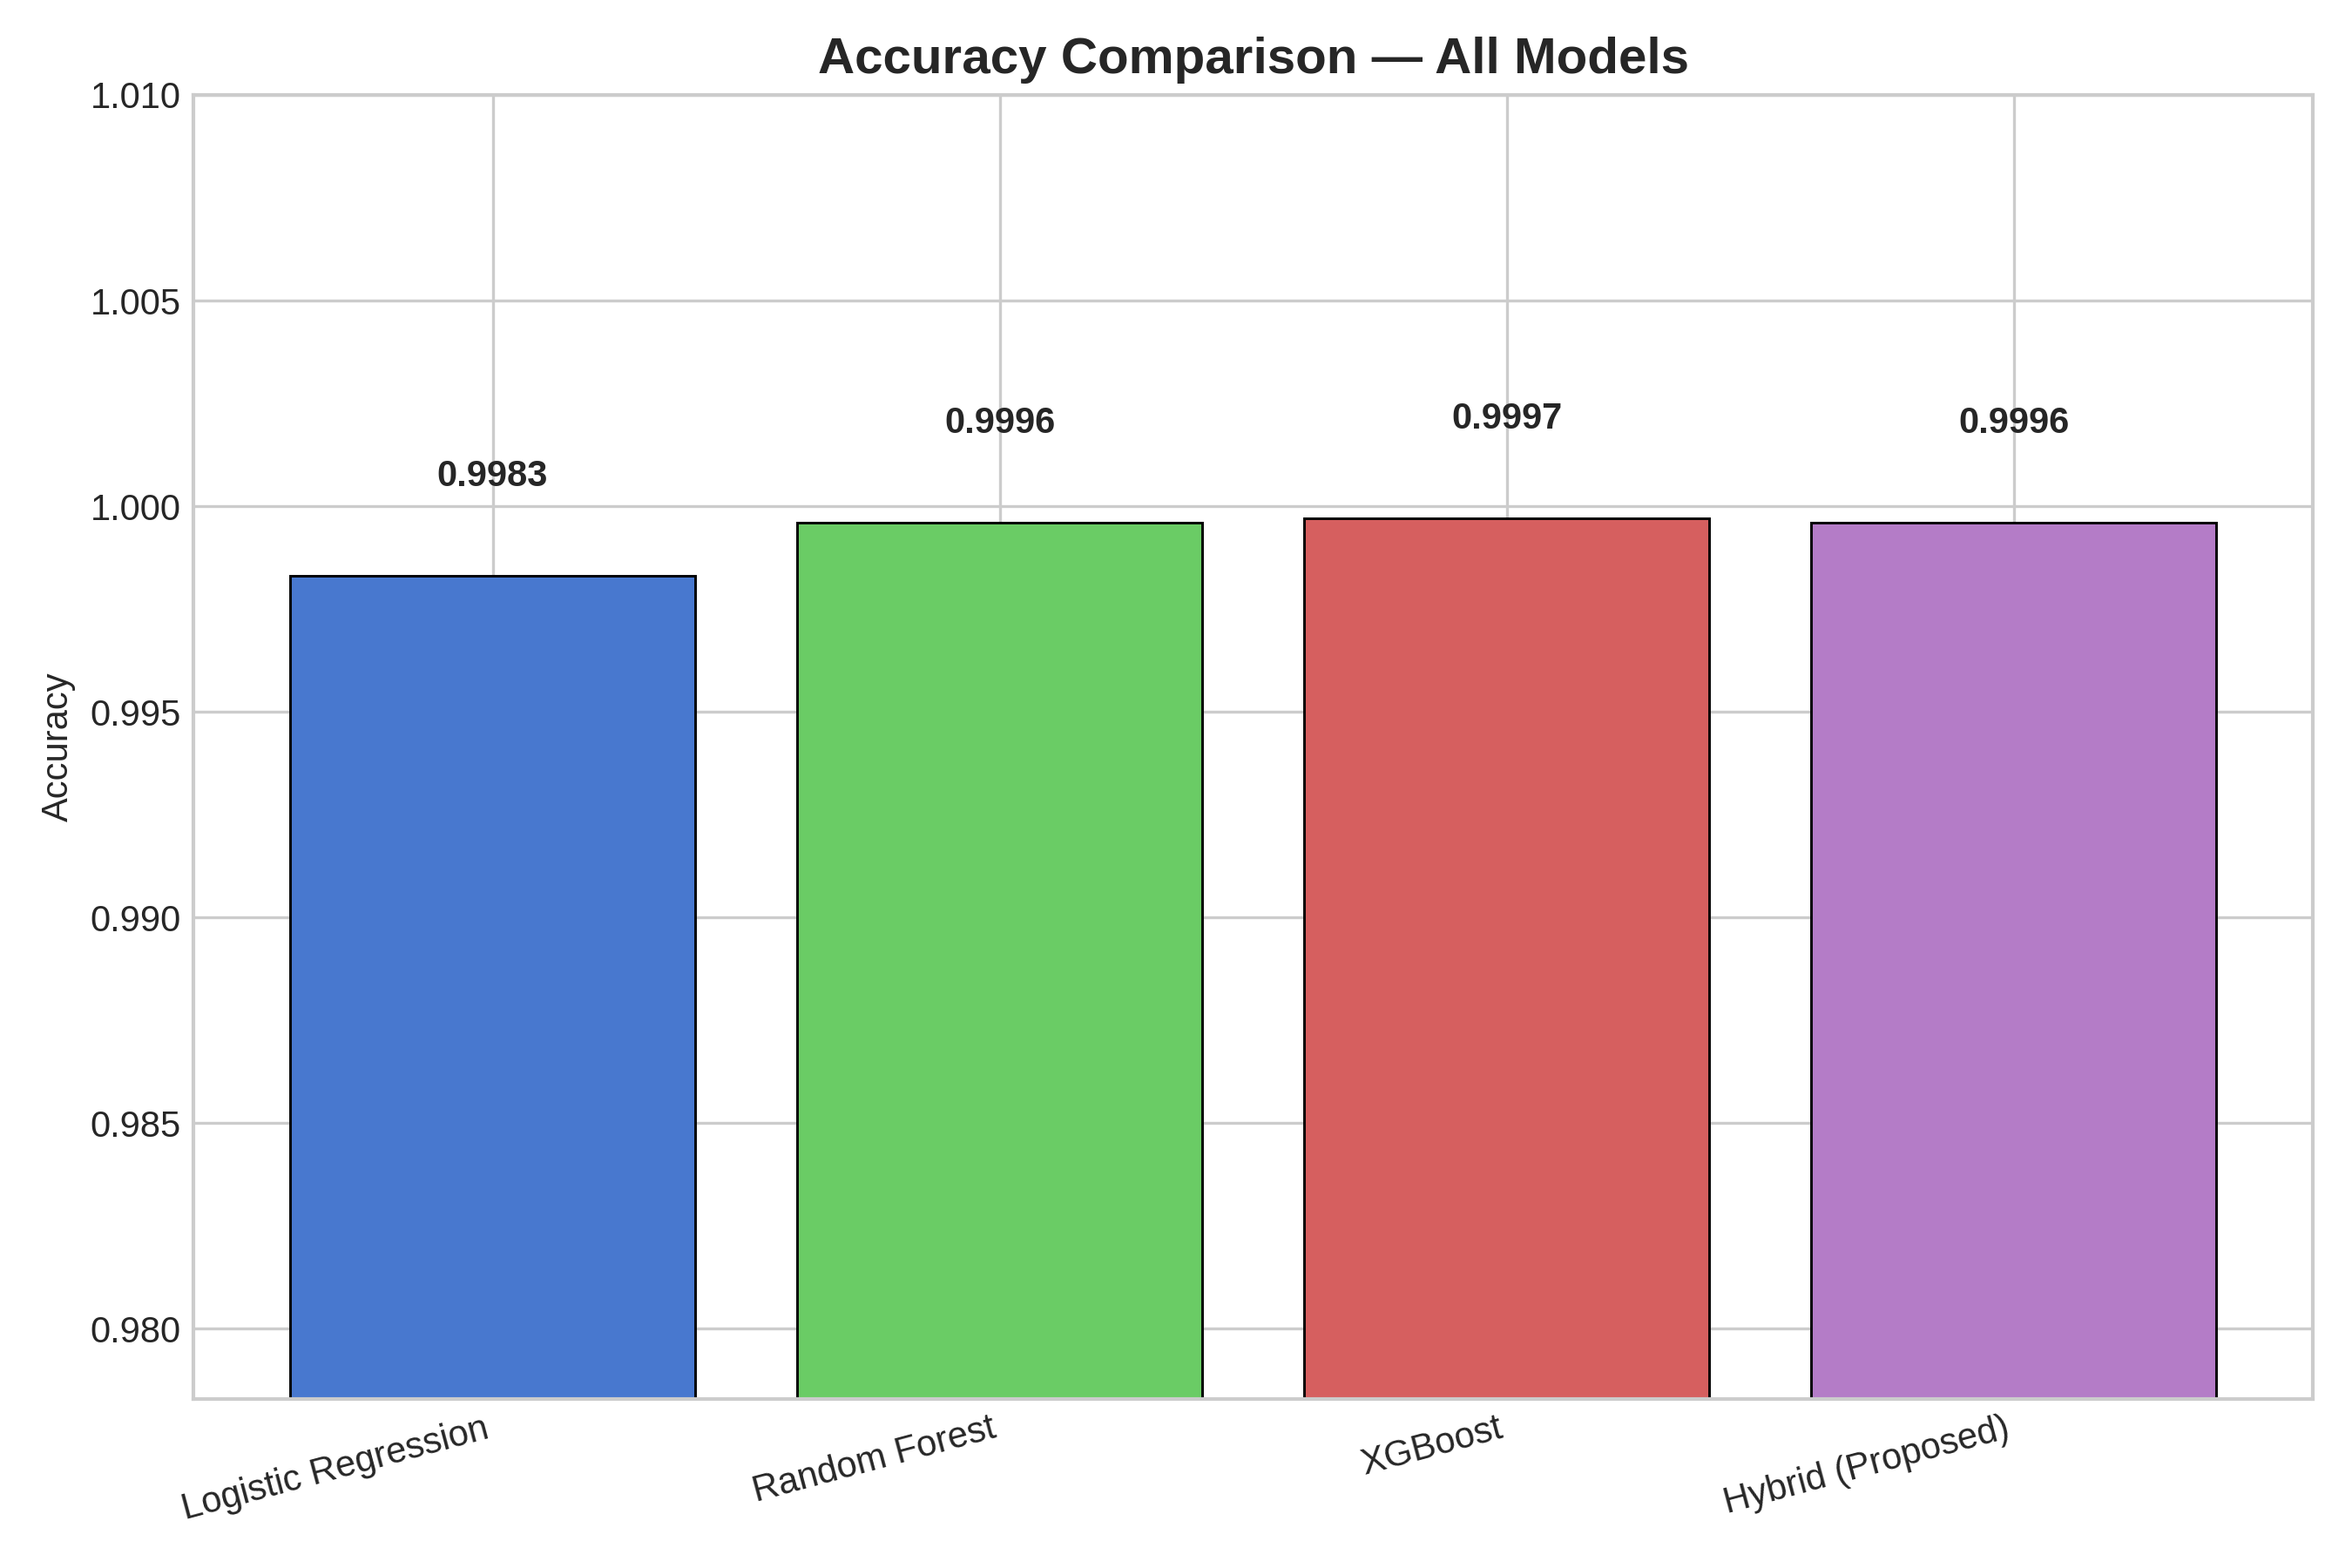

✅ Plot 1 saved: /content/drive/MyDrive/PhishingDetection/plots/accuracy_comparison.png


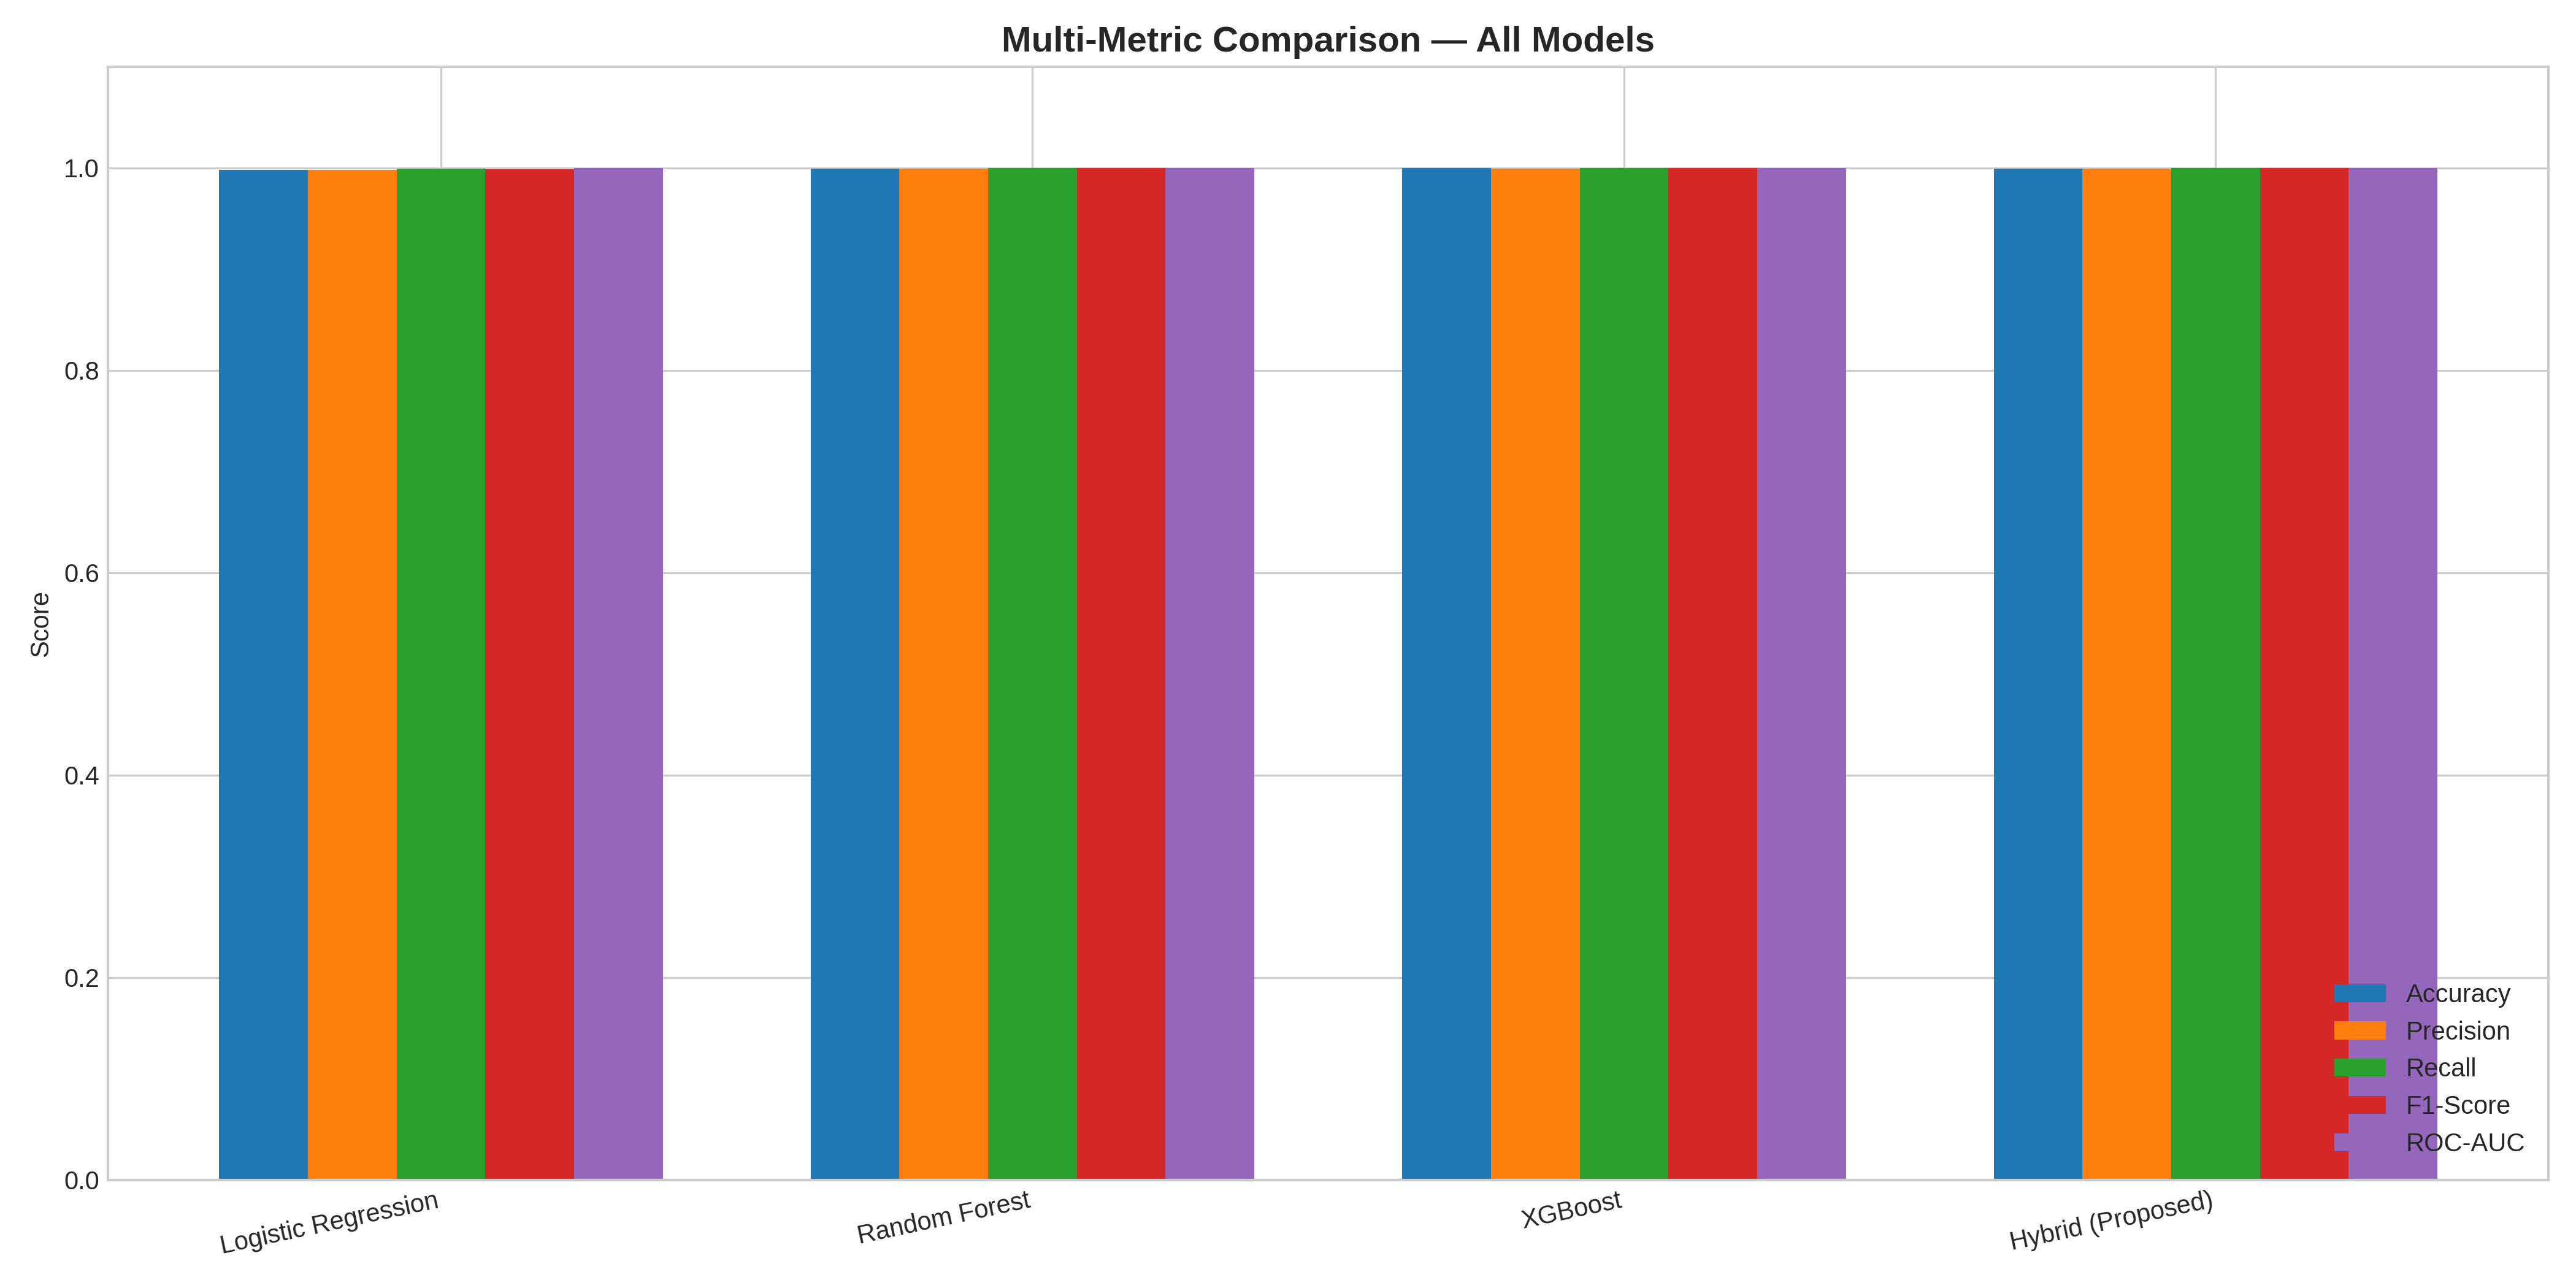

✅ Plot 2 saved: /content/drive/MyDrive/PhishingDetection/plots/multi_metric_comparison.png


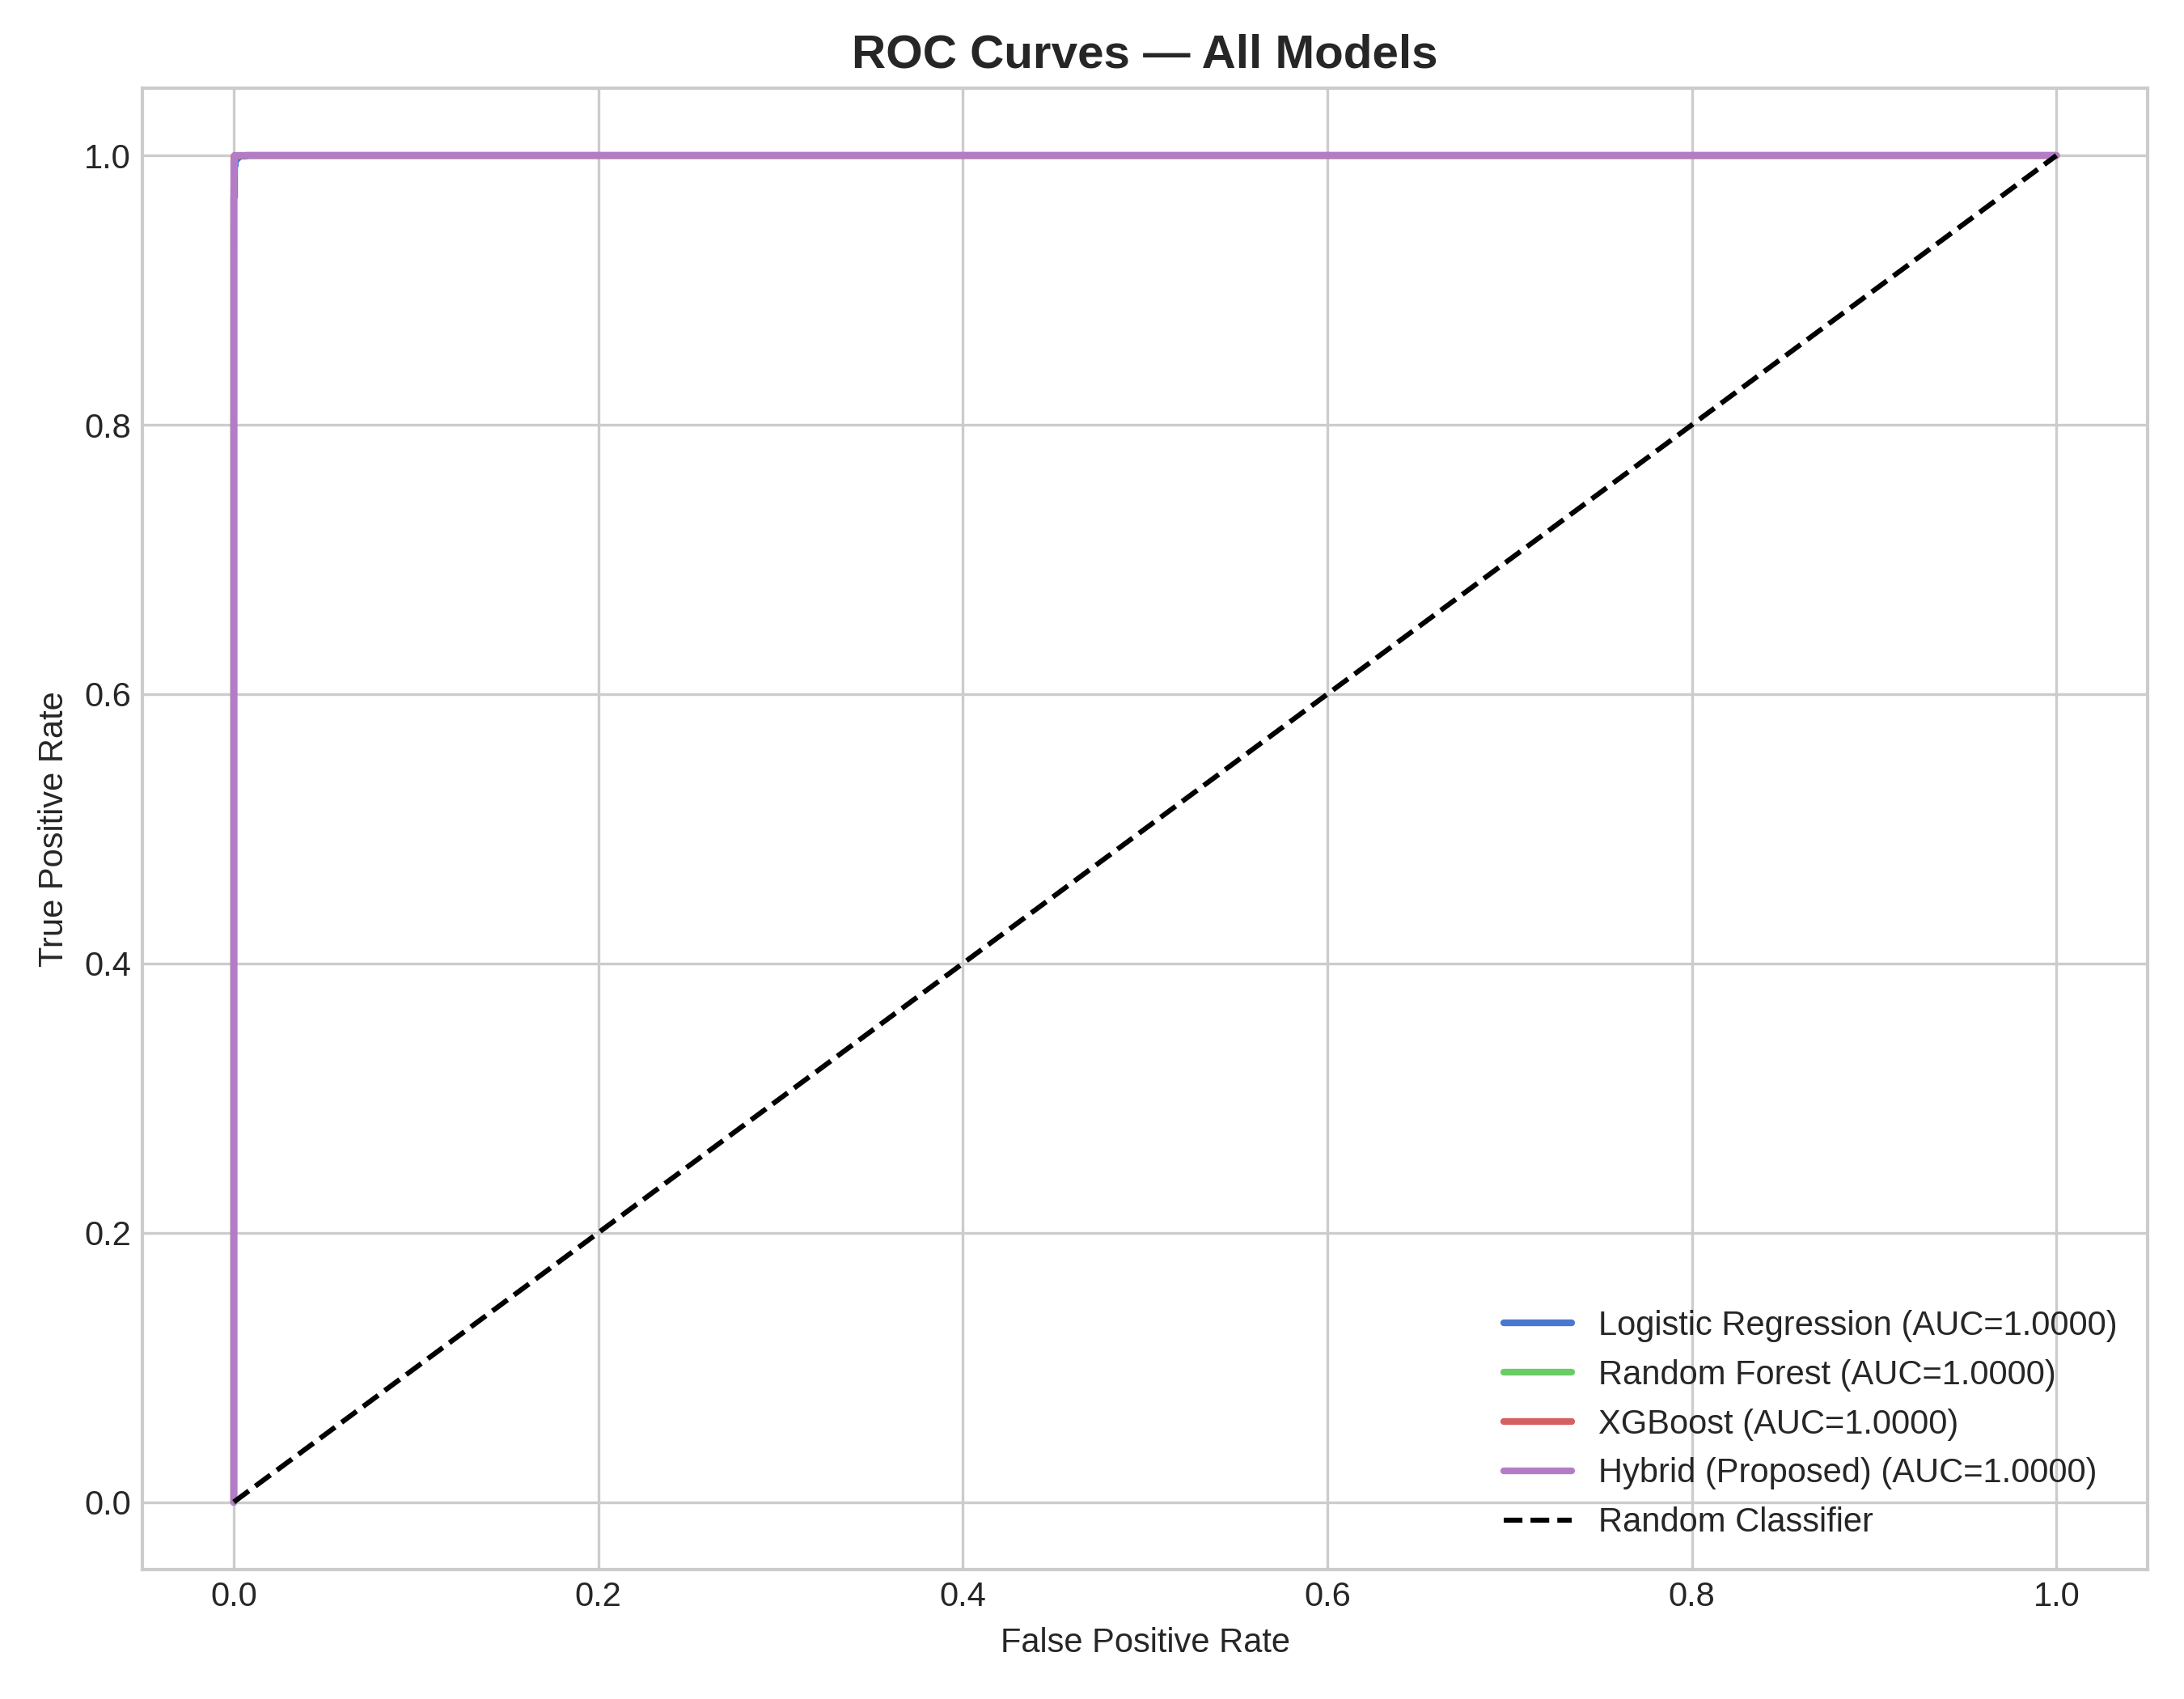

✅ Plot 3 saved: /content/drive/MyDrive/PhishingDetection/plots/roc_curves.png


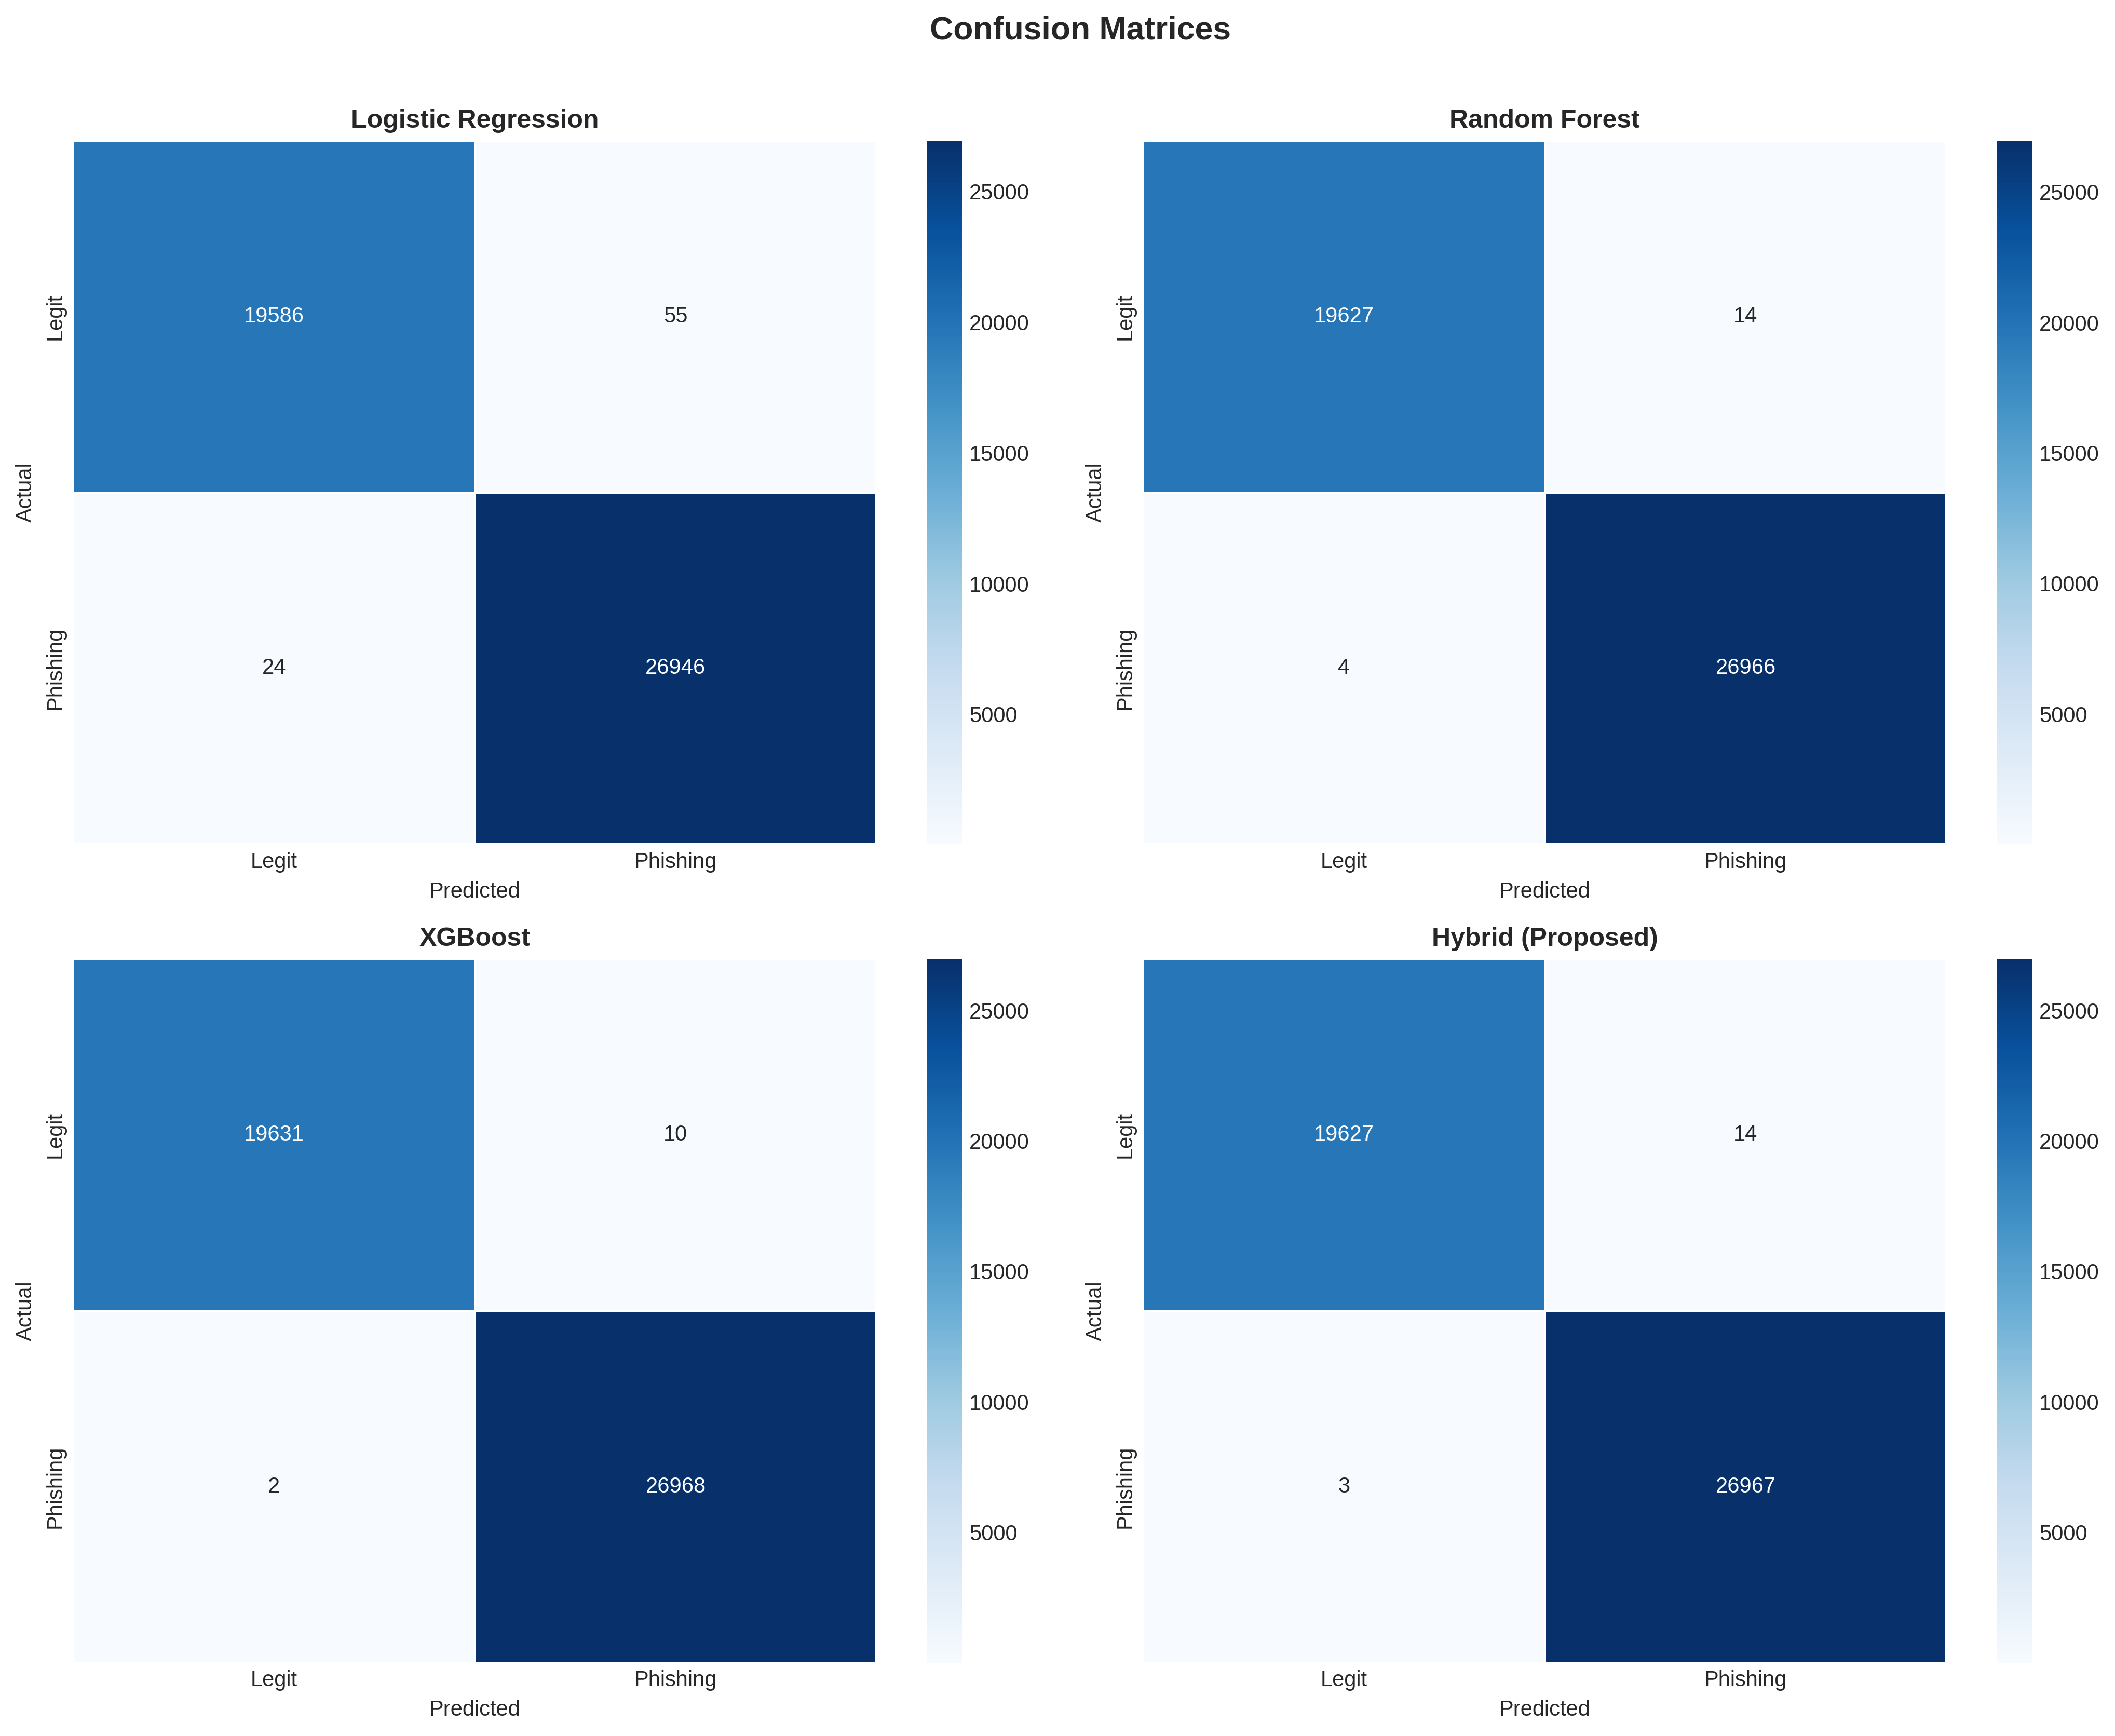

✅ Plot 4 saved: /content/drive/MyDrive/PhishingDetection/plots/confusion_matrices.png


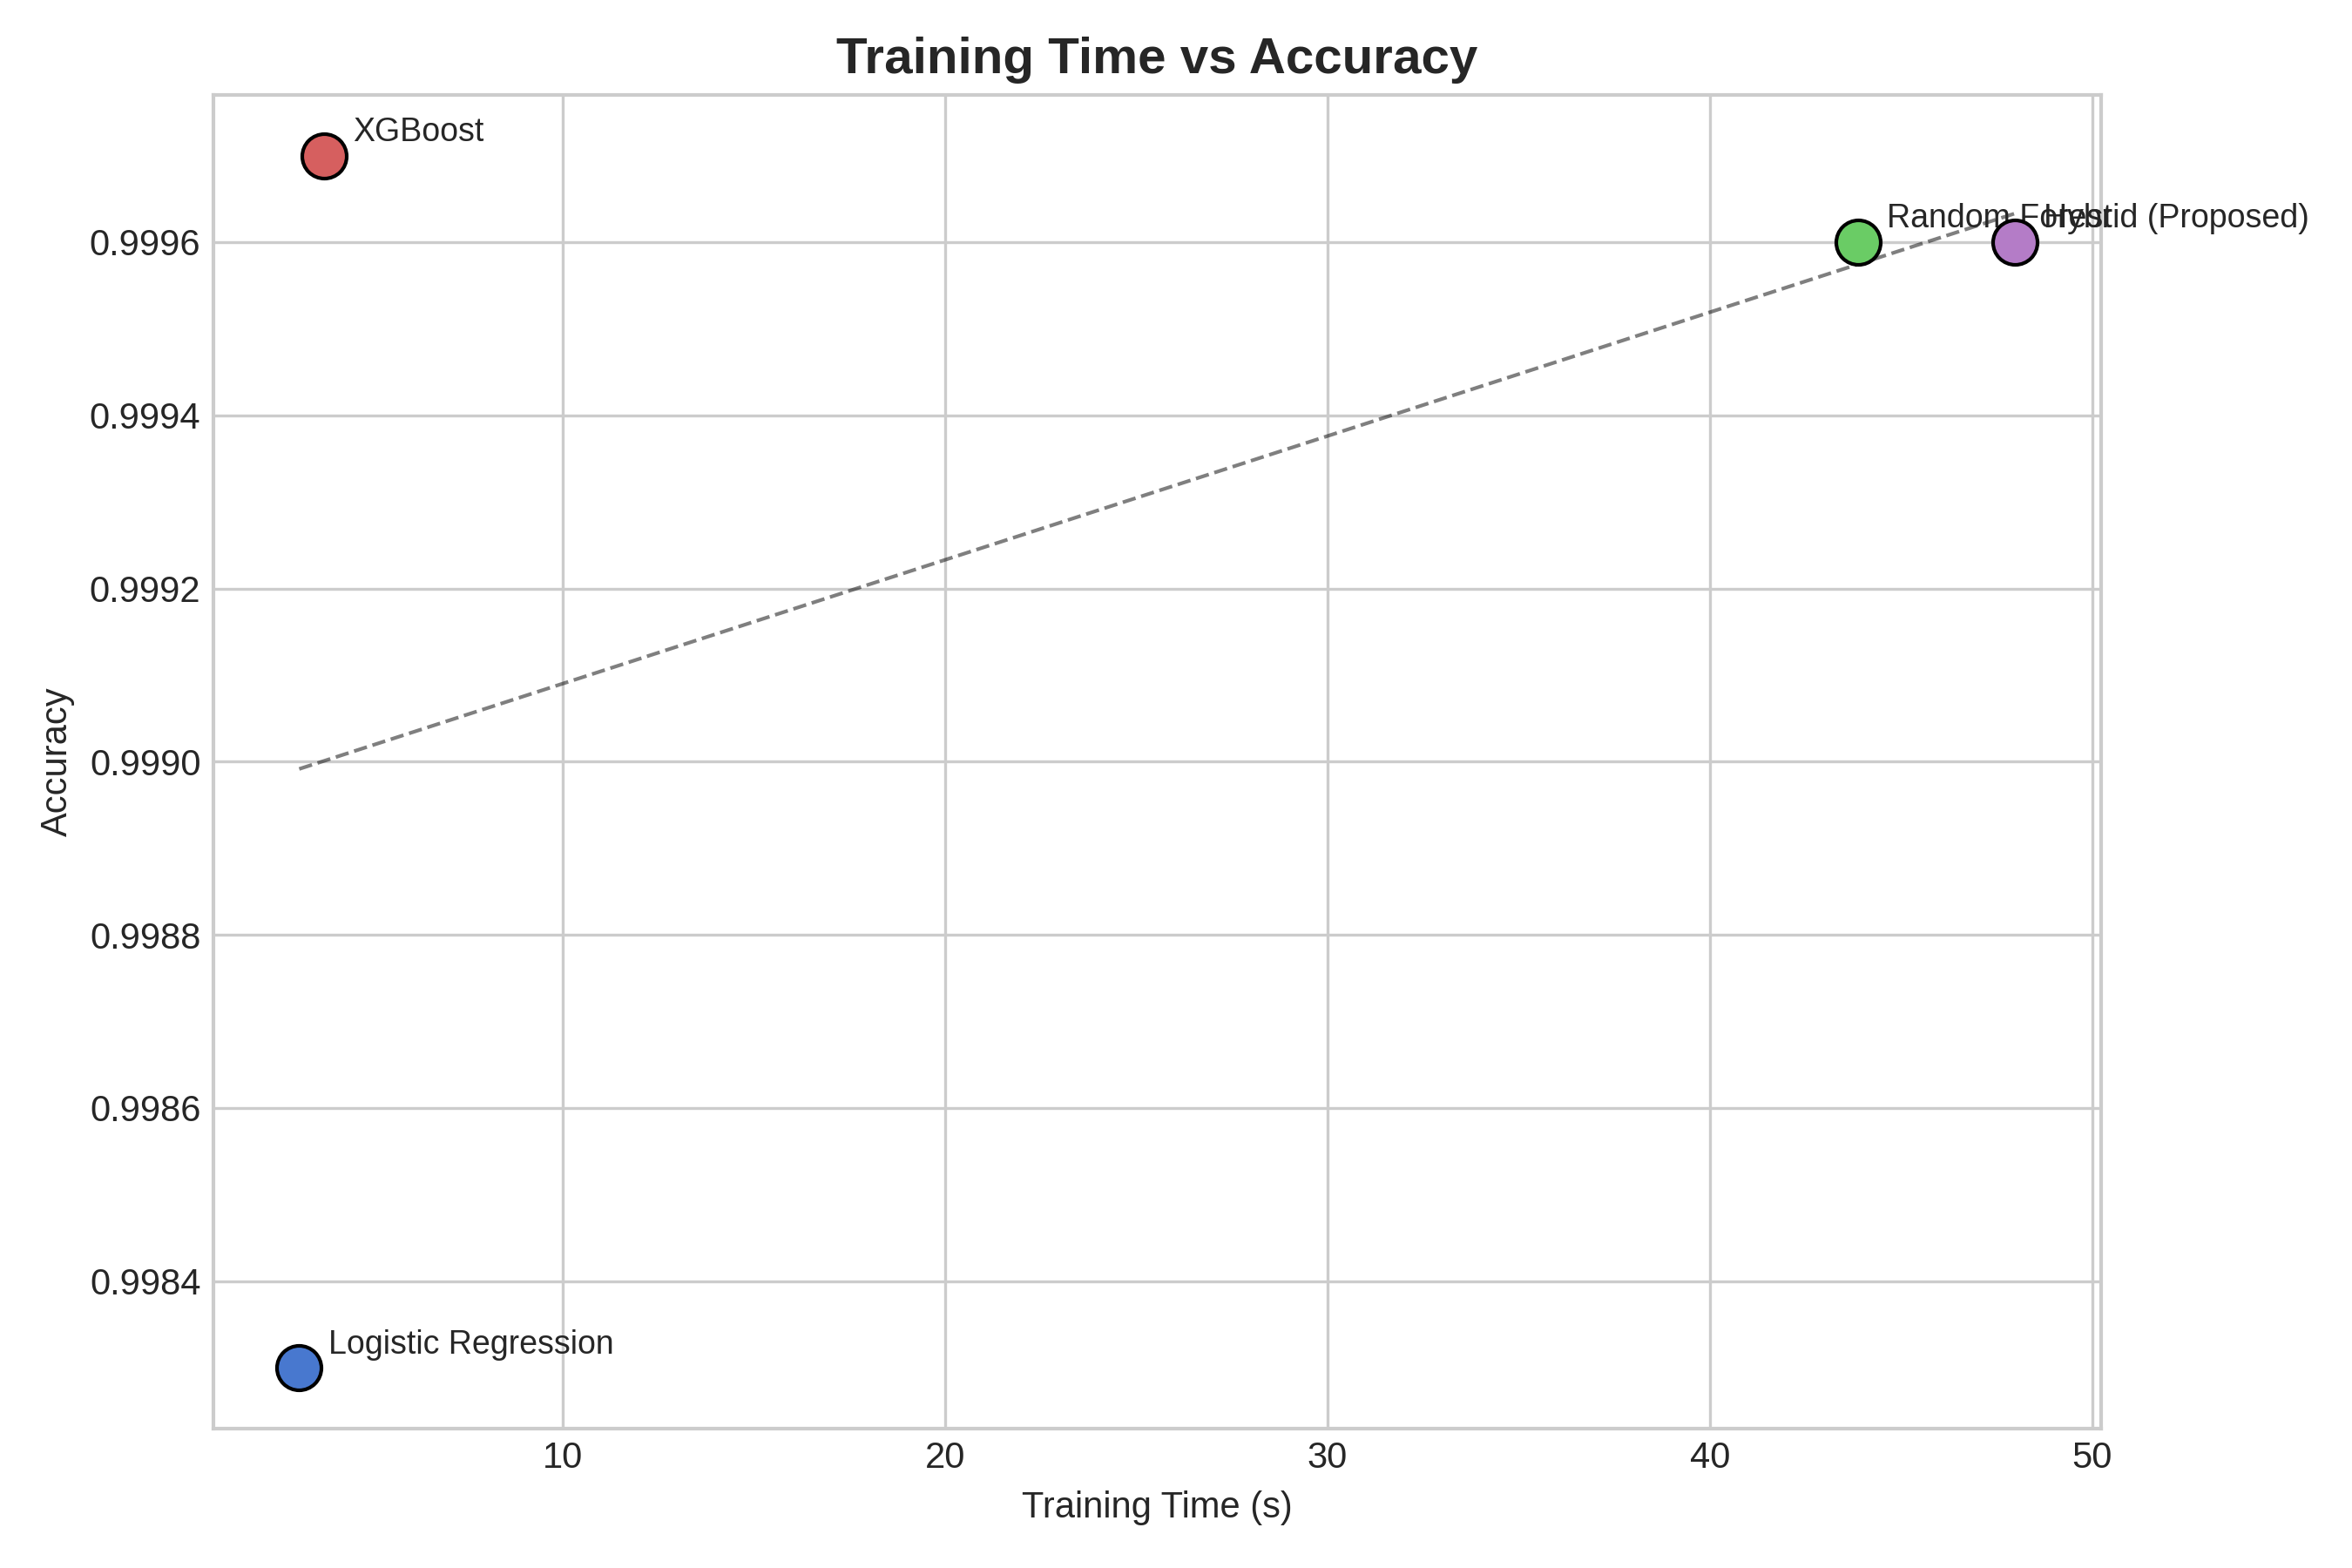

✅ Plot 5 saved: /content/drive/MyDrive/PhishingDetection/plots/time_vs_accuracy.png


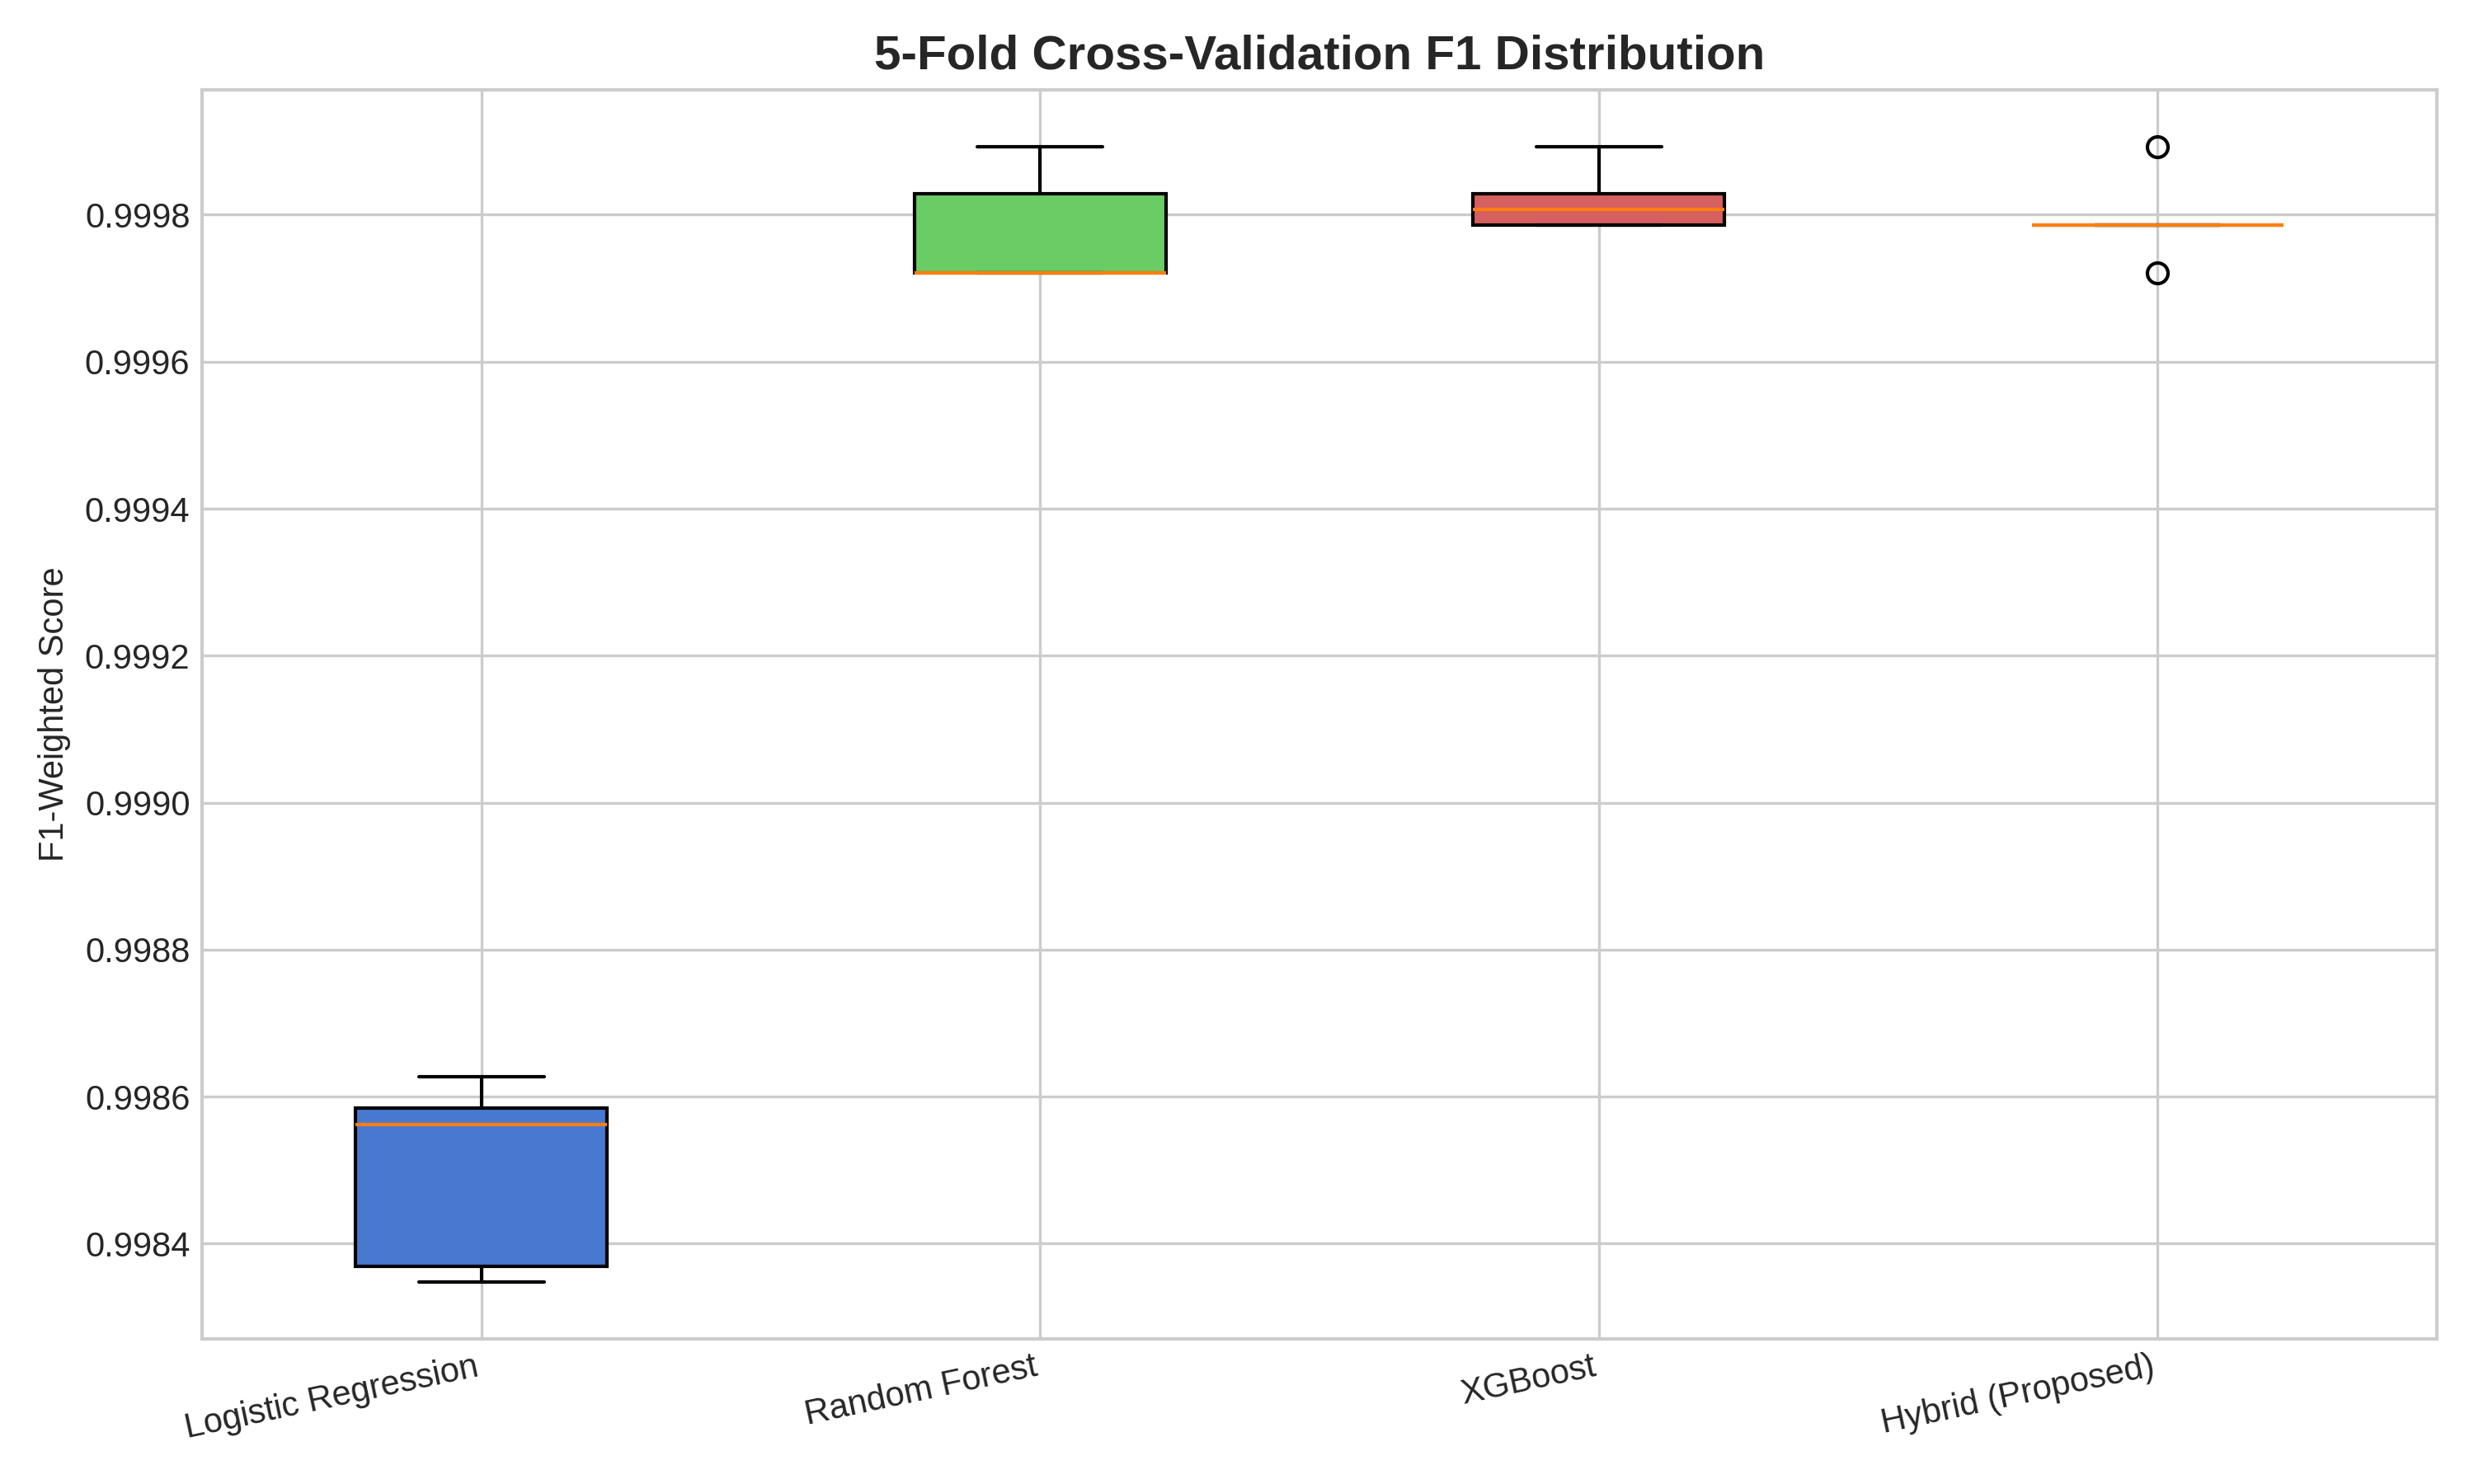

✅ Plot 6 saved: /content/drive/MyDrive/PhishingDetection/plots/cv_f1_boxplot.png


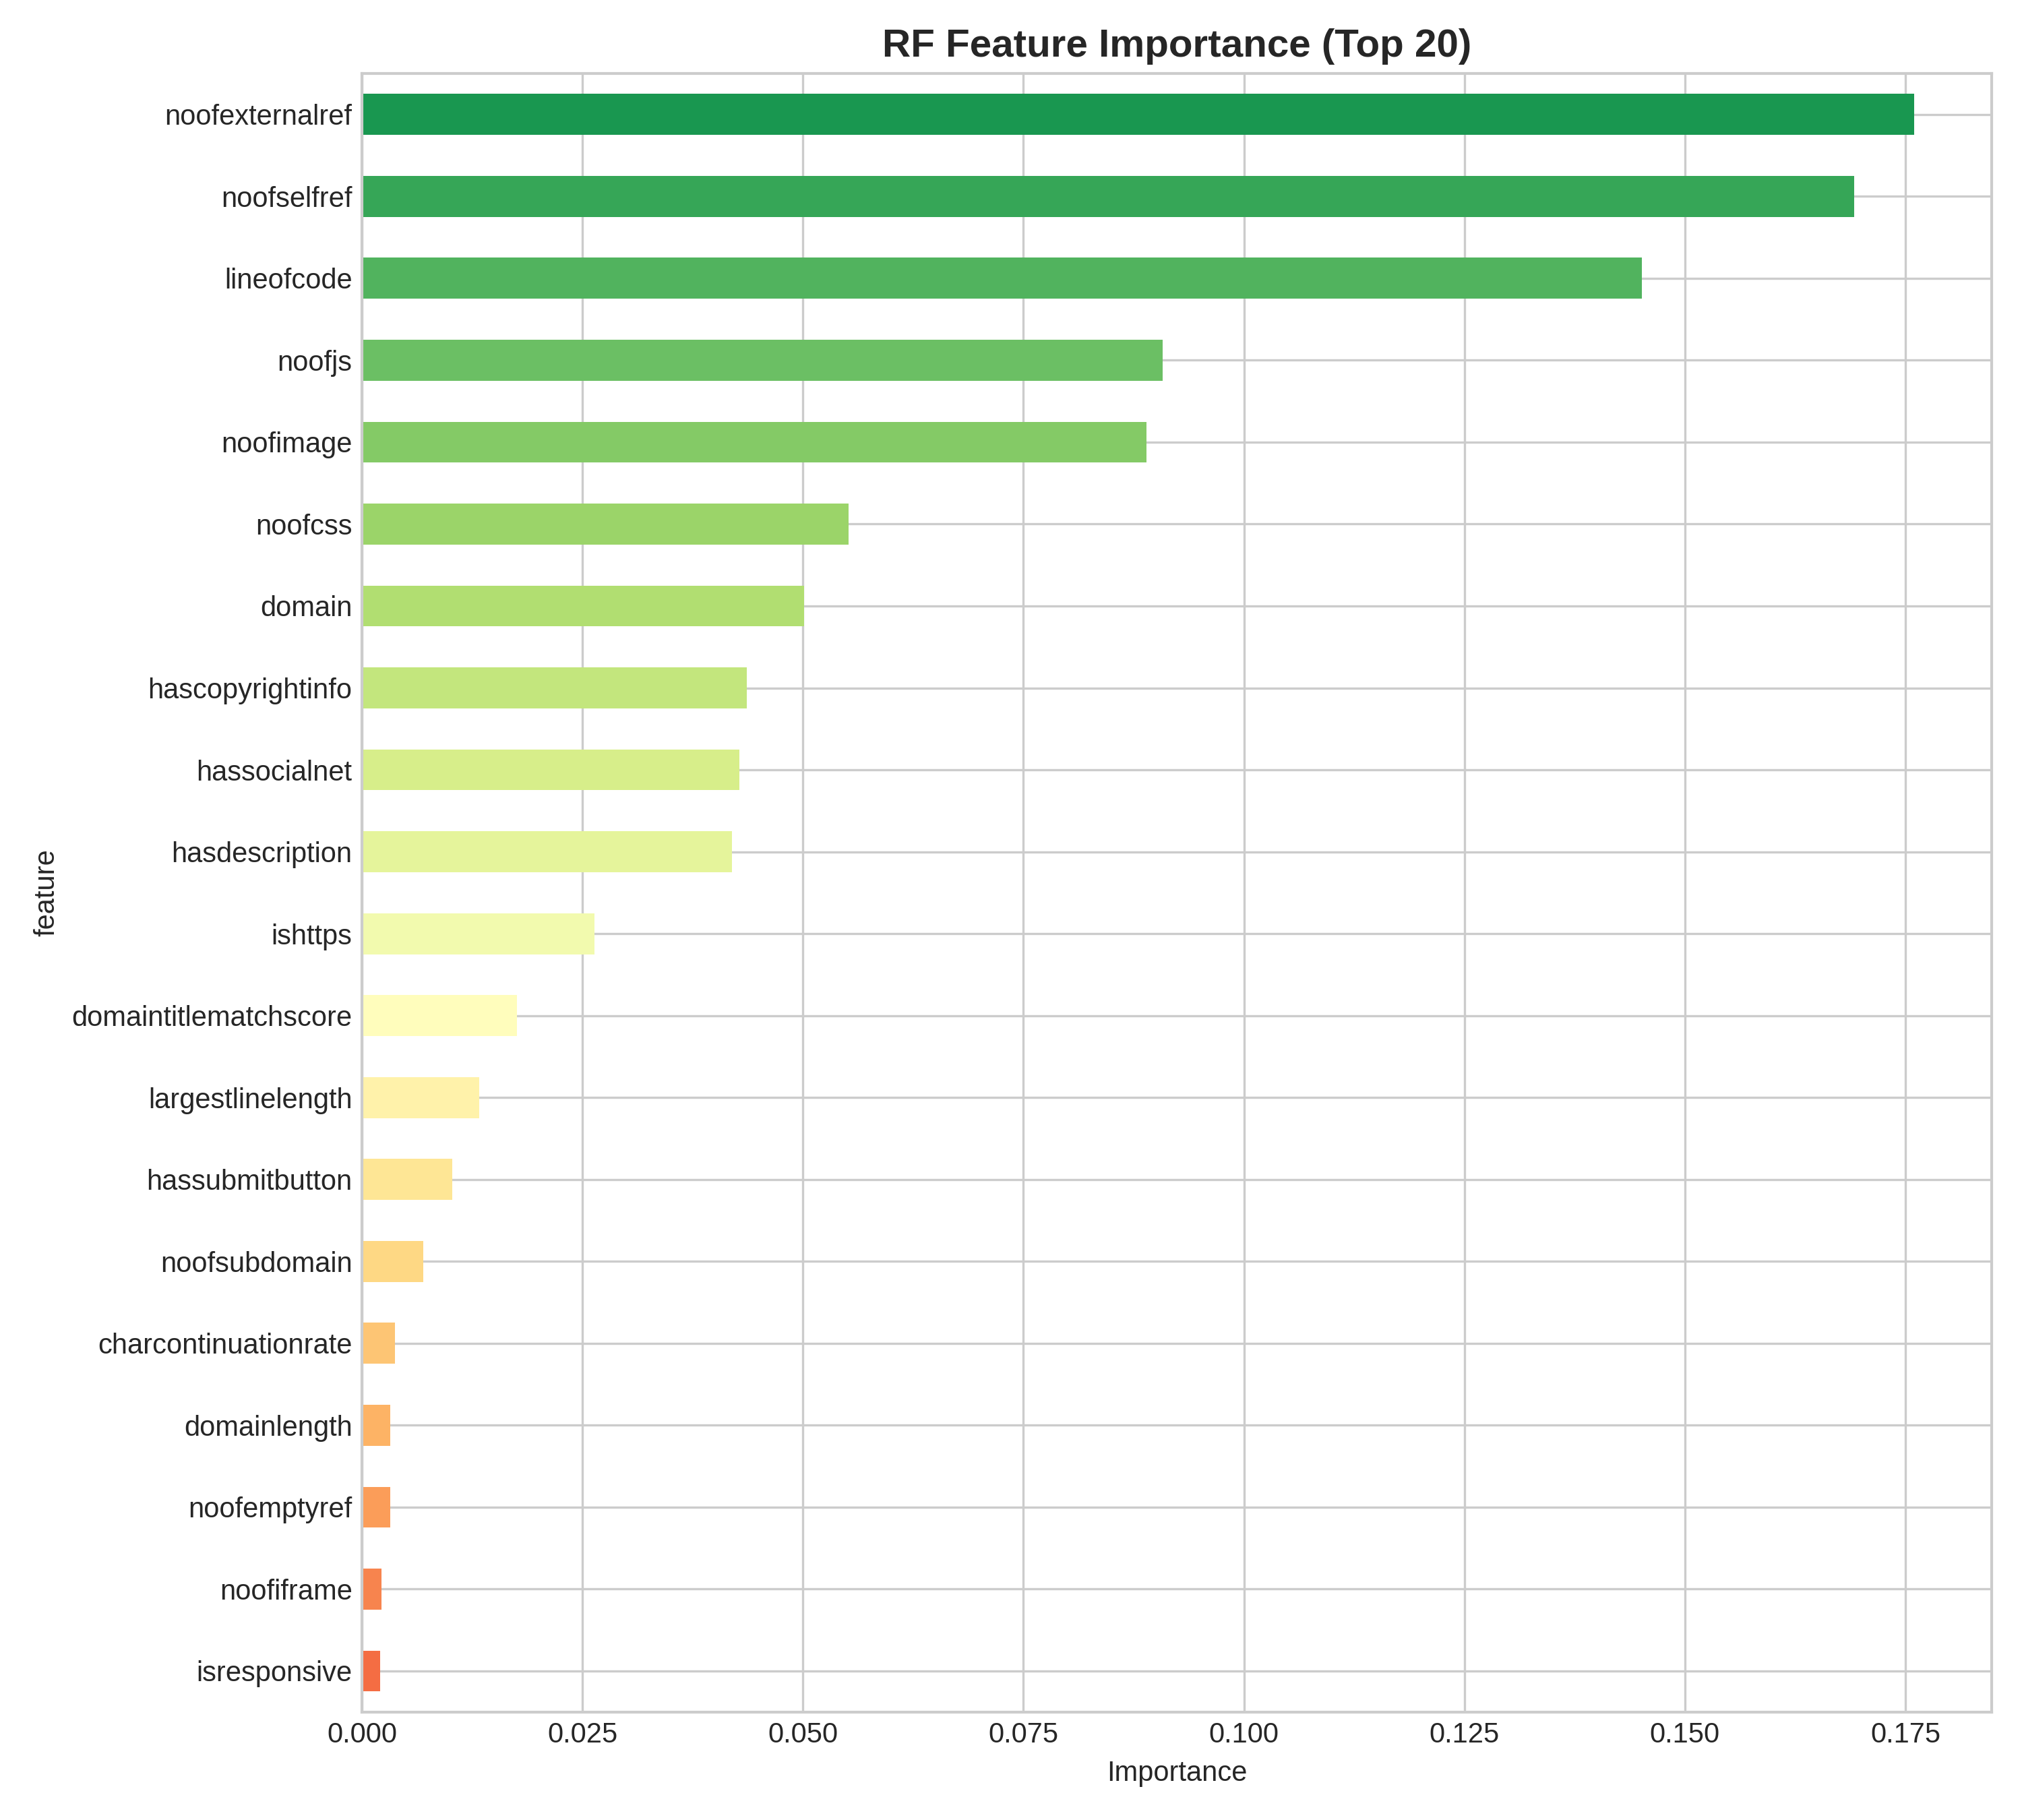

✅ Plot 7 saved: /content/drive/MyDrive/PhishingDetection/plots/feature_importance_rf.png

✅ All 7 publication-ready plots saved to Drive.


In [19]:
# ============================================================
# CELL 18 — Publication-Ready Visualizations (7 plots)
# ============================================================

from IPython.display import Image as IPyImage, display

if is_done("plots_done"):
    print("✅ All plots already done — displaying from Drive.")
    for fname in ["accuracy_comparison.png", "multi_metric_comparison.png",
                  "roc_curves.png", "confusion_matrices.png",
                  "time_vs_accuracy.png", "cv_f1_boxplot.png",
                  "feature_importance_rf.png"]:
        fpath = os.path.join(PLOTS_DIR, fname)
        if os.path.exists(fpath):
            print(f"  📊 {fname}")
            display(IPyImage(filename=fpath))
else:
    # Ensure results_df and models are available
    if 'results_df' not in dir():
        results_df = pd.read_csv(f"{RESULTS_DIR}/comparison_table.csv")

    MODEL_COLORS = {
        "Logistic Regression": "#4878CF",
        "Random Forest":       "#6ACC65",
        "XGBoost":             "#D65F5F",
        "Hybrid (Proposed)":   "#B47CC7",
    }
    models_list = results_df["Model"].tolist()
    colors = [MODEL_COLORS.get(m, "#888888") for m in models_list]

    # ── Plot 1: Accuracy Bar Chart ───────────────────────────
    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.bar(results_df["Model"], results_df["Accuracy"],
                  color=colors, edgecolor='black', linewidth=0.7)
    for bar, val in zip(bars, results_df["Accuracy"]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim([results_df["Accuracy"].min() - 0.02, 1.01])
    ax.set_title("Accuracy Comparison — All Models", fontsize=14, fontweight='bold')
    ax.set_ylabel("Accuracy"); ax.set_xticklabels(models_list, rotation=15, ha='right')
    plt.tight_layout()
    p = f"{PLOTS_DIR}/accuracy_comparison.png"
    plt.savefig(p, dpi=300); display(IPyImage(filename=p)); plt.close()
    print(f"✅ Plot 1 saved: {p}")

    # ── Plot 2: Multi-Metric Grouped Bar Chart ───────────────
    metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    x = np.arange(len(models_list))
    width = 0.15
    fig, ax = plt.subplots(figsize=(14, 7))
    for i, metric in enumerate(metrics_to_plot):
        vals = results_df[metric].values
        ax.bar(x + i * width, vals, width, label=metric)
    ax.set_xticks(x + width * 2); ax.set_xticklabels(models_list, rotation=12, ha='right')
    ax.set_ylim(0, 1.1); ax.set_ylabel("Score"); ax.legend(loc='lower right')
    ax.set_title("Multi-Metric Comparison — All Models", fontsize=14, fontweight='bold')
    plt.tight_layout()
    p = f"{PLOTS_DIR}/multi_metric_comparison.png"
    plt.savefig(p, dpi=300); display(IPyImage(filename=p)); plt.close()
    print(f"✅ Plot 2 saved: {p}")

    # ── Plot 3: ROC Curves ───────────────────────────────────
    model_objects = {
        "Logistic Regression": (lr_model,     "lr"),
        "Random Forest":       (rf_model,     "rf"),
        "XGBoost":             (xgb_model,    "xgb"),
        "Hybrid (Proposed)":   (hybrid_model, "hybrid"),
    }
    X_test_arr = X1_test.values if hasattr(X1_test, 'values') else X1_test
    fig, ax = plt.subplots(figsize=(9, 7))
    for model_name, (model, abbr) in model_objects.items():
        if model is not None:
            proba = model.predict_proba(X_test_arr)[:, 1]
            fpr, tpr, _ = roc_curve(y1_test, proba)
            auc = roc_auc_score(y1_test, proba)
            ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.4f})",
                    color=MODEL_COLORS.get(model_name), linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random Classifier")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves — All Models", fontsize=14, fontweight='bold')
    ax.legend(loc="lower right"); plt.tight_layout()
    p = f"{PLOTS_DIR}/roc_curves.png"
    plt.savefig(p, dpi=300); display(IPyImage(filename=p)); plt.close()
    print(f"✅ Plot 3 saved: {p}")

    # ── Plot 4: Confusion Matrices (2×2 grid) ────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    for ax, (model_name, (model, abbr)) in zip(axes.flatten(), model_objects.items()):
        if model is not None:
            y_pred = model.predict(X_test_arr)
            cm = confusion_matrix(y1_test, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=["Legit", "Phishing"],
                        yticklabels=["Legit", "Phishing"],
                        linewidths=0.5)
            ax.set_title(model_name, fontsize=12, fontweight='bold')
            ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.suptitle("Confusion Matrices", fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    p = f"{PLOTS_DIR}/confusion_matrices.png"
    plt.savefig(p, dpi=300, bbox_inches='tight')
    display(IPyImage(filename=p)); plt.close()
    print(f"✅ Plot 4 saved: {p}")

    # ── Plot 5: Training Time vs Accuracy Scatter ────────────
    fig, ax = plt.subplots(figsize=(9, 6))
    for _, row in results_df.iterrows():
        ax.scatter(row["Train Time (s)"], row["Accuracy"],
                   s=150, color=MODEL_COLORS.get(row["Model"]),
                   zorder=5, edgecolors='black')
        ax.annotate(row["Model"], (row["Train Time (s)"], row["Accuracy"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=9)
    from numpy.polynomial.polynomial import polyfit as _polyfit
    xs = results_df["Train Time (s)"].values
    ys = results_df["Accuracy"].values
    if len(xs) > 2:
        c = np.polyfit(xs, ys, 1)
        x_line = np.linspace(xs.min(), xs.max(), 100)
        ax.plot(x_line, np.polyval(c, x_line), 'k--', linewidth=1, alpha=0.5)
    ax.set_xlabel("Training Time (s)"); ax.set_ylabel("Accuracy")
    ax.set_title("Training Time vs Accuracy", fontsize=14, fontweight='bold')
    plt.tight_layout()
    p = f"{PLOTS_DIR}/time_vs_accuracy.png"
    plt.savefig(p, dpi=300); display(IPyImage(filename=p)); plt.close()
    print(f"✅ Plot 5 saved: {p}")

    # ── Plot 6: CV F1 Box Plot ───────────────────────────────
    if is_done("cv_done"):
        cv_data = load_from_drive("metrics/cv_results.json")
        cv_fold_data = cv_data.get("per_fold", {})
        fig, ax = plt.subplots(figsize=(10, 6))
        bp_data  = [v for v in cv_fold_data.values()]
        bp_labels = list(cv_fold_data.keys())
        bplot = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, notch=False)
        for patch, color in zip(bplot['boxes'], list(MODEL_COLORS.values())):
            patch.set_facecolor(color)
        ax.set_ylabel("F1-Weighted Score")
        ax.set_title("5-Fold Cross-Validation F1 Distribution",
                     fontsize=14, fontweight='bold')
        plt.xticks(rotation=12, ha='right'); plt.tight_layout()
        p = f"{PLOTS_DIR}/cv_f1_boxplot.png"
        plt.savefig(p, dpi=300); display(IPyImage(filename=p)); plt.close()
        print(f"✅ Plot 6 saved: {p}")
    else:
        print("⚠️  Plot 6 skipped — run Cell 16 (CV) first.")

    # ── Plot 7: RF Feature Importance (top 20) ───────────────
    if rf_model is not None:
        fi_path = f"{METRICS_DIR}/rf_feature_importances.csv"
        if os.path.exists(fi_path):
            fi = pd.read_csv(fi_path, index_col=0, names=["feature", "importance"],
                             header=0).squeeze()
        else:
            fi = pd.Series(rf_model.feature_importances_,
                           index=X1_train.columns).sort_values(ascending=False)
        top20 = fi.nlargest(20).sort_values()
        fig, ax = plt.subplots(figsize=(10, 9))
        colors_grad = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top20)))
        top20.plot.barh(ax=ax, color=colors_grad)
        ax.set_title("RF Feature Importance (Top 20)", fontsize=14, fontweight='bold')
        ax.set_xlabel("Importance"); plt.tight_layout()
        p = f"{PLOTS_DIR}/feature_importance_rf.png"
        plt.savefig(p, dpi=300); display(IPyImage(filename=p)); plt.close()
        print(f"✅ Plot 7 saved: {p}")
    else:
        print("⚠️  Plot 7 skipped — RF model not loaded.")

    mark_done("plots_done")
    print("\n✅ All 7 publication-ready plots saved to Drive.")


⚙️  Computing SHAP values (TreeExplainer on 500-sample subset)...
✅ SHAP values computed.


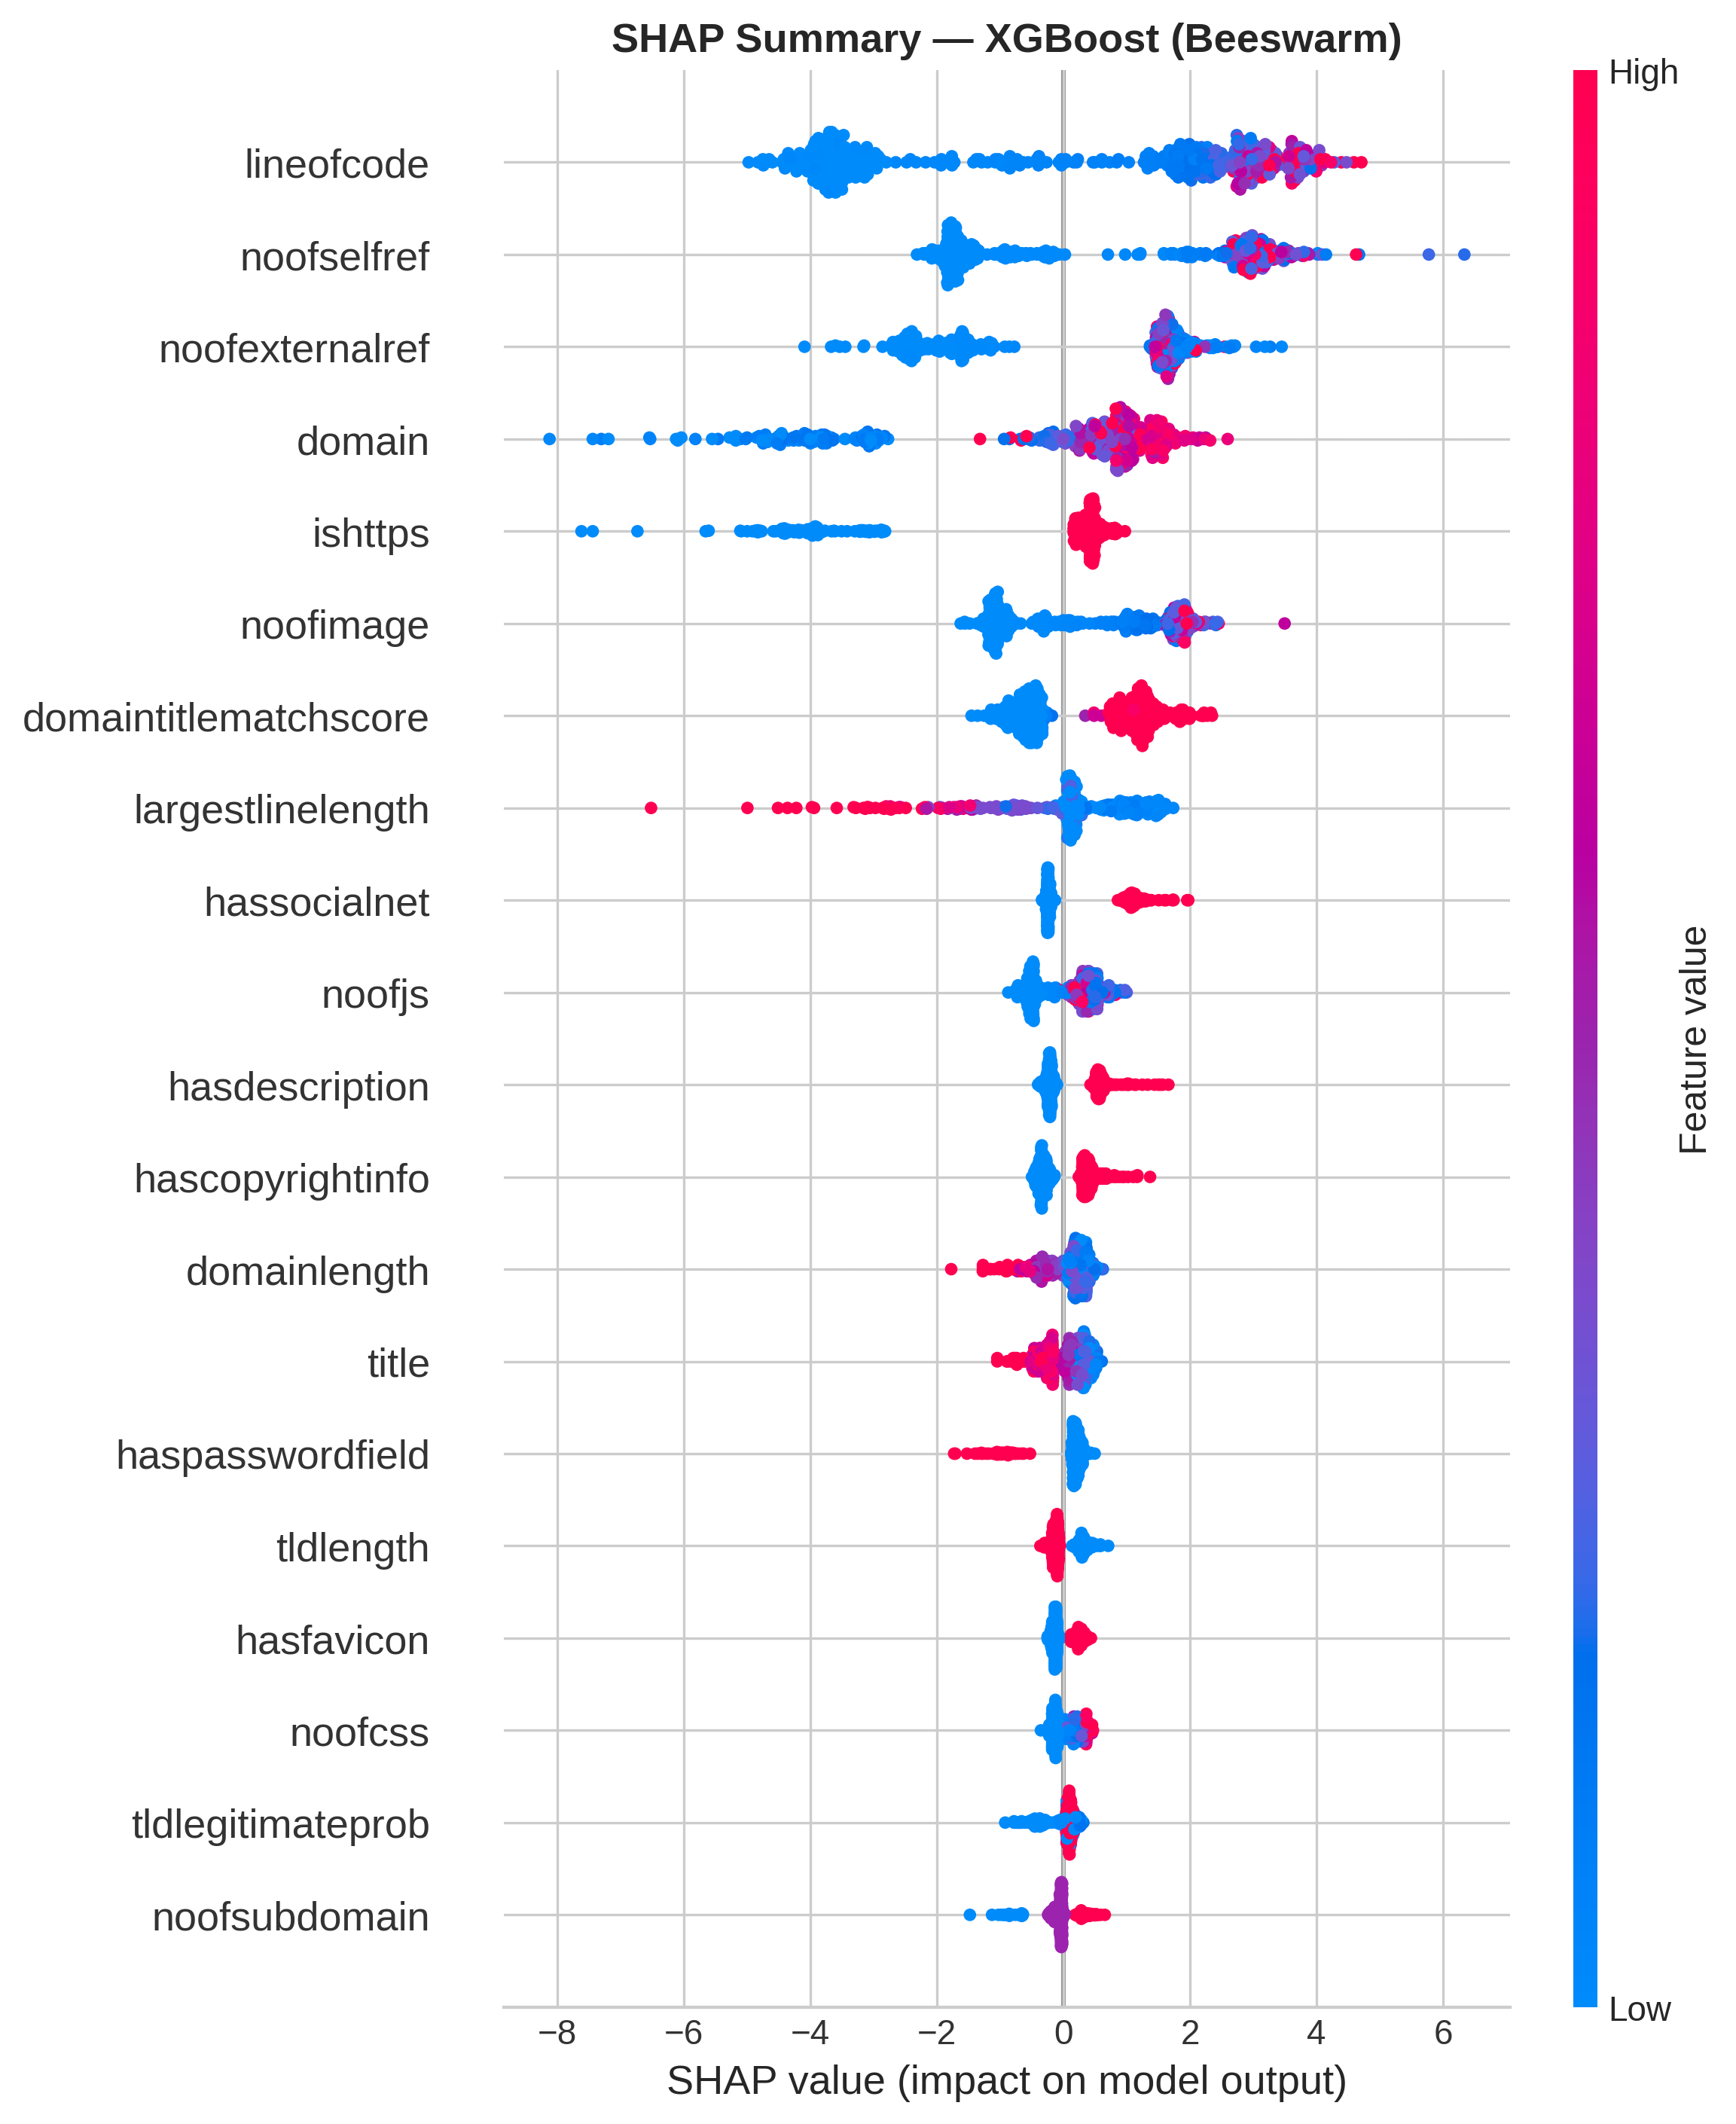

✅ SHAP Summary plot saved: /content/drive/MyDrive/PhishingDetection/plots/shap_summary.png


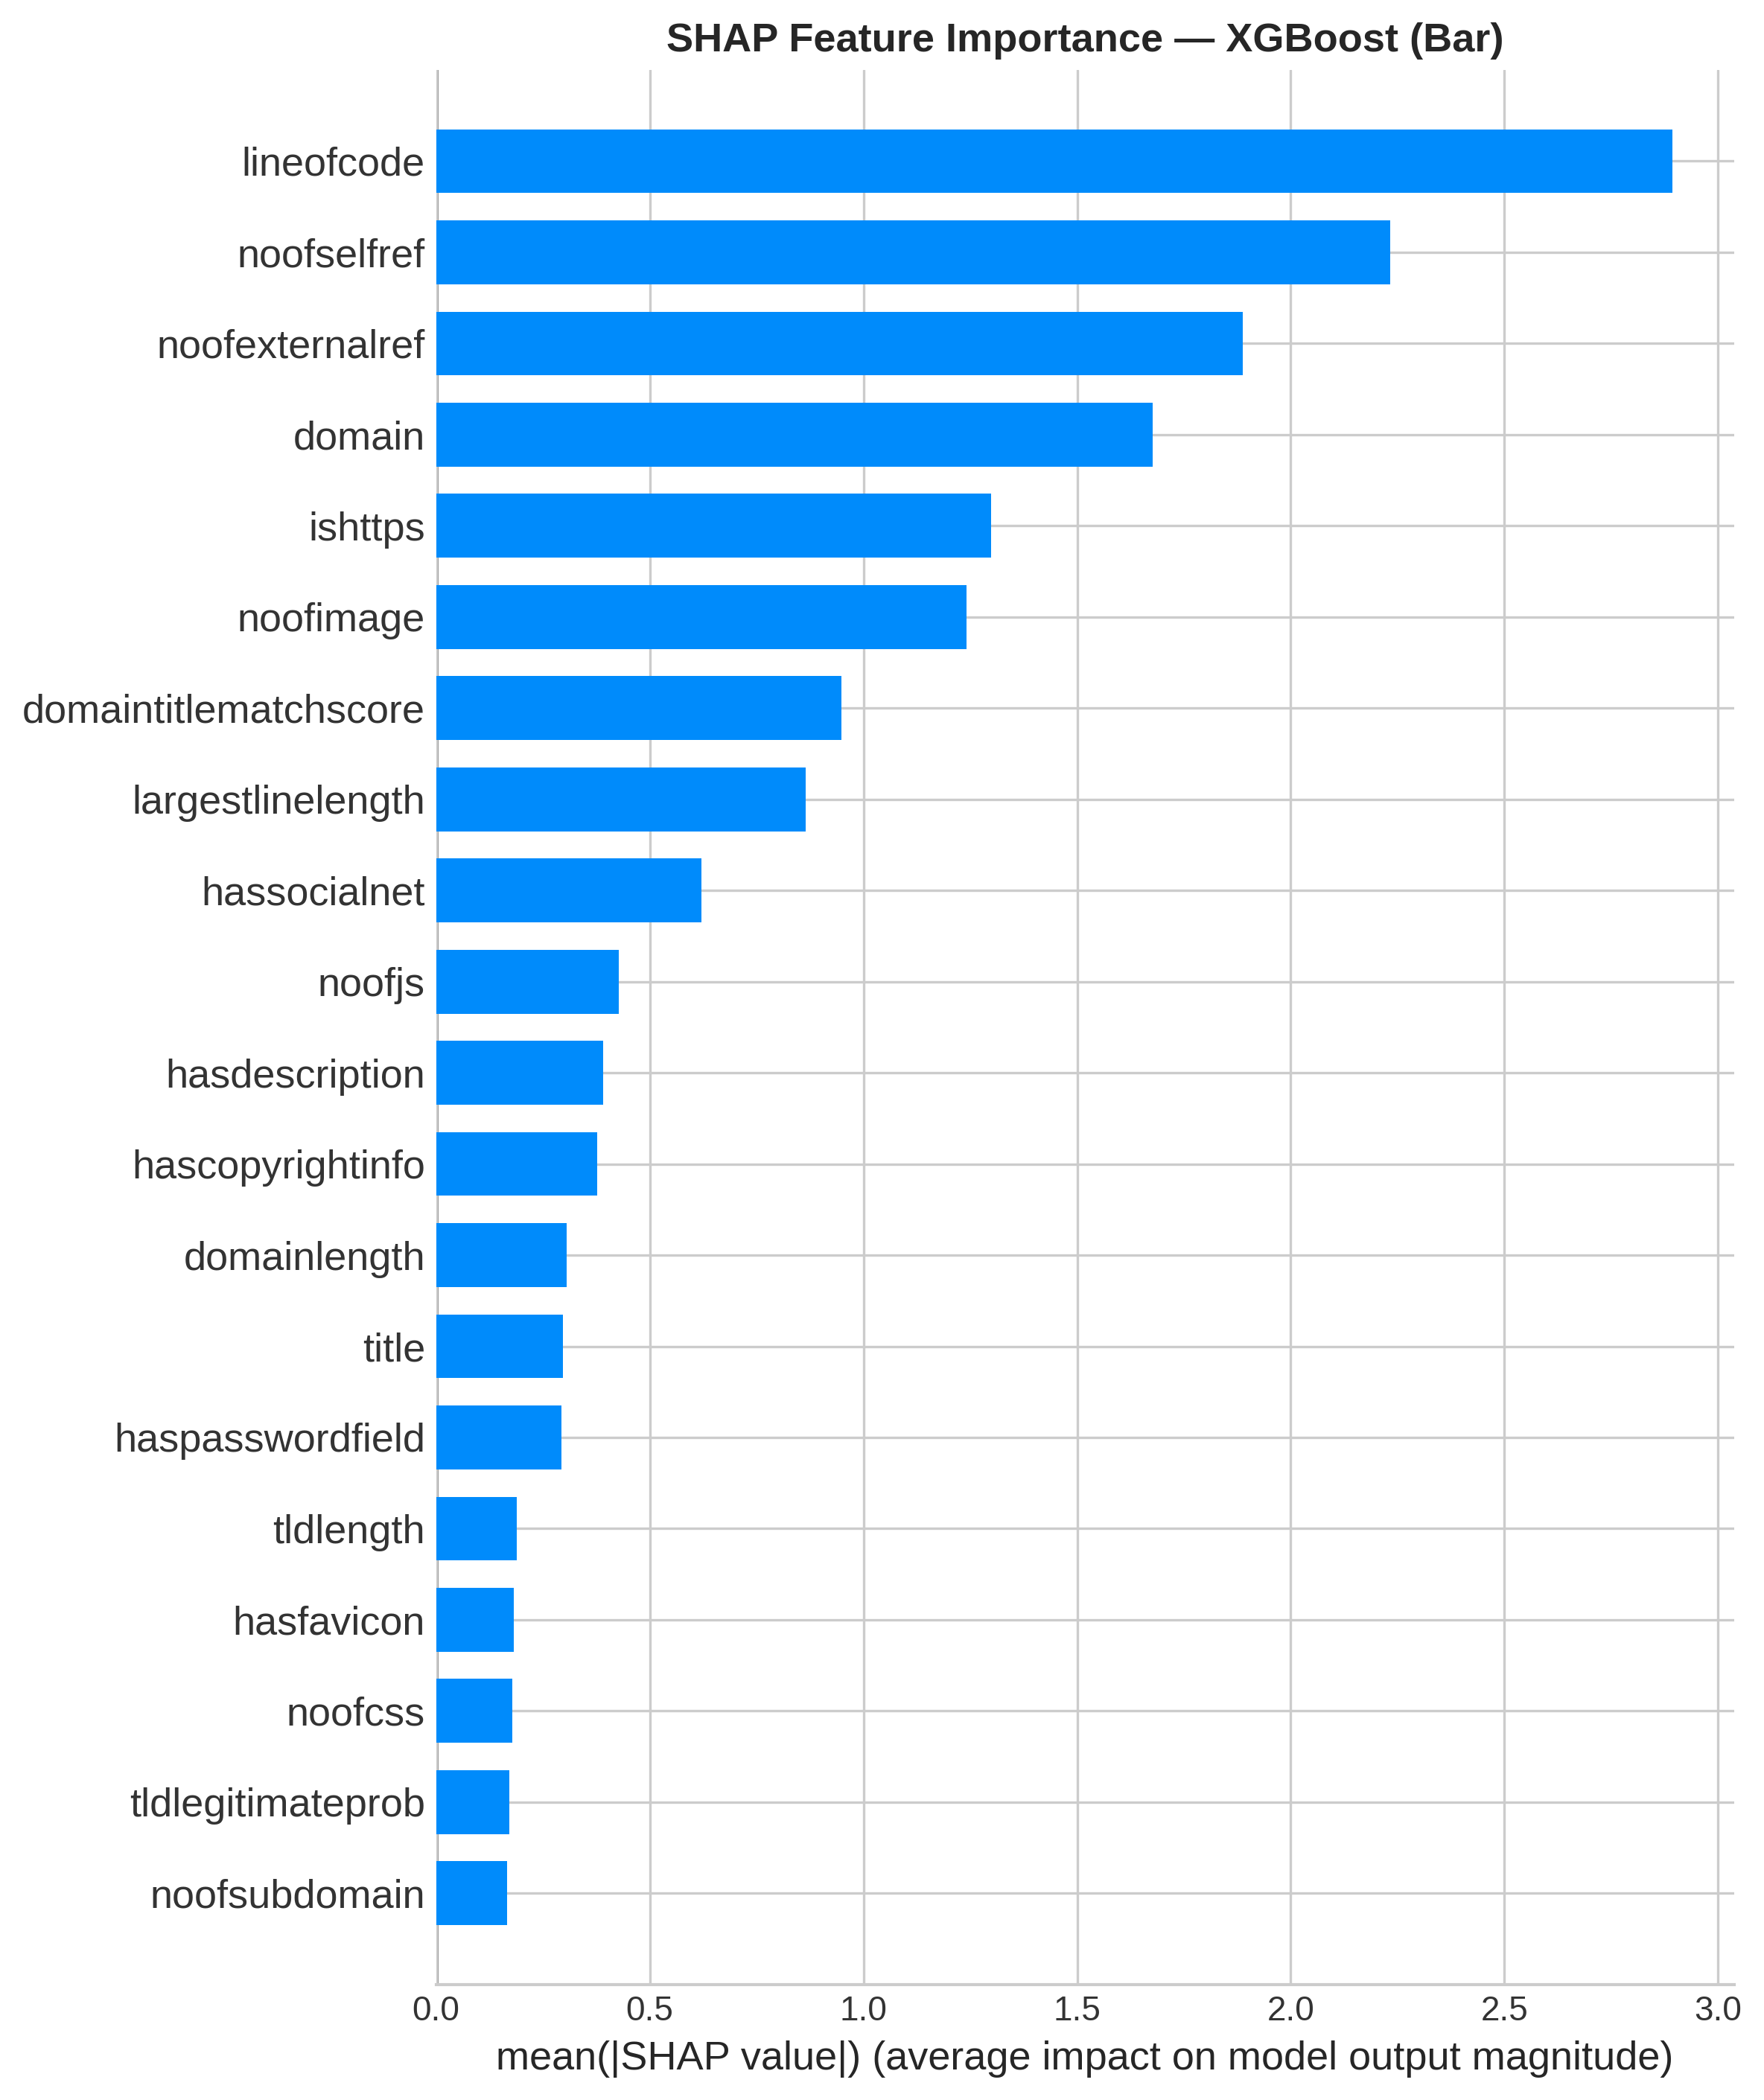

✅ SHAP Bar plot saved: /content/drive/MyDrive/PhishingDetection/plots/shap_bar.png


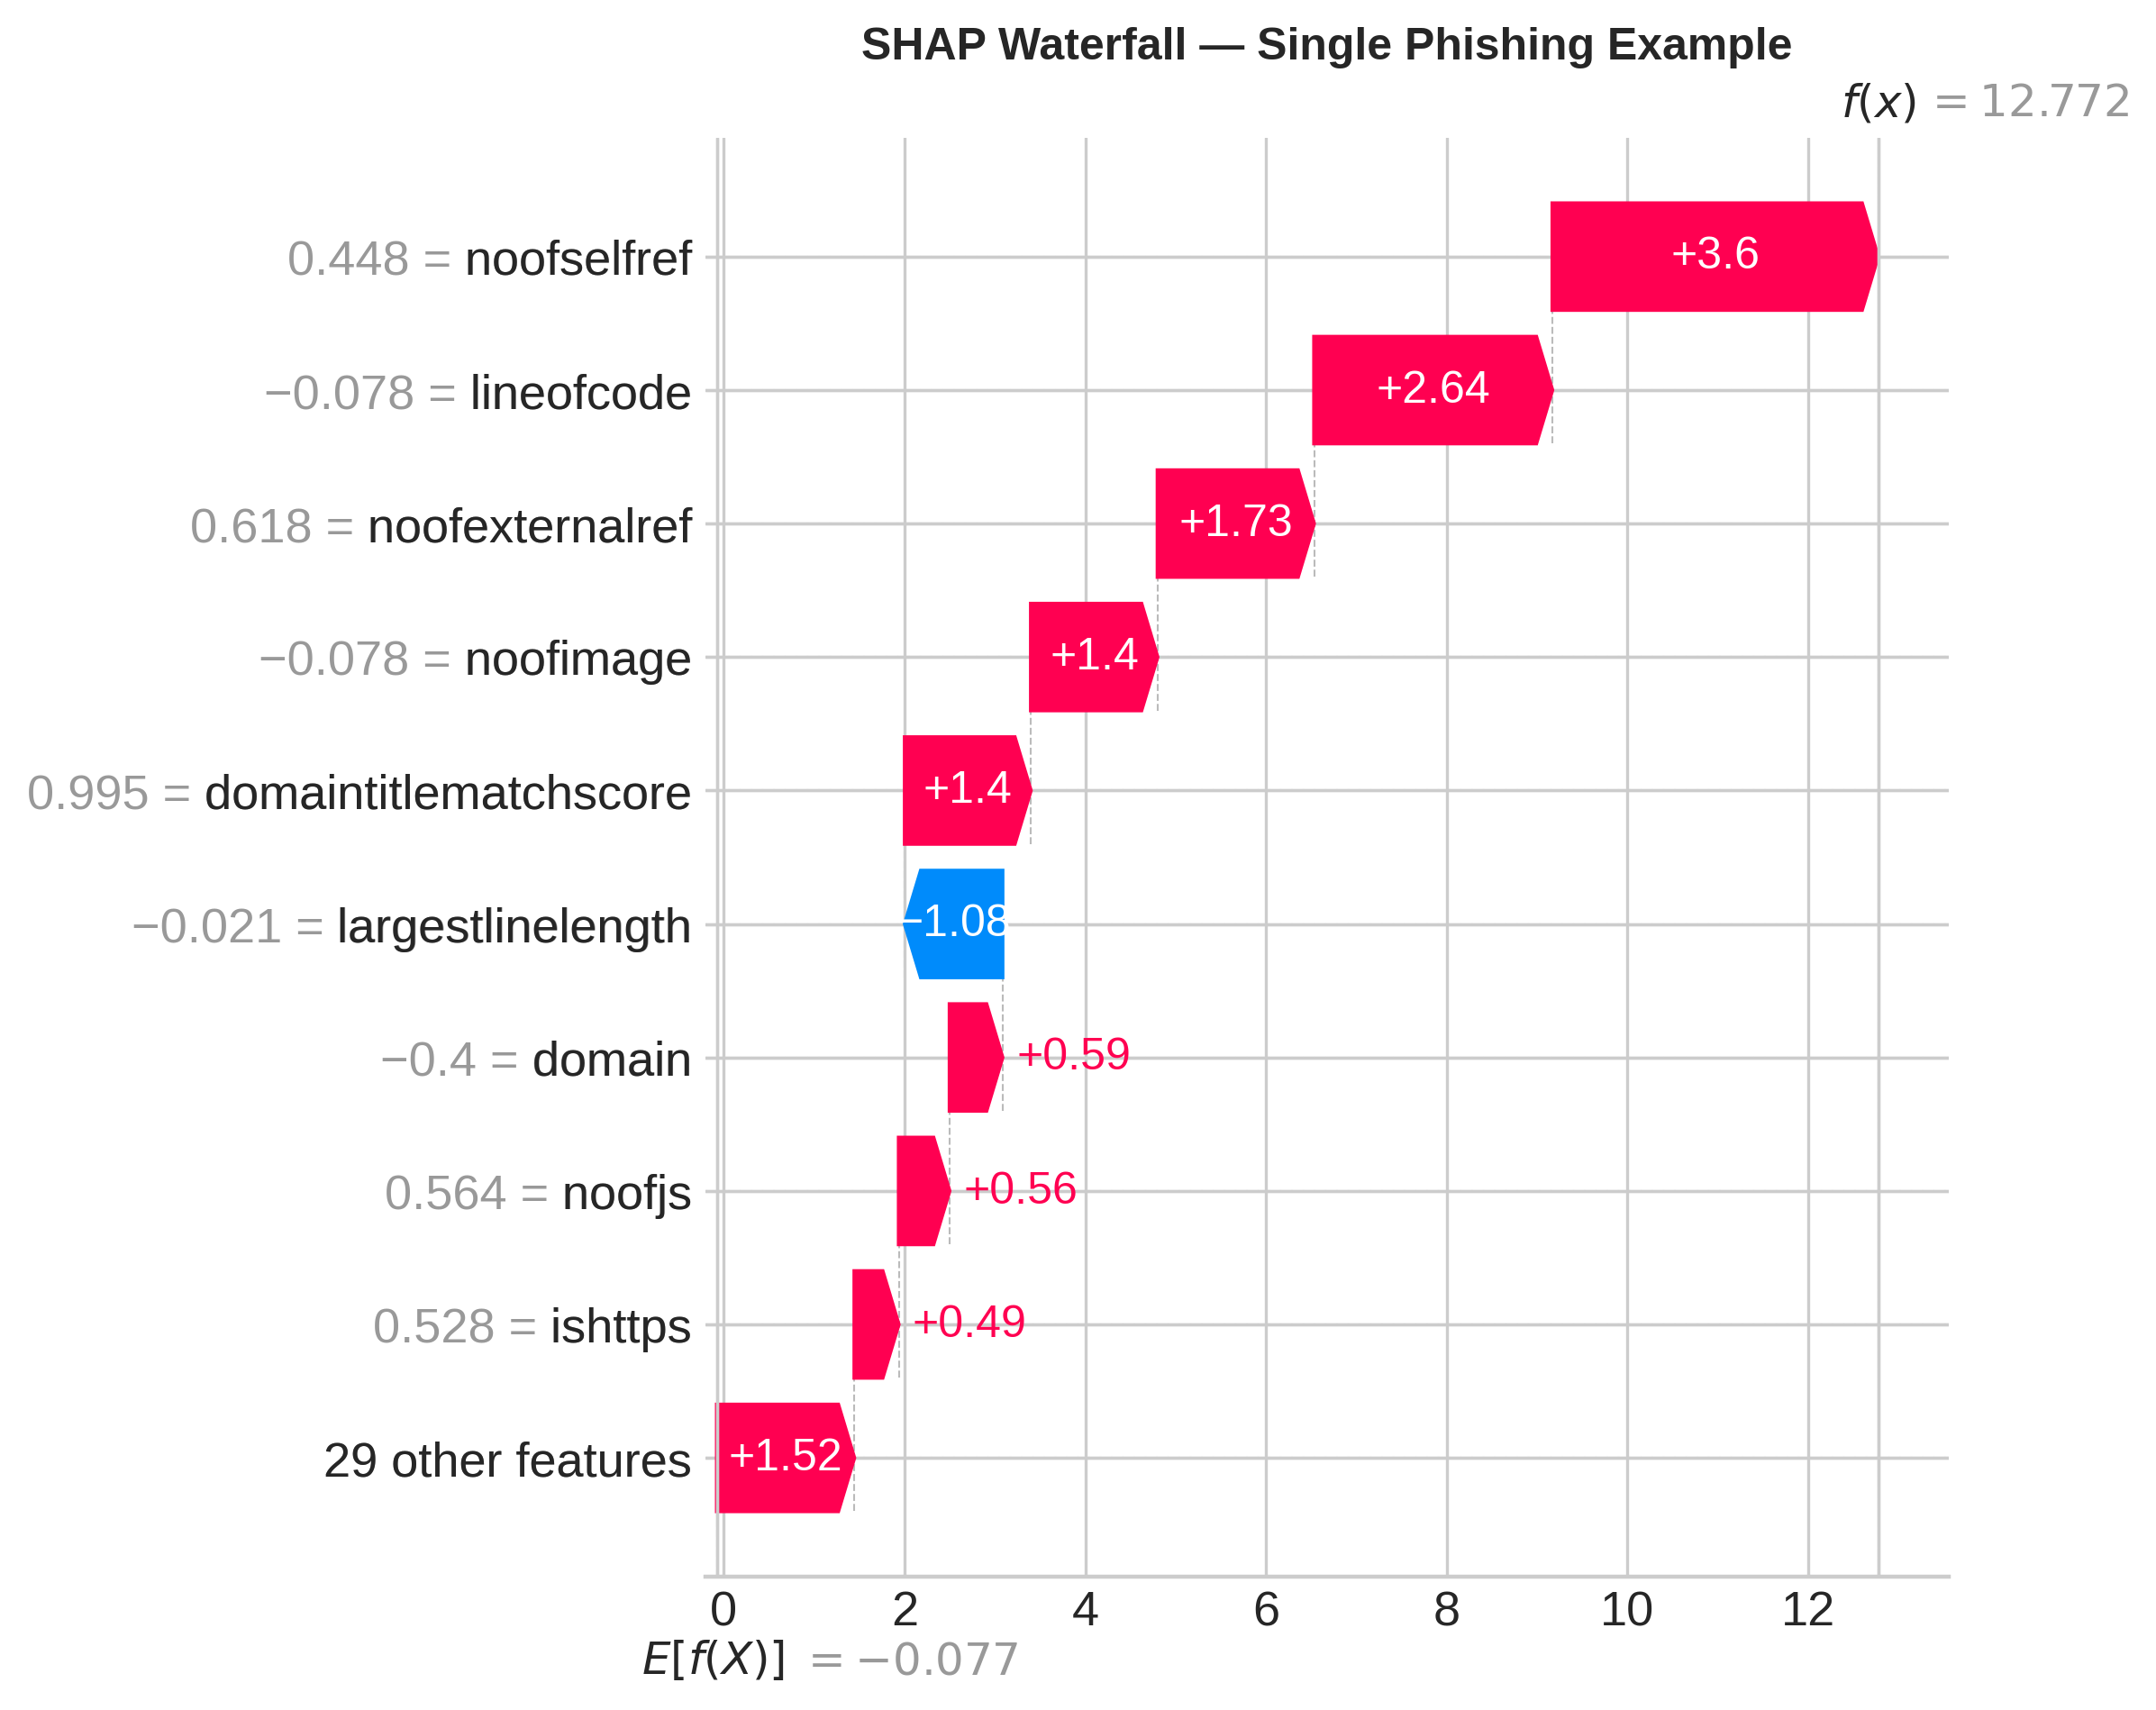

✅ SHAP Waterfall plot saved: /content/drive/MyDrive/PhishingDetection/plots/shap_waterfall_example.png

✅ SHAP explainability complete. All 3 plots saved to Drive.


In [20]:
# ============================================================
# CELL 19 — SHAP Explainability
# ============================================================

from IPython.display import Image as IPyImage, display

if is_done("shap_done"):
    print("✅ SHAP already done — displaying from Drive.")
    for fname in ["shap_summary.png", "shap_bar.png", "shap_waterfall_example.png"]:
        fpath = os.path.join(PLOTS_DIR, fname)
        if os.path.exists(fpath):
            display(IPyImage(filename=fpath))
else:
    if xgb_model is None:
        xgb_model = load_from_drive("models/xgb_model.pkl")

    X_test_arr = X1_test.values if hasattr(X1_test, 'values') else X1_test
    feature_names = list(X1_test.columns) if hasattr(X1_test, 'columns') else None

    # Sample 500 for speed
    idx_sample = np.random.choice(len(X_test_arr), size=min(500, len(X_test_arr)),
                                   replace=False)
    X_shap = X_test_arr[idx_sample]

    print("⚙️  Computing SHAP values (TreeExplainer on 500-sample subset)...")
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)
    print("✅ SHAP values computed.")

    # ── Plot 1: SHAP Summary Beeswarm ────────────────────────
    plt.figure()
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                      plot_type='dot', show=False, max_display=20)
    plt.title("SHAP Summary — XGBoost (Beeswarm)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    p1 = f"{PLOTS_DIR}/shap_summary.png"
    plt.savefig(p1, dpi=300, bbox_inches='tight')
    display(IPyImage(filename=p1)); plt.close()
    print(f"✅ SHAP Summary plot saved: {p1}")

    # ── Plot 2: SHAP Bar Plot ─────────────────────────────────
    plt.figure()
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                      plot_type='bar', show=False, max_display=20)
    plt.title("SHAP Feature Importance — XGBoost (Bar)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    p2 = f"{PLOTS_DIR}/shap_bar.png"
    plt.savefig(p2, dpi=300, bbox_inches='tight')
    display(IPyImage(filename=p2)); plt.close()
    print(f"✅ SHAP Bar plot saved: {p2}")

    # ── Plot 3: SHAP Waterfall (single phishing example) ─────
    y_test_arr = np.array(y1_test)
    phishing_idx = np.where(y_test_arr[idx_sample] == 1)[0]
    if len(phishing_idx) > 0:
        single_idx = phishing_idx[0]
    else:
        single_idx = 0

    plt.figure()
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[single_idx],
            base_values=explainer.expected_value,
            data=X_shap[single_idx],
            feature_names=feature_names,
        ),
        show=False
    )
    plt.title("SHAP Waterfall — Single Phishing Example", fontsize=12, fontweight='bold')
    plt.tight_layout()
    p3 = f"{PLOTS_DIR}/shap_waterfall_example.png"
    plt.savefig(p3, dpi=300, bbox_inches='tight')
    display(IPyImage(filename=p3)); plt.close()
    print(f"✅ SHAP Waterfall plot saved: {p3}")

    mark_done("shap_done")
    print("\n✅ SHAP explainability complete. All 3 plots saved to Drive.")


In [21]:
# ============================================================
# CELL 20 — Cross-Dataset Validation
# ============================================================

if is_done("cross_dataset_done"):
    print("✅ Cross-dataset validation already done.")
    cross_results = load_from_drive("metrics/cross_dataset_results.json")
    print(pd.DataFrame(cross_results).to_string())
else:
    # Ensure DS2 splits are loaded
    if 'X2_test' not in dir():
        X2_train = load_from_drive("checkpoints/preprocessed_X2_train.pkl")
        X2_test  = load_from_drive("checkpoints/preprocessed_X2_test.pkl")
        y2_train = load_from_drive("checkpoints/preprocessed_y2_train.pkl")
        y2_test  = load_from_drive("checkpoints/preprocessed_y2_test.pkl")

    if rf_model is None:
        rf_model     = load_from_drive("models/rf_model.pkl")
    if hybrid_model is None:
        hybrid_model = load_from_drive("models/hybrid_model.pkl")

    # Check feature overlap
    X1_cols = set(X1_train.columns) if hasattr(X1_train, 'columns') else set()
    X2_cols = set(X2_test.columns)  if hasattr(X2_test,  'columns') else set()
    common  = X1_cols & X2_cols
    print(f"📐 Feature overlap DS1 ∩ DS2: {len(common)} common features")

    cross_results = {"method": [], "model": [], "accuracy": [],
                     "f1": [], "roc_auc": []}

    X2_test_arr  = X2_test.values  if hasattr(X2_test,  'values') else X2_test
    X2_train_arr = X2_train.values if hasattr(X2_train, 'values') else X2_train

    if len(common) >= 10:
        print("✅ Using common features with scaler1 (trained on DS1)")
        common_list = sorted(common)
        X2_sub = X2_test[common_list]
        # Re-scale using scaler1 (if common features were in DS1 scaler)
        X2_sub_arr = X2_sub.values

        for model_name, model in [("Random Forest", rf_model),
                                   ("Hybrid (Proposed)", hybrid_model)]:
            try:
                # Use only the subset of features trained on
                preds = model.predict(X2_sub_arr)
                proba = model.predict_proba(X2_sub_arr)[:, 1]
                cross_results["method"].append("common_features")
                cross_results["model"].append(model_name)
                cross_results["accuracy"].append(round(accuracy_score(y2_test, preds), 4))
                cross_results["f1"].append(round(f1_score(y2_test, preds, zero_division=0), 4))
                cross_results["roc_auc"].append(round(roc_auc_score(y2_test, proba), 4))
            except Exception as e:
                print(f"  ⚠️  {model_name} failed with common features: {e}")
                print("  Falling back to fresh training on DS2...")
                _m = type(model).__name__
    else:
        print(f"⚠️  Only {len(common)} common features (<10). Training fresh models on DS2.")
        from sklearn.ensemble import RandomForestClassifier as _RFC

        _rf2 = _RFC(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
        _rf2.fit(X2_train_arr, y2_train)

        _lr2 = LogisticRegression(max_iter=500, random_state=RANDOM_SEED, n_jobs=-1)
        _lr2.fit(X2_train_arr, y2_train)

        _hybrid2 = VotingClassifier(
            estimators=[('lr', _lr2), ('rf', _rf2)], voting='soft', n_jobs=-1
        )
        _hybrid2.fit(X2_train_arr, y2_train)

        for model_name, model in [("RF (fresh DS2)", _rf2),
                                   ("Hybrid (fresh DS2)", _hybrid2)]:
            preds = model.predict(X2_test_arr)
            proba = model.predict_proba(X2_test_arr)[:, 1]
            cross_results["method"].append("fresh_ds2")
            cross_results["model"].append(model_name)
            cross_results["accuracy"].append(round(accuracy_score(y2_test, preds), 4))
            cross_results["f1"].append(round(f1_score(y2_test, preds, zero_division=0), 4))
            cross_results["roc_auc"].append(round(roc_auc_score(y2_test, proba), 4))

    save_to_drive(cross_results, "metrics/cross_dataset_results.json")
    mark_done("cross_dataset_done")

    print("\n📊 Cross-Dataset Validation Results:")
    print(pd.DataFrame(cross_results).to_string(index=False))
    print("\n✅ Cross-dataset results saved to Drive.")


📐 Feature overlap DS1 ∩ DS2: 0 common features
⚠️  Only 0 common features (<10). Training fresh models on DS2.

📊 Cross-Dataset Validation Results:
   method              model  accuracy     f1  roc_auc
fresh_ds2     RF (fresh DS2)    0.9589 0.9577   0.9922
fresh_ds2 Hybrid (fresh DS2)    0.9512 0.9496   0.9906

✅ Cross-dataset results saved to Drive.


⏱️  Running batch latency benchmarks...
  Logistic Regression            | n= 1,000 → 0.6 ms
  Random Forest                  | n= 1,000 → 67.2 ms
  XGBoost                        | n= 1,000 → 3.6 ms
  Hybrid (Proposed)              | n= 1,000 → 70.2 ms
  Logistic Regression            | n= 5,000 → 0.8 ms
  Random Forest                  | n= 5,000 → 109.9 ms
  XGBoost                        | n= 5,000 → 18.3 ms
  Hybrid (Proposed)              | n= 5,000 → 178.5 ms
  Logistic Regression            | n=10,000 → 7.0 ms
  Random Forest                  | n=10,000 → 292.0 ms
  XGBoost                        | n=10,000 → 21.8 ms
  Hybrid (Proposed)              | n=10,000 → 264.4 ms


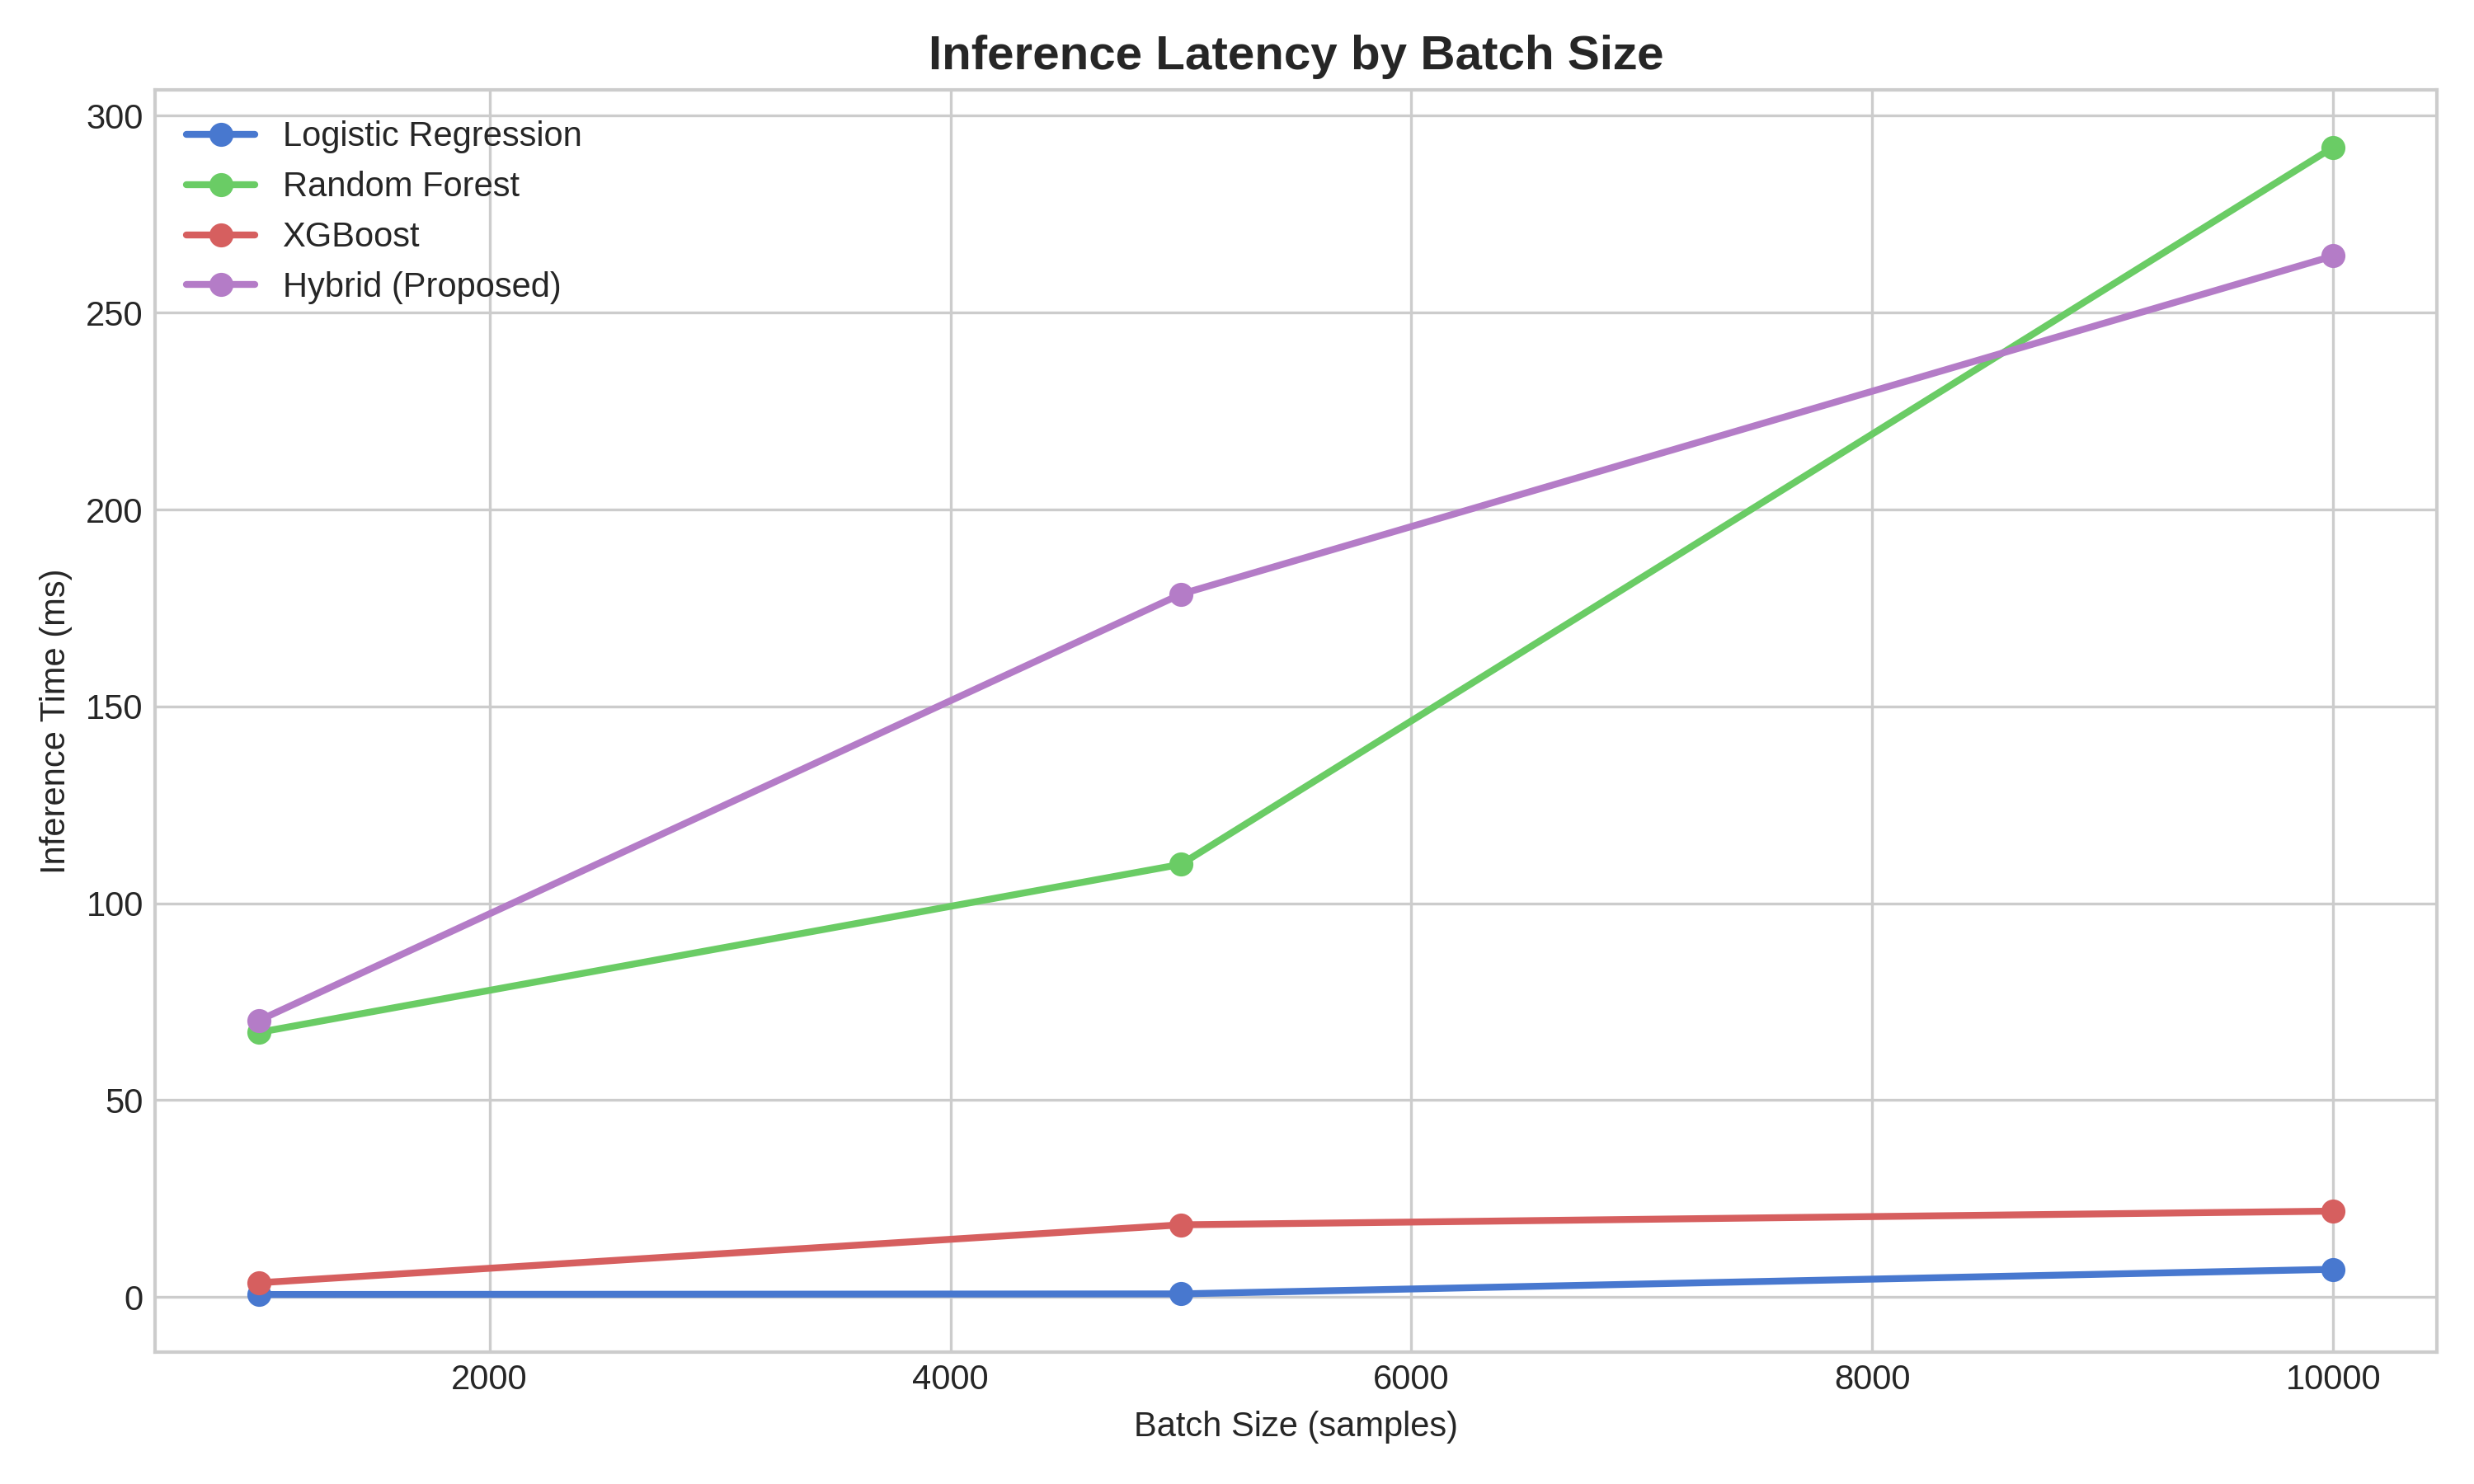

✅ Latency plot saved: /content/drive/MyDrive/PhishingDetection/plots/inference_latency.png

🔬 Single-URL Inference Demo (Hybrid Model):

  Predicted: LEGITIMATE (confidence: 79.6%)

📦 Model File Size Table:
              Model  File Size (KB)  Accuracy
Logistic Regression             1.9    0.9983
      Random Forest         12628.6    0.9996
            XGBoost           452.0    0.9997
  Hybrid (Proposed)         26175.2    0.9996

✅ Inference demo complete.


In [22]:
# ============================================================
# CELL 21 — Lightweight Inference Demo
# ============================================================

from IPython.display import Image as IPyImage, display

if is_done("inference_demo_done"):
    print("✅ Inference demo already done.")
    display(IPyImage(filename=f"{PLOTS_DIR}/inference_latency.png"))
else:
    X_test_arr = X1_test.values if hasattr(X1_test, 'values') else X1_test

    # Ensure all models loaded
    for mname, mpath in [("lr_model",     "models/lr_model.pkl"),
                          ("rf_model",     "models/rf_model.pkl"),
                          ("xgb_model",    "models/xgb_model.pkl"),
                          ("hybrid_model", "models/hybrid_model.pkl")]:
        if mname not in dir() or globals().get(mname) is None:
            globals()[mname] = load_from_drive(mpath)

    # ── Part A: Batch Latency Benchmark ──────────────────────
    batch_sizes  = [1000, 5000, 10000]
    model_map    = {
        "Logistic Regression": lr_model,
        "Random Forest":       rf_model,
        "XGBoost":             xgb_model,
        "Hybrid (Proposed)":   hybrid_model,
    }
    latency_data = {name: [] for name in model_map}

    print("⏱️  Running batch latency benchmarks...")
    for n in batch_sizes:
        if n > len(X_test_arr):
            n = len(X_test_arr)
        X_batch = X_test_arr[:n]
        for model_name, model in model_map.items():
            if model is not None:
                t0 = time.time()
                _ = model.predict(X_batch)
                elapsed_ms = (time.time() - t0) * 1000
                latency_data[model_name].append(elapsed_ms)
                print(f"  {model_name:30s} | n={n:>6,} → {elapsed_ms:.1f} ms")

    # Plot latency
    fig, ax = plt.subplots(figsize=(10, 6))
    for model_name, latencies in latency_data.items():
        if latencies:
            ax.plot(batch_sizes[:len(latencies)], latencies,
                    marker='o', linewidth=2,
                    color=MODEL_COLORS.get(model_name, "#888"),
                    label=model_name)
    ax.set_xlabel("Batch Size (samples)"); ax.set_ylabel("Inference Time (ms)")
    ax.set_title("Inference Latency by Batch Size", fontsize=14, fontweight='bold')
    ax.legend(); plt.tight_layout()
    p = f"{PLOTS_DIR}/inference_latency.png"
    plt.savefig(p, dpi=300); display(IPyImage(filename=p)); plt.close()
    print(f"✅ Latency plot saved: {p}")

    # ── Part B: Single URL Demo ───────────────────────────────
    print("\n🔬 Single-URL Inference Demo (Hybrid Model):")
    # Construct a fake phishing-like feature vector
    if hasattr(X1_test, 'columns'):
        fake_url_features = pd.DataFrame(
            np.zeros((1, X_test_arr.shape[1])), columns=X1_test.columns
        )
        # Set some high-risk feature values
        for col in fake_url_features.columns:
            if 'length' in col or 'count' in col:
                fake_url_features[col] = 150.0
    else:
        fake_url_features = np.zeros((1, X_test_arr.shape[1]))
        fake_url_features[0, :5] = 150.0

    fake_arr = fake_url_features.values if hasattr(fake_url_features, 'values') else fake_url_features
    pred_class = hybrid_model.predict(fake_arr)[0]
    pred_proba = hybrid_model.predict_proba(fake_arr)[0]
    confidence = pred_proba[pred_class] * 100
    label_str  = "PHISHING" if pred_class == 1 else "LEGITIMATE"
    print(f"\n  Predicted: {label_str} (confidence: {confidence:.1f}%)\n")

    # ── Part C: Model File Size Table ────────────────────────
    print("📦 Model File Size Table:")
    tmp_dir = "/content/tmp/model_sizes"
    os.makedirs(tmp_dir, exist_ok=True)
    size_rows = []
    for model_name, model in model_map.items():
        if model is not None:
            fpath = os.path.join(tmp_dir, f"{model_name.replace(' ', '_')}.pkl")
            joblib.dump(model, fpath)
            size_kb = os.path.getsize(fpath) / 1024
            acc = results_df.set_index("Model").loc[model_name, "Accuracy"] \
                  if 'results_df' in dir() else "N/A"
            size_rows.append({"Model": model_name,
                               "File Size (KB)": round(size_kb, 1),
                               "Accuracy": acc})
    size_df = pd.DataFrame(size_rows)
    print(size_df.to_string(index=False))

    mark_done("inference_demo_done")
    print("\n✅ Inference demo complete.")


In [24]:
# ============================================================
# CELL 22 — Paper-Ready Summary Report
# ============================================================

if not is_done("results_consolidated"):
    print("❌ ERROR: results_consolidated not done. Run Cell 17 first.")
else:
    # Load all needed data
    if 'results_df' not in dir():
        results_df = pd.read_csv(f"{RESULTS_DIR}/comparison_table.csv")

    cv_data = load_from_drive("metrics/cv_results.json") if is_done("cv_done") else {}
    cross_data = load_from_drive("metrics/cross_dataset_results.json") \
                 if is_done("cross_dataset_done") else {}

    state = load_checkpoint()
    best_model_row = results_df.loc[results_df["Accuracy"].idxmax()]
    best_model     = best_model_row["Model"]

    report_lines = [
        "=" * 70,
        "  PHISHING DETECTION — PAPER-READY SUMMARY REPORT",
        "  'A Lightweight Hybrid Machine Learning Framework for",
        "   Phishing URL Detection and Classification'",
        "  Author: BE CSE, Chitkara University",
        f"  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        "=" * 70,
        "",
        "── DATASET SUMMARY ─────────────────────────────────────────────────",
        f"  Dataset 1 (PhiUSIIL)         : {state['metadata'].get('dataset1_shape', 'N/A')} rows×cols",
        f"  Dataset 2 (Web Page Phishing): {state['metadata'].get('dataset2_shape', 'N/A')} rows×cols",
        f"  Target Col DS1               : {state['metadata'].get('TARGET_COL_1')}",
        f"  Target Col DS2               : {state['metadata'].get('TARGET_COL_2')}",
        "",
        "── MODEL PERFORMANCE COMPARISON ────────────────────────────────────",
    ]

    # Add table rows
    col_widths = [28, 9, 10, 8, 9, 9, 13, 16]
    headers = ["Model", "Accuracy", "Precision", "Recall",
               "F1-Score", "ROC-AUC", "Train(s)", "Infer(ms/s)"]
    header_line = "  " + "".join(f"{h:<{w}}" for h, w in zip(headers, col_widths))
    report_lines.append(header_line)
    report_lines.append("  " + "-" * sum(col_widths))
    for _, row in results_df.iterrows():
        line = "  " + "".join([
            f"{str(row['Model']):<28}",
            f"{row['Accuracy']:<9.4f}",
            f"{row['Precision']:<10.4f}",
            f"{row['Recall']:<8.4f}",
            f"{row['F1-Score']:<9.4f}",
            f"{row['ROC-AUC']:<9.4f}",
            f"{row['Train Time (s)']:<13.2f}",
            f"{row['Infer Time (ms/s)']:<16.4f}",
        ])
        report_lines.append(line)

    report_lines += [
        "",
        f"  ★  BEST MODEL: {best_model}",
        f"     Accuracy = {best_model_row['Accuracy']:.4f}",
        f"     F1-Score  = {best_model_row['F1-Score']:.4f}",
        f"     ROC-AUC   = {best_model_row['ROC-AUC']:.4f}",
        "",
    ]

    if cv_data:
        report_lines.append("── CROSS-VALIDATION (5-Fold, F1-Weighted) ──────────────────────────")
        for model_name in cv_data.get("mean_f1", {}):
            mean = cv_data["mean_f1"][model_name]
            std  = cv_data["std_f1"][model_name]
            report_lines.append(f"  {model_name:<30s}: {mean:.4f} ± {std:.4f}")
        report_lines.append("")

    if cross_data and cross_data.get("model"):
        report_lines.append("── CROSS-DATASET VALIDATION ────────────────────────────────────────")
        for i, model_name in enumerate(cross_data["model"]):
            acc = cross_data["accuracy"][i]
            f1  = cross_data["f1"][i]
            report_lines.append(f"  {model_name:<30s}: Acc={acc:.4f}, F1={f1:.4f}")
        report_lines.append("")

    report_lines += [
        "── PLOT ARTIFACTS ──────────────────────────────────────────────────",
        "  accuracy_comparison.png     | multi_metric_comparison.png",
        "  roc_curves.png              | confusion_matrices.png",
        "  time_vs_accuracy.png        | cv_f1_boxplot.png",
        "  feature_importance_rf.png   | shap_summary.png",
        "  shap_bar.png                | shap_waterfall_example.png",
        "  inference_latency.png",
        "",
        "── RESEARCH PAPER MAPPING ──────────────────────────────────────────",
        "  Abstract          → comparison_table.csv (best model metrics)",
        "  Introduction      → EDA class imbalance stats",
        "  Dataset Desc      → Cell 5/6 printed stats",
        "  Methodology       → Cells 9–15 (preprocessing + model configs)",
        "  Results           → Cells 17–18 (table + all 7 plots)",
        "  Explainability    → Cell 19 (SHAP plots)",
        "  Cross-Dataset Val → Cell 20",
        "  Conclusion        → This report (summary_report.txt)",
        "  Future Work       → Real-time URL streaming; transformer-based tokenizer",
        "",
        "=" * 70,
        "  END OF REPORT",
        "=" * 70,
    ]

    report_text = "\n".join(report_lines)
    print(report_text)

    # Save to Drive
    report_path = f"{RESULTS_DIR}/summary_report.txt"
    with open(report_path, "w") as f:
        f.write(report_text)
    print(f"\n📄 Summary report saved to Drive at PhishingDetection/results/summary_report.txt")


  PHISHING DETECTION — PAPER-READY SUMMARY REPORT
  'A Lightweight Hybrid Machine Learning Framework for
   Phishing URL Detection and Classification'
  Author: BE CSE, Chitkara University
  Generated: 2026-05-13 19:52:15

── DATASET SUMMARY ─────────────────────────────────────────────────
  Dataset 1 (PhiUSIIL)         : [235795, 55] rows×cols
  Dataset 2 (Web Page Phishing): [11430, 89] rows×cols
  Target Col DS1               : label
  Target Col DS2               : status

── MODEL PERFORMANCE COMPARISON ────────────────────────────────────
  Model                       Accuracy Precision Recall  F1-Score ROC-AUC  Train(s)     Infer(ms/s)     
  ------------------------------------------------------------------------------------------------------
  Logistic Regression         0.9983   0.9980    0.9991  0.9985   1.0000   3.11         0.0004          
  Random Forest               0.9996   0.9995    0.9999  0.9997   1.0000   43.88        0.0088          
  XGBoost                   